# Sasa & Dany · Milestone 1 · Pre-cleaning profile

**What this notebook is:** the exploratory data analysis (EDA) we do *before* any cleaning, for 11 of the 14 tables:
`seasons`, `circuits`, `drivers`, `constructors`, `status`, `sprint_results`, `driver_standings`,
`lap_times`, `pit_stops`, `constructor_standings`, `constructor_results`.

**Why:** the brief asks for EDA before cleaning, backed by code and plots instead of looking at rows by eye.
What we find here decides how each table is cleaned later, and feeds the data-engineering questions,
the features and the report.

**One rule for the whole notebook:** the raw files are never changed. Every step works on copies.

## P0 · Setup: load untouched, fingerprint, build helpers

- **What:** load our 11 CSV files exactly as delivered (every column as text), save a fingerprint of each one, and define four helper functions.
- **Why:**
  - Reading everything as text keeps the `\N` placeholders visible, so we can count them instead of letting pandas hide them.
  - The fingerprint lets us prove at the end (step D3) that the raw data was never modified, as the brief requires.
  - The helpers (`as_num`, `year_of`, `profile`, `pk_check`) make every later step use the same checks, so our EDA is code, not manual inspection.

In [1]:
# ==========================================================================================
# P0 · SETUP: load our 11 tables exactly as they are, and build the helpers every step uses
# ==========================================================================================

# ---------- 1. Libraries ----------
import os                          # to find the folder where Kaggle put the dataset
import numpy as np                 # gives us NaN, the real "missing value" marker
import pandas as pd                # tables (DataFrames): reading, counting, grouping
import matplotlib.pyplot as plt    # basic plots
import seaborn as sns              # nicer statistical plots (heatmaps, etc.)

pd.set_option("display.max_columns", 50)   # show every column when we display a table

# Library versions: Kaggle's versions can differ from our laptops, so we print them for reproducibility
print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)


# ---------- 2. Where is the data? ----------
# Kaggle puts attached datasets somewhere under /kaggle/input. Instead of guessing the exact
# folder name, we search for the folder that contains races.csv. On a laptop we fall back to ./data
def find_data_dir():
    for folder, _, files in os.walk("/kaggle/input"):
        if "races.csv" in files:
            return folder
    return "data"

DATA_DIR = find_data_dir()
csv_files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith(".csv"))
print("Data folder:", DATA_DIR)
print("CSV files found:", len(csv_files))          # we expect 14


# ---------- 3. The 11 tables we (Sasa & Dany) profile ----------
# races, results and qualifying are profiled by our teammates; we only read them for lookups.
MINE = ["seasons", "circuits", "drivers", "constructors", "status", "sprint_results",
        "driver_standings", "lap_times", "pit_stops", "constructor_standings", "constructor_results"]

# The dataset does not leave missing cells empty: it writes the text \N instead.
# A value that "stands in" for missing like this is called a sentinel.
SENT = r"\N"


# ---------- 4. Load every file exactly as it is (the "bronze" layer) ----------
# dtype=str              -> read every column as text, so pandas does not guess the types for us
# keep_default_na=False  -> pandas must not turn anything into NaN by itself, so \N stays visible
raw = {t: pd.read_csv(f"{DATA_DIR}/{t}.csv", dtype=str, keep_default_na=False)
       for t in MINE + ["races", "results"]}

# A fingerprint (hash) of every raw table. In step D3 we compute it again and compare,
# to PROVE we never changed the raw data (the brief: "Raw CSV files remain immutable").
RAW_HASH = {t: pd.util.hash_pandas_object(df).sum() for t, df in raw.items()}


# ---------- 5. Two lookups we need in many steps ----------
# races: turn \N into NaN and make ids and year numeric, so we can find the season of any raceId
races = raw["races"].replace(SENT, np.nan).astype({"raceId": int, "year": int, "round": int, "circuitId": int})
races["date"] = pd.to_datetime(races["date"])      # race date as a real date, not text
YEAR = races.set_index("raceId")["year"]           # quick lookup: raceId -> season year
results = raw["results"].replace(SENT, np.nan)     # results with \N as NaN, used only for cross-checks


# ---------- 6. Helper functions (the same checks for every table) ----------
def as_num(df):
    # Returns a COPY for exploring: \N becomes NaN, and every column made only of numbers becomes numeric.
    # Columns that contain any text (e.g. lap times like "1:26.572") stay text, so we can still see their format.
    out = df.replace(SENT, np.nan)
    for c in out.columns:
        conv = pd.to_numeric(out[c], errors="coerce")     # try to read the column as numbers
        if conv.notna().sum() == out[c].notna().sum():    # did EVERY non-missing value convert?
            out[c] = conv                                 # yes -> keep the numeric version
    return out


def year_of(df):
    # The season year of every row, for any table that has a raceId column
    return pd.to_numeric(df["raceId"]).map(YEAR)


def profile(t):
    # A "profile card" for table t: one row per column, with the checks we care about
    df = raw[t]
    return pd.DataFrame({
        "sentinel_N": df.eq(SENT).sum(),                     # how many \N in the column
        "sentinel_%": (df.eq(SENT).mean() * 100).round(2),   # the same, as a % of the rows
        "empty_str": df.eq("").sum(),                        # truly empty cells (we expect 0)
        "unique": df.nunique(),                              # how many different values
        "numeric_%": df.apply(lambda s: pd.to_numeric(s, errors="coerce").notna().mean() * 100).round(1),  # % that read as numbers
        "example": df.iloc[0]})                              # the first value, to see the format


def pk_check(t, cols):
    # Checks a primary key: the column(s) that should identify each row of table t
    df = raw[t]
    return {"table": t, "key": "+".join(cols), "rows": len(df),
            "duplicates": int(df.duplicated(cols).sum()),                          # rows whose key appears again
            "null_or_sentinel": int(df[cols].isin(["", SENT]).any(axis=1).sum())}  # rows with a missing key


# ---------- 7. First output: how big is each of our 11 tables? ----------
sizes = pd.DataFrame({t: raw[t].shape for t in MINE}, index=["rows", "columns"]).T
sizes

pandas 2.3.3 | numpy 2.1.3 | seaborn 0.13.2
Data folder: /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020
CSV files found: 14


,rows,columns
seasons,75,2
circuits,77,9
drivers,861,9
constructors,212,5
status,139,2
sprint_results,360,16
driver_standings,34863,7
lap_times,589081,6
pit_stops,11371,7
constructor_standings,13391,7


**P0 result:** the dataset folder holds all 14 CSV files, and our 11 tables loaded with the sizes above.
`lap_times` is by far the biggest (589,081 rows); `seasons` and `status` are tiny lookup lists.
Nothing has been cleaned or changed; this is the starting point every later step builds on.

## A1 · seasons: complete list of years, and how season length changed

- **What:** profile the `seasons` table, check that its key (`year`) is unique and complete from 1950 to 2024, compare it with `races`, and plot how many races each season had.
- **Why:**
  - `seasons` is the list of years every other table relies on. A missing or repeated year would break joins and per-season counts.
  - Season length matters later: 5 wins in a 7-race season is not the same as 5 wins in a 24-race season, so we need to know how much it changed.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
year,0,0.0,0,75,100.0,2009
url,0,0.0,0,75,0.0,http://en.wikipedia.org/wiki/2009_Formula_One_...


{'table': 'seasons', 'key': 'year', 'rows': 75, 'duplicates': 0, 'null_or_sentinel': 0}
Every year 1950-2024 present: True
File order starts with: [2009, 2008, 2007] | sorted by year: False
Seasons with no races: set() | Race years missing from seasons: set()
url unique per season: True | every url contains its own year: True | example: http://en.wikipedia.org/wiki/2009_Formula_One_season
Fewest races in a season: 7 | most: 24
Seasons with the fewest races: [1950, 1955]
Seasons with the most races: [2024]


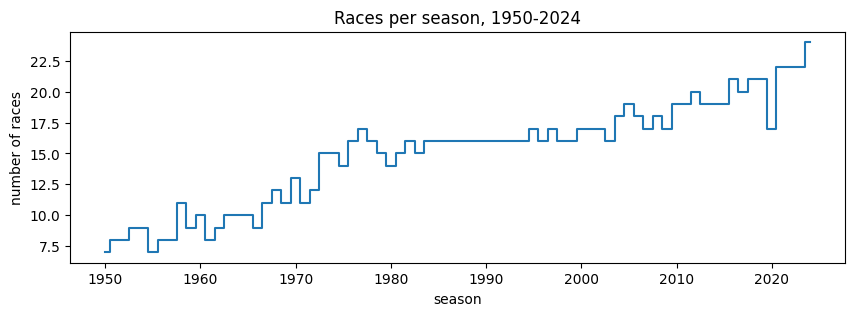

In [2]:
# ==========================================================================================
# A1 · seasons: is the list of years complete, and how did the length of a season change?
# ==========================================================================================

# An exploring copy of seasons: \N -> NaN and number columns -> numbers (raw stays untouched)
se = as_num(raw["seasons"])

# ---------- 1. Profile card: one row per column ----------
# Shows, for each column, how many \N there are, how many different values, and an example value
display(profile("seasons"))

# ---------- 2. Primary key: does "year" identify every row? ----------
# A good key has no repeated values and no missing values
print(pk_check("seasons", ["year"]))

# ---------- 3. Is every season from 1950 to 2024 there, with no gaps? ----------
print("Every year 1950-2024 present:", sorted(se.year) == list(range(1950, 2025)))

# ---------- 4. Is the file sorted by year? ----------
# We print the first 3 years in the order they appear in the file
print("File order starts with:", se.year.head(3).tolist(),
      "| sorted by year:", se.year.is_monotonic_increasing)

# ---------- 5. Do seasons and races agree with each other? ----------
# Every season should have races, and every year that has races should be in seasons
print("Seasons with no races:", set(se.year) - set(races.year),
      "| Race years missing from seasons:", set(races.year) - set(se.year))

# ---------- 6. What is the url column? ----------
# If every url is different and simply contains its own year, it is only a Wikipedia link, not data
print("url unique per season:", se.url.is_unique,
      "| every url contains its own year:", all(str(y) in u for y, u in zip(se.year, se.url)),
      "| example:", se.url.iloc[0])

# ---------- 7. How long was each season? ----------
races_per_season = races.groupby("year").size()          # number of races in each season
print("Fewest races in a season:", races_per_season.min(), "| most:", races_per_season.max())
print("Seasons with the fewest races:", list(races_per_season[races_per_season == races_per_season.min()].index))
print("Seasons with the most races:", list(races_per_season[races_per_season == races_per_season.max()].index))

# ---------- 8. Plot: races per season (saved for the report) ----------
ax = races_per_season.plot(drawstyle="steps-mid", figsize=(10, 3), title="Races per season, 1950-2024")
ax.set_xlabel("season")
ax.set_ylabel("number of races")
os.makedirs("figures", exist_ok=True)                                     # folder for all report figures
plt.savefig("figures/A1_races_per_season.png", dpi=120, bbox_inches="tight")
plt.show()

**A1 result:**
- 75 rows, one per season from 1950 to 2024: no gaps, no repeats, no `\N`, nothing empty. `year` is a valid primary key.
- The file is **not sorted**: it starts 2009, 2008, 2007.
- `seasons` and `races` agree perfectly: every season has races, and every race year is listed.
- `url` is only a Wikipedia link (different for every season and always containing its own year). It carries no information for the model.
- Season length grew from **7 races** (1950 and 1955) to **24 races** (2024).

**Decisions for cleaning:** sort by `year`; drop or ignore `url`; whenever we count something per season (wins, podiums, points), turn it into a rate or share, because seasons range from 7 to 24 races.

## A2 · circuits: profile, keys and types

- **What:** profile the `circuits` table, check its key and the other identifier columns, confirm each column's type, check that the coordinates are physically possible, and look for text problems (extra spaces, odd names, broken accents).
- **Why:** `circuits` is a lookup table: every race points to one circuit, question 1 ranks circuits, and question 2 uses their country. A broken key or a wrongly typed column here would silently break those joins later.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
circuitId,0,0.0,0,77,100.0,1
circuitRef,0,0.0,0,77,0.0,albert_park
name,0,0.0,0,77,0.0,Albert Park Grand Prix Circuit
location,0,0.0,0,75,0.0,Melbourne
country,0,0.0,0,35,0.0,Australia
lat,0,0.0,0,77,100.0,-37.8497
lng,0,0.0,0,77,100.0,144.968
alt,0,0.0,0,66,100.0,10
url,0,0.0,0,77,0.0,http://en.wikipedia.org/wiki/Melbourne_Grand_P...


{'table': 'circuits', 'key': 'circuitId', 'rows': 77, 'duplicates': 0, 'null_or_sentinel': 0}
circuitRef unique: True | name unique: True | url unique: True
circuitId       int64
circuitRef     object
name           object
location       object
country        object
lat           float64
lng           float64
alt             int64
url            object
dtype: object


,lat,lng,alt
count,77.00,77.00,77.00
mean,33.44,1.08,247.01
std,22.81,65.52,362.74
min,-37.85,-118.19,-7.00
25%,32.78,-9.39,18.00
50%,40.95,3.93,129.00
75%,46.96,19.25,332.00
max,57.27,144.97,2227.00


lat within [-90, 90]: True | lng within [-180, 180]: True
lat: min -37.8497 (Albert Park Grand Prix Circuit, Australia) | max 57.2653 (Scandinavian Raceway, Sweden)
lng: min -118.189 (Long Beach, USA) | max 144.968 (Albert Park Grand Prix Circuit, Australia)
alt: min -7 (Baku City Circuit, Azerbaijan) | max 2227 (Autódromo Hermanos Rodríguez, Mexico)
values with leading/trailing spaces: {'circuitRef': 0, 'name': 0, 'location': 0, 'country': 0, 'url': 0}
circuitRef values breaking the usual pattern: ['ain-diab']
names with accented letters (they must display correctly): ['Autódromo José Carlos Pace', 'Nürburgring', 'Autódromo Juan y Oscar Gálvez', 'Autódromo do Estoril']
url starting with https: 1 | with http: 76


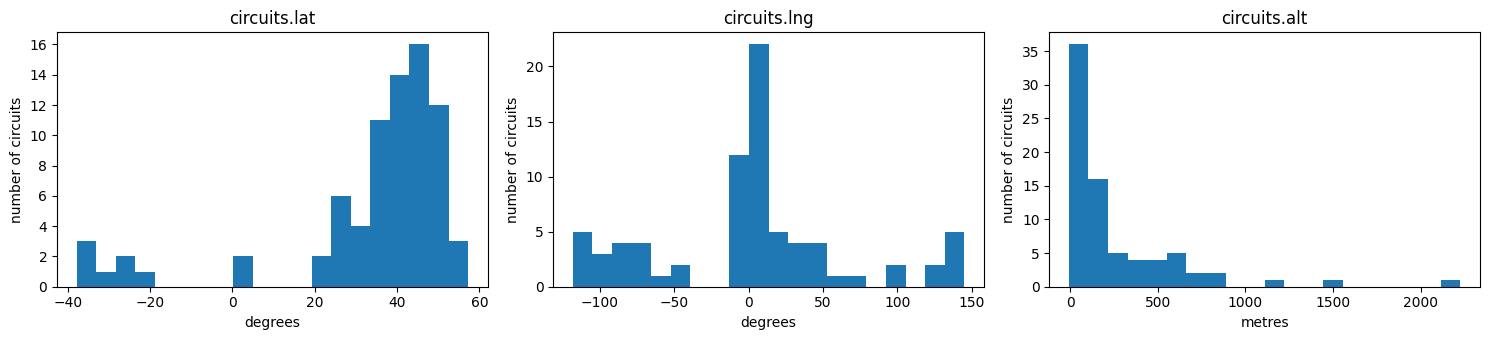

In [3]:
# ==========================================================================================
# A2 · circuits: profile, keys, types and basic sanity of every column
# ==========================================================================================

# An exploring copy of circuits: \N -> NaN and number columns -> numbers (raw stays untouched)
ci = as_num(raw["circuits"])

# ---------- 1. Profile card: one row per column ----------
# Shows, for each column, how many \N there are, how many different values, and an example value
display(profile("circuits"))

# ---------- 2. Keys: does circuitId identify every row? Are the other identifiers unique too? ----------
print(pk_check("circuits", ["circuitId"]))
print("circuitRef unique:", ci.circuitRef.is_unique, "| name unique:", ci.name.is_unique, "| url unique:", ci.url.is_unique)

# ---------- 3. Types: which columns became numbers, which stayed text? ----------
print(ci.dtypes)

# ---------- 4. Do the coordinates make sense? ----------
# Latitude must be between -90 and 90 and longitude between -180 and 180; altitude is in metres above sea level
display(ci[["lat", "lng", "alt"]].describe().round(2))
print("lat within [-90, 90]:", ci.lat.between(-90, 90).all(), "| lng within [-180, 180]:", ci.lng.between(-180, 180).all())
for col in ["lat", "lng", "alt"]:                                  # which circuit sits at each extreme?
    lo, hi = ci.loc[ci[col].idxmin()], ci.loc[ci[col].idxmax()]
    print(f"{col}: min {lo[col]} ({lo['name']}, {lo['country']}) | max {hi[col]} ({hi['name']}, {hi['country']})")

# ---------- 5. Text hygiene: stray spaces, naming pattern, accented letters, link format ----------
text_cols = ["circuitRef", "name", "location", "country", "url"]
print("values with leading/trailing spaces:", {c: int((ci[c] != ci[c].str.strip()).sum()) for c in text_cols})
bad_ref = ci.circuitRef[~ci.circuitRef.str.match(r"^[a-z0-9_]+$")]    # refs are normally lower_case_with_underscores
print("circuitRef values breaking the usual pattern:", bad_ref.tolist())
has_accent = ci.name.map(lambda s: not s.isascii())                    # True when a name has a non-English letter (é, ü, ...)
print("names with accented letters (they must display correctly):", ci.name[has_accent].tolist()[:4])
print("url starting with https:", ci.url.str.startswith("https").sum(), "| with http:", ci.url.str.startswith("http:").sum())

# ---------- 6. Plot: how latitude, longitude and altitude are spread (saved for the report) ----------
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for a, col, unit in zip(ax, ["lat", "lng", "alt"], ["degrees", "degrees", "metres"]):
    ci[col].plot.hist(bins=20, ax=a, title=f"circuits.{col}")
    a.set_xlabel(unit)
    a.set_ylabel("number of circuits")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/A2_circuit_coordinates.png", dpi=120, bbox_inches="tight")
plt.show()

**A2 result:**
- 77 circuits, 9 columns, with **no `\N` and no empty cells at all**: nothing to fill in.
- `circuitId` is a valid primary key, and `circuitRef`, `name` and `url` are unique too.
- Types are right: `circuitId`, `lat`, `lng` and `alt` are numbers; everything else is text.
- Every coordinate is physically possible: latitude runs from −37.85 (Albert Park, Australia) to 57.27 (Scandinavian Raceway, Sweden), and altitude from −7 m (Baku, below sea level) to 2,227 m (Mexico City).
- Text is clean: no stray spaces, and accented names (Autódromo, Nürburgring) are read correctly. Two cosmetic quirks: the `circuitRef` "ain-diab" uses a hyphen instead of an underscore, and 1 of the 77 links uses https while the rest use http.

**Decisions for cleaning:** nothing needs fixing here; keep `circuitId` as the only join key (never join on name or ref); `url` is not needed; altitude gets a closer look in A3.

## A3 · circuits: how often each was used, and where

- **What:** join `circuits` to `races` to count how many Grands Prix each circuit hosted and in which seasons, split the count into the eras "up to 2013" and "from 2014", check whether a circuit ever hosts two races in one season, and plot where the circuits are.
- **Why:** question 1 ranks circuits by how often a front-row start becomes a podium, before and after 2014. A circuit with 3 races cannot be ranked fairly against one with 70, so we must know how many races each circuit has, and how many circuits exist in *both* eras, before we choose a minimum-sample rule.

Circuits that never hosted a race: 0 | hosted exactly one race: 11


,name,races,first,last
13,Autodromo Nazionale di Monza,74,1950,2024
5,Circuit de Monaco,70,1950,2024
8,Silverstone Circuit,59,1950,2024
12,Circuit de Spa-Francorchamps,57,1950,2024
6,Circuit Gilles Villeneuve,43,1978,2024


,name,country,first
30,Donington Park,UK,1993
41,Fair Park,USA,1984
53,Le Mans,France,1967
56,Zeltweg,Austria,1964
59,Riverside International Raceway,USA,1960
60,AVUS,Germany,1959
61,Monsanto Park Circuit,Portugal,1959
62,Sebring International Raceway,USA,1959
63,Ain Diab,Morocco,1958
64,Pescara Circuit,Italy,1957


Circuits used up to 2013: 69 | from 2014: 32
Used in both eras: 24 | only up to 2013: 45 | only from 2014: 8
Circuits that first appear from 2014: ['Sochi Autodrom', 'Baku City Circuit', 'Autódromo Internacional do Algarve', 'Autodromo Internazionale del Mugello', 'Jeddah Corniche Circuit', 'Losail International Circuit', 'Miami International Autodrome', 'Las Vegas Strip Street Circuit']


,at least 1 races,at least 5 races,at least 10 races
up to 2013,69,45,30
from 2014,32,19,11
in BOTH eras,24,16,8


Seasons where one circuit hosted 2 or more races: [2020, 2021]
Circuits that hosted more than one differently named Grand Prix: 12 | most names at one circuit: 4 -> Nürburgring
Circuits with altitude exactly 0 m: [['yeongam', 'Yeongam County'], ['miami', 'Miami']]
Lowest 4 altitudes: [['baku', -7], ['yeongam', 0], ['miami', 0], ['sochi', 2]]


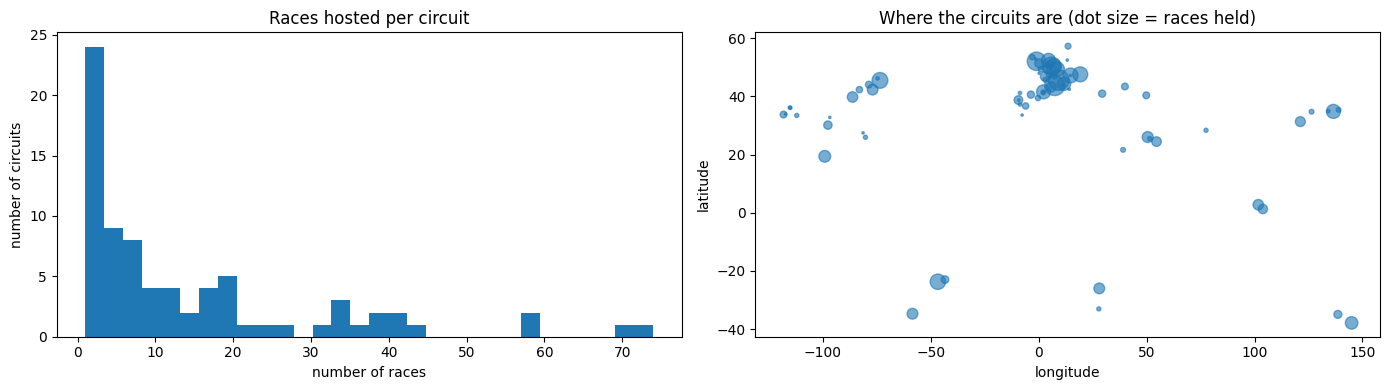

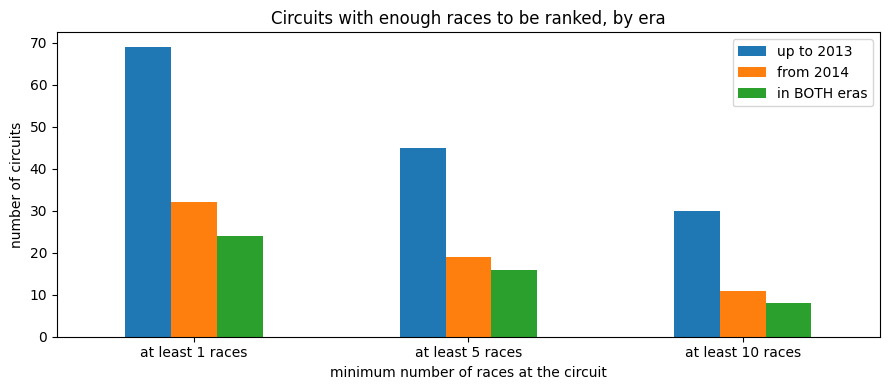

In [4]:
# ==========================================================================================
# A3 · circuits + races: how often was each circuit used, when, and where?
# ==========================================================================================

# Why: question 1 ranks circuits, so we need to know how many races each circuit hosted.
# A circuit with only 3 races cannot be ranked fairly against one with 70.
ci = as_num(raw["circuits"])          # exploring copy of circuits (raw stays untouched)

# ---------- 1. For every circuit: how many races, first season, last season ----------
rc = races.groupby("circuitId").agg(races=("raceId", "size"),      # number of Grands Prix held there
                                    first=("year", "min"),         # first season at this circuit
                                    last=("year", "max"))          # last season at this circuit
ci2 = ci.merge(rc, left_on="circuitId", right_index=True, how="left")   # attach the counts to the circuits table (a copy)

print("Circuits that never hosted a race:", ci2.races.isna().sum(),
      "| hosted exactly one race:", (ci2.races == 1).sum())
display(ci2.nlargest(5, "races")[["name", "races", "first", "last"]])      # the 5 most used circuits
display(ci2[ci2.races == 1][["name", "country", "first"]])                 # the one-off circuits

# ---------- 2. Before and after 2014: which circuits were used? ----------
# Question 1 compares the era up to 2013 with the era from 2014 on, so we count races per circuit in each era
n_early = races[races.year <= 2013].groupby("circuitId").size()    # races per circuit, seasons up to 2013
n_modern = races[races.year >= 2014].groupby("circuitId").size()   # races per circuit, seasons from 2014
both = sorted(set(n_early.index) & set(n_modern.index))            # circuits used in BOTH eras
print("Circuits used up to 2013:", len(n_early), "| from 2014:", len(n_modern))
print("Used in both eras:", len(both),
      "| only up to 2013:", len(n_early) - len(both), "| only from 2014:", len(n_modern) - len(both))
new_circuits = sorted(set(n_modern.index) - set(n_early.index))     # circuits that appear for the first time after 2013
print("Circuits that first appear from 2014:", ci.set_index("circuitId").name.reindex(new_circuits).tolist())

# How many circuits have enough races to be ranked? (at least 1, 5 or 10 races)
enough = pd.DataFrame(
    {f"at least {k} races": [int((n_early >= k).sum()), int((n_modern >= k).sum()),
                             int(((n_early.reindex(both) >= k) & (n_modern.reindex(both) >= k)).sum())]
     for k in [1, 5, 10]},
    index=["up to 2013", "from 2014", "in BOTH eras"])
display(enough)

# ---------- 3. Does a circuit ever host two races in the same season? ----------
per_season = races.groupby("year").agg(races=("raceId", "size"), circuits=("circuitId", "nunique"))
repeat = per_season[per_season.races > per_season.circuits]        # seasons with fewer circuits than races
print("Seasons where one circuit hosted 2 or more races:", repeat.index.tolist())

# ---------- 4. Does one circuit host Grands Prix with different names? ----------
names_per_circuit = races.groupby("circuitId").name.nunique()      # how many different race names per circuit
print("Circuits that hosted more than one differently named Grand Prix:", int((names_per_circuit > 1).sum()),
      "| most names at one circuit:", int(names_per_circuit.max()),
      "->", ci.set_index("circuitId").name[names_per_circuit.idxmax()])

# ---------- 5. Altitude: how many circuits sit at or near sea level? ----------
print("Circuits with altitude exactly 0 m:", ci[ci.alt == 0][["circuitRef", "location"]].values.tolist())
print("Lowest 4 altitudes:", ci.sort_values("alt")[["circuitRef", "alt"]].head(4).values.tolist())

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ci2.races.plot.hist(bins=30, ax=ax[0], title="Races hosted per circuit")
ax[0].set_xlabel("number of races")
ax[0].set_ylabel("number of circuits")
ax[1].scatter(ci2.lng, ci2.lat, s=ci2.races * 3, alpha=.6)        # each circuit is a dot; a bigger dot = more races
ax[1].set_title("Where the circuits are (dot size = races held)")
ax[1].set_xlabel("longitude")
ax[1].set_ylabel("latitude")
plt.tight_layout()
plt.savefig("figures/A3_circuit_usage.png", dpi=120, bbox_inches="tight")
plt.show()

enough.T.plot.bar(figsize=(9, 4), rot=0, title="Circuits with enough races to be ranked, by era")
plt.xlabel("minimum number of races at the circuit")
plt.ylabel("number of circuits")
plt.tight_layout()
plt.savefig("figures/A3_circuits_by_era.png", dpi=120, bbox_inches="tight")
plt.show()

**A3 result:**
- Every one of the 77 circuits hosted at least one race. **11 hosted exactly one** (for example Donington Park and Pescara). The most used are Monza (74 races), Monaco (70), Silverstone (59), Spa (57) and Circuit Gilles Villeneuve (43).
- **The ranking pool shrinks after 2013:** 69 circuits were used up to 2013 but only 32 from 2014. Just **24 circuits appear in both eras**; 45 disappeared and 8 are new (Sochi, Baku, Algarve, Mugello, Jeddah, Losail, Miami, Las Vegas).
- Requiring at least 5 races in each era leaves only **16 circuits** for the before/after comparison, and at least 10 races leaves only **8**.
- **One circuit can host two races in a season:** this happened in 2020 (Red Bull Ring, Silverstone, Bahrain) and 2021, so `(year, circuitId)` does **not** identify a single race.
- 12 circuits hosted Grands Prix under different names (the Nürburgring under 4), so Q1 must group by `circuitId`, not by race name.
- Altitude: Baku is below sea level (−7 m); Yeongam and Miami are exactly 0 m, which may be a real near-sea-level value or a default.

**Decisions for cleaning and Q1:** group circuits by `circuitId` only; set a minimum number of races before a circuit is ranked and say which (5 per era keeps 16 circuits for the comparison); never assume one race per circuit per season; if altitude is ever used, flag `alt = 0` as possibly unknown.

## A4 · circuits: country names, for question 2

- **What:** list every country spelling in `circuits` with its number of circuits and races, look for abbreviations and for two spellings of the same country, and test whether circuit countries can be matched directly to driver nationalities.
- **Why:** question 2 asks whether drivers podium more often at **home**. A home race is one where the driver's nationality matches the circuit's country, so before we can build that match we must know exactly how both sides are written. If the spellings are inconsistent, some home races would be silently missed.

Different country spellings: 35


,circuits,races
country,,
Italy,4,107
Germany,3,79
UK,4,79
USA,11,77
Monaco,1,70
Belgium,3,69
France,7,63
Spain,6,61
Canada,3,53


Abbreviated country names: ['UK', 'USA', 'UAE']
Both 'USA' and 'United States' present: True


,circuitRef,location,country
18,indianapolis,Indianapolis,USA
32,phoenix,Phoenix,USA
36,detroit,Detroit,USA
41,dallas,Dallas,USA
42,long_beach,California,USA
43,las_vegas,Nevada,USA
45,watkins_glen,New York State,USA
59,riverside,California,USA
62,sebring,Florida,USA
68,americas,Austin,USA


Countries before merging: 35 | after merging 'United States' into 'USA': 34
Circuits in the USA after merging: 12
Circuit countries spelled exactly like a driver nationality: [] (0 of 35)
Examples of the mismatch: circuits say ['UK', 'Germany', 'Monaco'] | drivers say ['British', 'German', 'Monegasque']


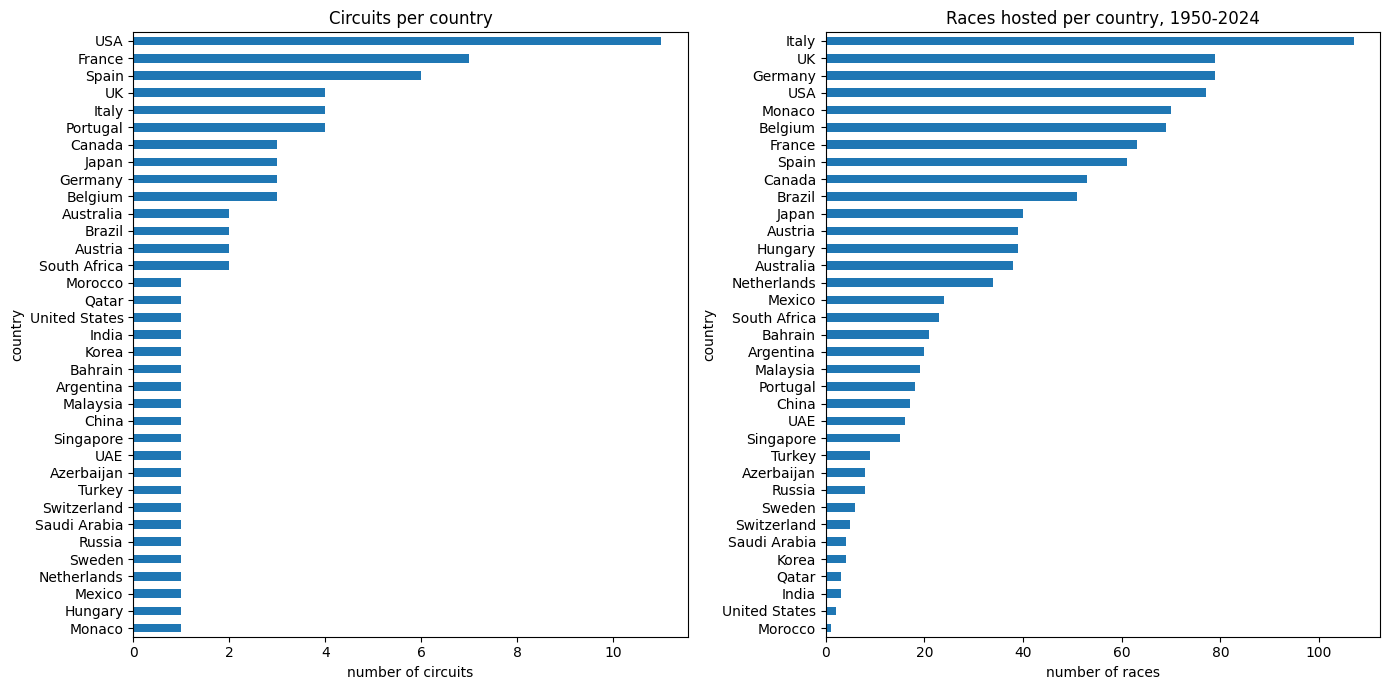

In [5]:
# ==========================================================================================
# A4 · circuits + drivers: how are countries spelled, and can they be matched to driver nationalities?
# ==========================================================================================

# Why: question 2 asks "do drivers podium more at HOME?". A home race is one where the driver's nationality
# matches the circuit's country, so before we can build that match we must know how both sides are written.
ci = as_num(raw["circuits"])          # exploring copy of circuits (raw stays untouched)
dr = as_num(raw["drivers"])           # exploring copy of drivers, only to compare the two vocabularies

# ---------- 1. Every country spelling, with how many circuits and races it has ----------
races_per_country = (races.merge(ci[["circuitId", "country"]], on="circuitId")   # give every race its circuit's country
                          .groupby("country").size().rename("races"))
country_table = (ci.groupby("country").size().rename("circuits").to_frame()       # circuits per country
                   .join(races_per_country)                                       # add races per country
                   .sort_values("races", ascending=False))
print("Different country spellings:", len(country_table))
display(country_table)

# ---------- 2. Which spellings are abbreviations, or two spellings of the same country? ----------
abbreviations = [c for c in country_table.index if c.isupper() and len(c) <= 3]   # UK, UAE, USA ...
print("Abbreviated country names:", abbreviations)
print("Both 'USA' and 'United States' present:", {"USA", "United States"} <= set(country_table.index))
display(ci[ci.country.isin(["USA", "United States"])][["circuitRef", "location", "country"]].sort_values("country"))

# ---------- 3. What happens if we merge those two spellings? ----------
usa_fixed = ci.country.replace({"United States": "USA"})          # a copy; the raw table is untouched
print("Countries before merging:", ci.country.nunique(), "| after merging 'United States' into 'USA':", usa_fixed.nunique())
print("Circuits in the USA after merging:", int((usa_fixed == "USA").sum()))

# ---------- 4. Can we simply join circuit countries to driver nationalities? ----------
# A home race needs "British driver" <-> "UK circuit". We test whether the words are ever identical.
same_words = sorted(set(ci.country) & set(dr.nationality))
print("Circuit countries spelled exactly like a driver nationality:", same_words, f"({len(same_words)} of {ci.country.nunique()})")
print("Examples of the mismatch: circuits say", ["UK", "Germany", "Monaco"], "| drivers say", ["British", "German", "Monegasque"])

# ---------- 5. Plot: where F1 circuits are, and where the races were (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
country_table.circuits.sort_values().plot.barh(ax=ax[0], title="Circuits per country")
ax[0].set_xlabel("number of circuits")
country_table.races.sort_values().plot.barh(ax=ax[1], title="Races hosted per country, 1950-2024")
ax[1].set_xlabel("number of races")
plt.tight_layout()
plt.savefig("figures/A4_circuits_per_country.png", dpi=120, bbox_inches="tight")
plt.show()

**A4 result:**
- The table has **35 country spellings**. Italy hosted the most races (107), then the UK and Germany (79 each); Monaco hosted 70 from a single circuit.
- Three names are **abbreviations** (`UK`, `USA`, `UAE`), and `Korea` is a short form.
- **The USA is spelled two ways.** Eleven circuits say `USA`, but the newer Las Vegas Strip circuit says `United States` (only 2 races). Merging them gives **34 countries**, **12 US circuits** and 79 US races, the same as the UK and Germany.
- **The two sides never match as written:** 0 of the 35 circuit countries are spelled like a driver nationality (circuits say "UK", "Germany", "Monaco"; drivers say "British", "German", "Monegasque"). A direct join would find **no home races at all**.

**Decisions for cleaning and Q2:** merge `United States` into `USA` (or map both); join on `country` only, never on `location` (A2 showed two cities repeat); build a written nationality-to-country map as a table in the notebook (started in A7, finished in the Q2 task), and report how many countries have no matching driver nationality.

## A5 · drivers: profile, why number and code are missing, and which column identifies a driver

- **What:** profile the `drivers` table, test every column as a possible identifier (missing values? repeats?), look at the columns that *look* like identifiers (`code`, `number`, surname), and find out **why** `number` and `code` are mostly empty by comparing them with the year each driver first raced.
- **Why:** `drivers` is joined to results, standings, lap times and pit stops, so one wrong choice of key would silently mix up drivers. And the reason a value is missing decides what we may do with it: a value missing at random can be filled, but a value missing because it did not exist yet in that era should stay missing and be flagged.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
driverId,0,0.00,0,861,100.0,1
driverRef,0,0.00,0,861,0.0,hamilton
number,802,93.15,0,49,6.9,44
code,757,87.92,0,98,0.0,HAM
forename,0,0.00,0,478,0.0,Lewis
surname,0,0.00,0,802,0.0,Hamilton
dob,0,0.00,0,843,0.0,1985-01-07
nationality,0,0.00,0,43,0.0,British
url,0,0.00,0,861,0.0,http://en.wikipedia.org/wiki/Lewis_Hamilton


{'table': 'drivers', 'key': 'driverId', 'rows': 861, 'duplicates': 0, 'null_or_sentinel': 0}
driverId         int64
driverRef       object
number         float64
code            object
forename        object
surname         object
dob             object
nationality     object
url             object
dtype: object


,missing,repeated values,usable as identifier
driverId,0,0,True
driverRef,0,0,True
url,0,0,True
code,757,7,False
number,802,11,False
surname,0,59,False
forename + surname,0,0,True


,code,forename,surname
26,ALB,Christijan,Albers
846,ALB,Alexander,Albon
375,BIA,Lucien,Bianchi
823,BIA,Jules,Bianchi
37,DOO,Robert,Doornbos
860,DOO,Jack,Doohan
836,HAR,Rio,Haryanto
841,HAR,Brendon,Hartley
75,MAG,Jan,Magnussen
824,MAG,Kevin,Magnussen


Car numbers used by more than one driver: 11 numbers, shared by 22 drivers
Surnames shared by several drivers: 45 | most common: {'Taylor': 5, 'Wilson': 4, 'Fittipaldi': 4}
driverId runs from 1 to 862 | skipped ids: [809]
driverRef values with capital letters: ['Cannoc', 'Changy', 'scott_Brown']
dob written as YYYY-MM-DD for every driver: True
Names with accented letters: 61


,drivers,number_missing_pct,code_missing_pct
debut_decade,,,
1950,332,100,100
1960,145,100,100
1970,135,100,100
1980,79,100,100
1990,66,100,82
2000,49,78,27
2010,41,17,0
2020,14,0,0


Drivers who debuted from 2014: number present 100 % | code present 100 %
Drivers who debuted before 2014: with a number: 21 of 823


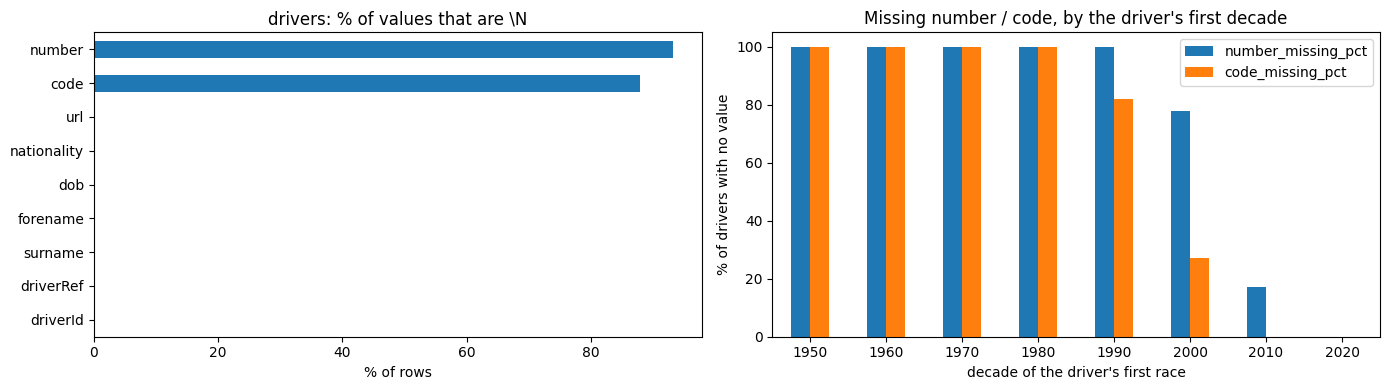

In [6]:
# ==========================================================================================
# A5 · drivers: profile, why number and code are missing, and which columns can identify a driver
# ==========================================================================================

# Why: drivers is joined to results, standings, lap times... so we must know exactly which column
# can safely identify a driver, and why two of its columns (number, code) are mostly empty.
dr = as_num(raw["drivers"])          # exploring copy of drivers (raw stays untouched)

# ---------- 1. Profile card: one row per column ----------
display(profile("drivers"))
print(pk_check("drivers", ["driverId"]))
print(dr.dtypes)                      # note: number is stored as decimals (44.0) only because some values are missing

# ---------- 2. Which column could identify a driver? Test every candidate ----------
# A good identifier has no missing values and never repeats. We test the obvious candidates.
candidates = {"driverId": dr.driverId, "driverRef": dr.driverRef, "url": dr.url,
              "code": dr.code, "number": dr.number, "surname": dr.surname,
              "forename + surname": dr.forename + " " + dr.surname}
id_check = pd.DataFrame({name: {"missing": int(s.isna().sum()),                       # empty cells
                                "repeated values": int(s.dropna().duplicated().sum()),  # values that appear again
                                "usable as identifier": bool(s.isna().sum() == 0 and not s.duplicated().any())}
                         for name, s in candidates.items()}).T
display(id_check)

# ---------- 3. The columns that look like identifiers but are not ----------
shared_codes = dr[dr.code.notna() & dr.code.duplicated(keep=False)].sort_values("code")      # 3-letter code used by 2 drivers
display(shared_codes[["code", "forename", "surname"]])
shared_numbers = dr[dr.number.notna() & dr.number.duplicated(keep=False)].sort_values("number")   # car number used by 2 drivers
print("Car numbers used by more than one driver:", shared_numbers.number.nunique(),
      "numbers, shared by", len(shared_numbers), "drivers")
print("Surnames shared by several drivers:", dr.surname[dr.surname.duplicated()].nunique(),
      "| most common:", dr.surname.value_counts().head(3).to_dict())

# ---------- 4. Small data-quality checks ----------
gaps = sorted(set(range(1, int(dr.driverId.max()) + 1)) - set(dr.driverId))   # driverId values that are skipped
print("driverId runs from", dr.driverId.min(), "to", dr.driverId.max(), "| skipped ids:", gaps)
odd_ref = dr.driverRef[~dr.driverRef.str.match(r"^[a-z0-9_\-]+$")]            # refs are normally lower_case
print("driverRef values with capital letters:", odd_ref.tolist())
print("dob written as YYYY-MM-DD for every driver:", dr.dob.str.match(r"^\d{4}-\d{2}-\d{2}$").all())
print("Names with accented letters:", int(dr.forename.map(lambda s: not s.isascii()).sum() + dr.surname.map(lambda s: not s.isascii()).sum()))

# ---------- 5. WHY are number and code missing? Is it random, or does it depend on the era? ----------
# A driver's first season, taken from the race results
first_year = (results.assign(year=year_of(results), driverId=results.driverId.astype(int))
                     .groupby("driverId").year.min())
dr["debut_year"] = dr.driverId.map(first_year)
dr["debut_decade"] = dr.debut_year // 10 * 10
missing_by_decade = dr.groupby("debut_decade").agg(
    drivers=("driverId", "size"),
    number_missing_pct=("number", lambda s: round(s.isna().mean() * 100)),   # % of these drivers with no car number
    code_missing_pct=("code", lambda s: round(s.isna().mean() * 100)))       # % of these drivers with no 3-letter code
display(missing_by_decade)
modern = dr[dr.debut_year >= 2014]
print("Drivers who debuted from 2014: number present", round(modern.number.notna().mean() * 100), "% | code present",
      round(modern.code.notna().mean() * 100), "%")
print("Drivers who debuted before 2014: with a number:", int(dr[dr.debut_year < 2014].number.notna().sum()),
      "of", int((dr.debut_year < 2014).sum()))

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
profile("drivers")["sentinel_%"].sort_values().plot.barh(ax=ax[0], title="drivers: % of values that are \\N")
ax[0].set_xlabel("% of rows")
missing_by_decade[["number_missing_pct", "code_missing_pct"]].plot.bar(
    ax=ax[1], rot=0, title="Missing number / code, by the driver's first decade")
ax[1].set_xlabel("decade of the driver's first race")
ax[1].set_ylabel("% of drivers with no value")
plt.tight_layout()
plt.savefig("figures/A5_drivers_missing.png", dpi=120, bbox_inches="tight")
plt.show()

**A5 result:**
- 861 drivers. **Only two columns have missing values: `number` (93%) and `code` (88%).** Everything else, including `dob` and `nationality`, is complete.
- **The missing values follow the era, not chance.** Every driver who debuted in the 1950s to 1980s has no number and no code; the share falls to 78% (number) and 27% (code) for 2000s debuts, and to **0% for drivers who started from 2014** (permanent car numbers were introduced in 2014; codes became common in the 2000s). So "missing" here means "did not exist yet".
- **Safe identifiers:** `driverId`, `driverRef` and `url` (no missing values, no repeats). Full name also happens to be unique, but names can change spelling, so we do not use it.
- **Not identifiers:** `code` (7 codes are shared by two drivers each, e.g. `VER` is Vergne **and** Verstappen, `MSC` is Michael **and** Mick Schumacher), `number` (11 numbers are reused by 22 drivers) and `surname` (45 surnames are shared, e.g. 5 Taylors).
- Small quirks: `number` is stored as decimals (44.0) only because of the missing values, `driverId` skips 809, three `driverRef` values start with a capital (`Cannoc`, `Changy`, `scott_Brown`), and 61 names have accents (they read correctly).

**Decisions for cleaning:** use `driverId` as the only driver key, never join on `code`, `number` or names; keep `number` and `code` out of the model (they are labels, and their absence only tells the era), or keep them only as text labels in plots; do not fill them in. Date of birth is complete, so age can be computed for every driver (checked in A6).

## A6 · drivers: dates of birth and age at every race

- **What:** convert the `dob` text into real dates (stopping with an error if any cannot be read), look for placeholder-looking dates, join drivers to results and races to compute every driver's age on every race day, check that every age is possible, and see how the age of the grid changed over the decades.
- **Why:** "driver age at the race date" will be a context feature. It is known before the race starts, so it is allowed. But if even one date of birth were wrong, or a placeholder, the feature would quietly mislead the model, so we check before using it.

dob type: datetime64[ns] | earliest: 1896-12-28 | latest: 2005-05-08
Birth decades: {1890: 7, 1900: 40, 1910: 115, 1920: 162, 1930: 140, 1940: 125, 1950: 75, 1960: 72, 1970: 44, 1980: 39, 1990: 35, 2000: 7}
Born on 1 January: 7 (about 2 to 3 would be expected by chance among 861 drivers)
Drivers sharing a birthdate with another driver: 36 in 18 different dates
Age at a race: youngest 17.5 | oldest 58.8
Negative ages: 0 | under 17: 0 | over 55: 4


,surname,year,age
22546,Verstappen,2015,17.5
22558,Verstappen,2015,17.5


,surname,year,age
18522,Chiron,1958,58.8
18912,Chiron,1956,56.8


Drivers with no race at all: 0 | born after their first race: 0
Age at first race: median 28.5 | older than 45: 27 | younger than 18: 1


,median age at first race
debut_decade,
1950,32.8
1960,28.7
1970,28.7
1980,26.6
1990,25.5
2000,24.1
2010,23.0
2020,22.0


Debuts after age 45, by decade of debut: {1950: 24, 1960: 3}
Median driver age per season: 1950 = 39.0 | 1980 = 30.3 | 2024 = 27.9


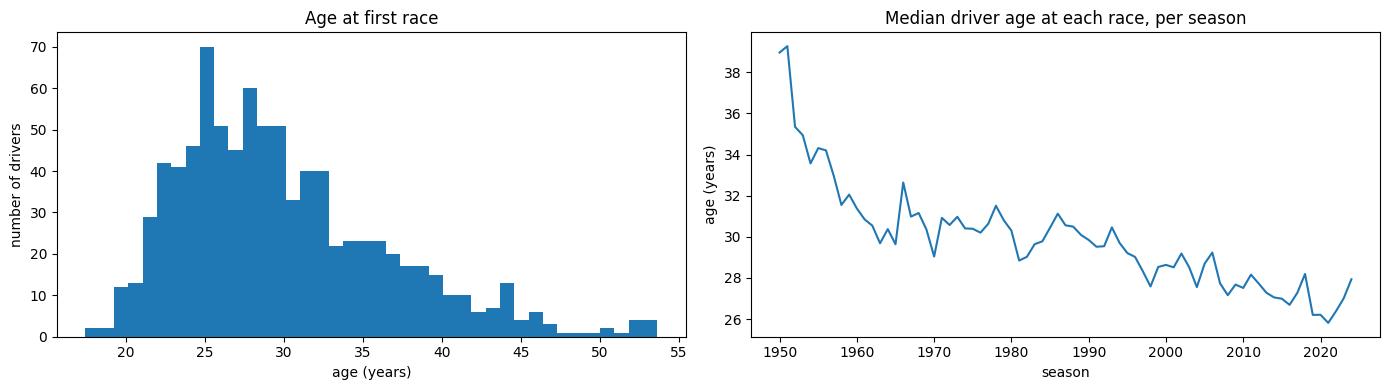

In [7]:
# ==========================================================================================
# A6 · drivers + results + races: dates of birth, and the age of every driver at every race
# ==========================================================================================

# Why: "age at the race date" will be one of our context features, and it is known before the race starts.
# For that, every date of birth must be a real date, and every age must be possible.
dr = as_num(raw["drivers"])           # exploring copy of drivers (raw stays untouched)

# ---------- 1. Turn the text dates into real dates ----------
# errors="raise" makes pandas STOP with an error if even one value cannot be read, so a silent mistake is impossible
dr["dob"] = pd.to_datetime(dr.dob, format="%Y-%m-%d", errors="raise")
print("dob type:", dr.dob.dtype, "| earliest:", dr.dob.min().date(), "| latest:", dr.dob.max().date())
print("Birth decades:", (dr.dob.dt.year // 10 * 10).value_counts().sort_index().to_dict())

# ---------- 2. Does any date look like a placeholder? ----------
# Unknown birthdays are sometimes stored as 1 January. We count them, and drivers sharing the exact same date.
print("Born on 1 January:", int(((dr.dob.dt.month == 1) & (dr.dob.dt.day == 1)).sum()),
      "(about 2 to 3 would be expected by chance among 861 drivers)")
shared = dr[dr.dob.duplicated(keep=False)]
print("Drivers sharing a birthdate with another driver:", len(shared), "in", shared.dob.nunique(), "different dates")

# ---------- 3. Every driver-race pair, with the race date and the driver's date of birth ----------
rr = (results[["raceId", "driverId"]].astype(int)                        # one row per driver per race (from results)
        .merge(races[["raceId", "date", "year"]], on="raceId")            # add the race date
        .merge(dr[["driverId", "surname", "dob"]], on="driverId"))        # add the date of birth
rr["age"] = (rr.date - rr.dob).dt.days / 365.25                          # age in years on the day of the race

# ---------- 4. Are all ages possible? ----------
print("Age at a race: youngest", round(rr.age.min(), 1), "| oldest", round(rr.age.max(), 1))
print("Negative ages:", int((rr.age < 0).sum()), "| under 17:", int((rr.age < 17).sum()), "| over 55:", int((rr.age > 55).sum()))
display(rr.nsmallest(2, "age")[["surname", "year", "age"]].round(1))      # the youngest entries
display(rr.nlargest(2, "age")[["surname", "year", "age"]].round(1))       # the oldest entries
first_race = rr.groupby("driverId").date.min()                            # the date of each driver's first race
dr["debut"] = dr.driverId.map(first_race)
print("Drivers with no race at all:", int(dr.debut.isna().sum()),
      "| born after their first race:", int((dr.dob > dr.debut).sum()))

# ---------- 5. Age at the first race, and how the grid aged over the decades ----------
dr["age_debut"] = (dr.debut - dr.dob).dt.days / 365.25
dr["debut_decade"] = dr.debut.dt.year // 10 * 10
print("Age at first race: median", round(dr.age_debut.median(), 1),
      "| older than 45:", int((dr.age_debut > 45).sum()), "| younger than 18:", int((dr.age_debut < 18).sum()))
display(dr.groupby("debut_decade").age_debut.median().round(1).rename("median age at first race").to_frame())
old = dr[dr.age_debut > 45]
print("Debuts after age 45, by decade of debut:", old.groupby("debut_decade").size().to_dict())
median_age = rr.groupby("year").age.median()                              # median age of all drivers in each season
print("Median driver age per season: 1950 =", round(median_age[1950], 1), "| 1980 =", round(median_age[1980], 1),
      "| 2024 =", round(median_age[2024], 1))

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
dr.age_debut.plot.hist(bins=40, ax=ax[0], title="Age at first race")
ax[0].set_xlabel("age (years)")
ax[0].set_ylabel("number of drivers")
median_age.plot(ax=ax[1], title="Median driver age at each race, per season")
ax[1].set_xlabel("season")
ax[1].set_ylabel("age (years)")
plt.tight_layout()
plt.savefig("figures/A6_driver_ages.png", dpi=120, bbox_inches="tight")
plt.show()

**A6 result:**
- **All 861 dates of birth are valid dates** (no `\N`, no unreadable text), from 28 December 1896 to 8 May 2005, and none is in the future.
- **Every age is possible.** No driver is born after their first race, no age is negative, none is under 17. The youngest entry is Max Verstappen at **17.5** (2015); the oldest is Louis Chiron at **58.8** (1958); only 4 entries are over 55.
- **No sign of placeholder dates:** 7 drivers were born on 1 January (about 2 to 3 would be expected by chance), and 36 drivers share a birthdate with one other driver (18 dates). That is slightly high but plausible, and the data cannot prove they are placeholders, so we only note it.
- **The grid has become much younger.** The median age at a race fell from **39.0 in 1950 to 30.3 in 1980 and 27.9 in 2024**; the median age at a driver's first race fell from 32.8 (1950s debuts) to 22.0 (2020s). All 27 debuts after age 45 happened in the 1950s (24) and 1960s (3).

**Decisions for cleaning and features:** convert `dob` to a date in the silver table; build `driver_age` as age in years on the race date (it is allowed before the race); expect age to behave differently by era, so remember it in the report's era-sensitivity limitation; do not drop or fix any date of birth.

## A7 · drivers: nationalities, and the first nationality-to-country map (for question 2)

- **What:** list every nationality value, fix inconsistencies on a copy, count drivers and race entries per nationality, and write the **first version of the map from nationality to circuit country**, with three safety checks (a mapped country must exist in `circuits`; a "no circuit" country must not; every nationality must be covered). We then use the map to preview how many home races exist.
- **Why:** question 2 compares podium rates at home and away. A4 showed that circuit countries ("UK") and driver nationalities ("British") are never spelled the same, so without a written map a join would find no home races at all.

Different nationality values: 43
Values with stray spaces: ['Argentinian ']
After trimming and merging 'Argentinian' into 'Argentine': 42


,drivers,race_entries
nationality_clean,,
British,166,4559
Italian,99,3418
French,73,3095
German,50,2430
Brazilian,32,1953
American,158,1315
Finnish,9,1193
Spanish,15,913
Australian,19,893


Nationalities with a single driver: 10


,forename,surname,nationality_clean
339,John,Love,Rhodesian
367,Sam,Tingle,Rhodesian
413,Clive,Puzey,Rhodesian
473,Gary,Hocking,Rhodesian
491,Alfonso,Thiele,American-Italian
573,Alessandro,de Tomaso,Argentine-Italian
709,Ernst,Klodwig,East German
710,Rudolf,Krause,East German
713,Theo,Fitzau,East German


,drivers,race_entries,country,status
nationality_clean,,,,
British,166,4559,UK,mapped
Italian,99,3418,Italy,mapped
French,73,3095,France,mapped
German,50,2430,Germany,mapped
Brazilian,32,1953,Brazil,mapped
American,158,1315,USA,mapped
Finnish,9,1193,Finland,no circuit in that country
Spanish,15,913,Spain,mapped
Australian,19,893,Australia,mapped


Nationalities: 42 | mapped: 25 | no circuit in their country: 13 | mixed or historical: 4
Circuit countries with no driver nationality: 9 of 34 -> ['Azerbaijan', 'Bahrain', 'Korea', 'Morocco', 'Qatar', 'Saudi Arabia', 'Singapore', 'Turkey', 'UAE']
Entries that are a home race: 2523 of 26759 (9.4%) | entries by drivers with a mapped nationality: 24279
Home entries by nationality (top 6): {'American': 525, 'British': 488, 'Italian': 466, 'French': 219, 'German': 208, 'Brazilian': 119}
Nationalities with at least 100 home entries: 6 | at least 30: 13
Indianapolis 500 entries: 405 | of which home entries: 404
Home entries without the Indy 500: 2119 | American home entries: 525 -> 121


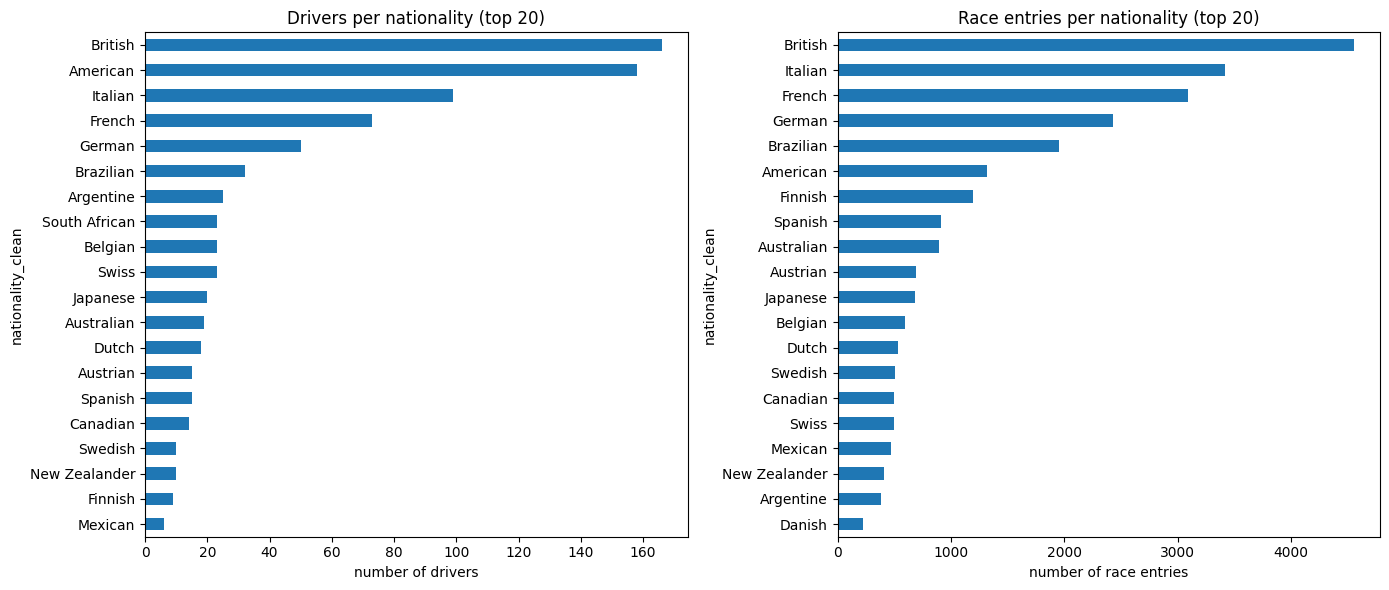

In [8]:
# ==========================================================================================
# A7 · drivers + circuits: driver nationalities, and a first written map to circuit countries (for Q2)
# ==========================================================================================

# Why: question 2 asks whether drivers podium more often at HOME. A4 showed that circuit countries ("UK")
# and driver nationalities ("British") are written differently, so we need a map from one to the other.
# Here we list every nationality, spot inconsistencies, and write the first version of that map.
dr = as_num(raw["drivers"])           # exploring copy of drivers (raw stays untouched)
ci = as_num(raw["circuits"])          # exploring copy of circuits

# ---------- 1. Every nationality value, and the inconsistencies ----------
print("Different nationality values:", dr.nationality.nunique())
print("Values with stray spaces:", list(dr.nationality[dr.nationality != dr.nationality.str.strip()].unique()))
# Fix on a COPY: remove stray spaces, and merge "Argentinian" into "Argentine" (the same nationality, written two ways)
dr["nationality_clean"] = dr.nationality.str.strip().replace({"Argentinian": "Argentine"})
print("After trimming and merging 'Argentinian' into 'Argentine':", dr.nationality_clean.nunique())

# ---------- 2. How many drivers, and how many race entries, does each nationality have? ----------
entries = (results[["raceId", "driverId"]].astype(int)                        # one row per driver per race
           .merge(dr[["driverId", "nationality_clean"]], on="driverId"))      # add the driver's nationality
per_nat = pd.DataFrame({"drivers": dr.nationality_clean.value_counts(),                # number of different drivers
                        "race_entries": entries.nationality_clean.value_counts()       # number of race starts and entries
                        }).fillna(0).astype(int).sort_values("race_entries", ascending=False)
display(per_nat.head(10))
print("Nationalities with a single driver:", int((per_nat.drivers == 1).sum()))

# ---------- 3. Mixed and historical nationalities ----------
MIXED = ["American-Italian", "Argentine-Italian", "East German", "Rhodesian"]    # two countries, or a country that no longer exists
display(dr[dr.nationality_clean.isin(MIXED)][["forename", "surname", "nationality_clean"]])

# ---------- 4. The first version of the nationality -> country map ----------
# Circuit countries as written in circuits (with the two USA spellings merged, as decided in A4)
circuit_countries = set(ci.country.replace({"United States": "USA"}))
NAT_TO_COUNTRY = {                       # nationality -> the way the SAME country is written in circuits
    "American": "USA", "Argentine": "Argentina", "Australian": "Australia", "Austrian": "Austria",
    "Belgian": "Belgium", "Brazilian": "Brazil", "British": "UK", "Canadian": "Canada", "Chinese": "China",
    "Dutch": "Netherlands", "French": "France", "German": "Germany", "Hungarian": "Hungary", "Indian": "India",
    "Italian": "Italy", "Japanese": "Japan", "Malaysian": "Malaysia", "Mexican": "Mexico", "Monegasque": "Monaco",
    "Portuguese": "Portugal", "Russian": "Russia", "South African": "South Africa", "Spanish": "Spain",
    "Swedish": "Sweden", "Swiss": "Switzerland"}
NO_CIRCUIT = {                           # nationalities whose country has no F1 circuit in the data: a home race is impossible
    "Chilean": "Chile", "Colombian": "Colombia", "Czech": "Czech Republic", "Danish": "Denmark", "Finnish": "Finland",
    "Indonesian": "Indonesia", "Irish": "Ireland", "Liechtensteiner": "Liechtenstein", "New Zealander": "New Zealand",
    "Polish": "Poland", "Thai": "Thailand", "Uruguayan": "Uruguay", "Venezuelan": "Venezuela"}
# Three safety checks, so the map cannot silently be wrong:
assert set(NAT_TO_COUNTRY.values()) <= circuit_countries, "a mapped country is not spelled like a circuit country"
assert not (set(NO_CIRCUIT.values()) & circuit_countries), "a 'no circuit' country does have a circuit"
assert set(NAT_TO_COUNTRY) | set(NO_CIRCUIT) | set(MIXED) == set(dr.nationality_clean), "some nationality is not covered"

def map_status(nat):
    if nat in NAT_TO_COUNTRY: return "mapped"
    if nat in NO_CIRCUIT: return "no circuit in that country"
    return "mixed or historical: decide in Q2"
map_table = per_nat.copy()
map_table["country"] = map_table.index.map(lambda n: NAT_TO_COUNTRY.get(n, NO_CIRCUIT.get(n, "")))
map_table["status"] = map_table.index.map(map_status)
display(map_table)
print("Nationalities:", len(map_table), "| mapped:", int((map_table.status == "mapped").sum()),
      "| no circuit in their country:", int((map_table.status == "no circuit in that country").sum()),
      "| mixed or historical:", int((map_table.status == "mixed or historical: decide in Q2").sum()))
no_driver = sorted(circuit_countries - set(NAT_TO_COUNTRY.values()))        # circuit countries with no driver nationality
print("Circuit countries with no driver nationality:", len(no_driver), "of", len(circuit_countries), "->", no_driver)

# ---------- 5. A first look at how many home races exist (before any cleaning) ----------
entries["driver_country"] = entries.nationality_clean.map(NAT_TO_COUNTRY)                # the driver's country (NaN if unmapped)
race_country = (races[["raceId", "circuitId"]].merge(ci[["circuitId", "country"]], on="circuitId")
                .assign(circuit_country=lambda d: d.country.replace({"United States": "USA"}))[["raceId", "circuit_country"]])
entries = entries.merge(race_country, on="raceId")                                       # add the circuit's country
entries["is_home"] = entries.driver_country == entries.circuit_country                   # True for a home race
print("Entries that are a home race:", int(entries.is_home.sum()), "of", len(entries),
      f"({entries.is_home.mean() * 100:.1f}%) | entries by drivers with a mapped nationality:", int(entries.driver_country.notna().sum()))
home_by_nat = entries[entries.is_home].groupby("nationality_clean").size().sort_values(ascending=False)
print("Home entries by nationality (top 6):", home_by_nat.head(6).to_dict())
print("Nationalities with at least 100 home entries:", int((home_by_nat >= 100).sum()), "| at least 30:", int((home_by_nat >= 30).sum()))

# The Indianapolis 500 (1950-1960) counted as a championship race, but almost only Americans entered it. Does it inflate the US numbers?
indy_races = set(races.loc[races.name.str.contains("Indianapolis 500"), "raceId"])       # the 11 Indy 500 races
entries["is_indy500"] = entries.raceId.isin(indy_races)
print("Indianapolis 500 entries:", int(entries.is_indy500.sum()), "| of which home entries:", int((entries.is_indy500 & entries.is_home).sum()))
home_no_indy = entries[entries.is_home & ~entries.is_indy500].groupby("nationality_clean").size().sort_values(ascending=False)
print("Home entries without the Indy 500:", int(home_no_indy.sum()),
      "| American home entries:", int(home_by_nat["American"]), "->", int(home_no_indy.get("American", 0)))

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
per_nat.drivers.sort_values(ascending=False).head(20).sort_values().plot.barh(ax=ax[0], title="Drivers per nationality (top 20)")
ax[0].set_xlabel("number of drivers")
per_nat.race_entries.head(20).sort_values().plot.barh(ax=ax[1], title="Race entries per nationality (top 20)")
ax[1].set_xlabel("number of race entries")
plt.tight_layout()
plt.savefig("figures/A7_nationalities.png", dpi=120, bbox_inches="tight")
plt.show()

**A7 result:**
- **43 nationality values, 42 real nationalities.** `Argentinian ` (with a trailing space) is the same nationality as `Argentine`, so we trim and merge it.
- **The map covers all 42:** **25 nationalities map to a circuit country** (British to UK, Monegasque to Monaco, American to USA, ...), **13 have no circuit in their country** (for example Finnish, Danish, New Zealander, Polish, Thai), so those drivers can never have a home race, and **4 are mixed or historical** (American-Italian, Argentine-Italian, East German, Rhodesian: 9 drivers in total) and need a decision in Q2.
- **The other direction too:** **9 of the 34 circuit countries have no driver nationality at all** (Azerbaijan, Bahrain, Korea, Morocco, Qatar, Saudi Arabia, Singapore, Turkey, UAE), so races there are never home races.
- **Drivers and entries rank differently.** Americans are the second largest group by drivers (158) but only sixth by race entries (1,315), while Finns are only 9 drivers with 1,193 entries, but no Finnish circuit.
- **A preview of Q2's sample:** 2,523 of the 26,759 entries (9.4%) are home races, mostly British, Italian, French, German and American drivers. **But 404 of the 405 Indianapolis 500 entries are Americans at home.** Without that race, American home entries fall from **525 to 121** and the total from 2,523 to **2,119**. Only 6 nationalities have 100 or more home entries.

**Decisions for cleaning and Q2:** trim spaces and merge `Argentinian` into `Argentine`; keep the written map as a table in the notebook; decide the four mixed or historical nationalities in the Q2 task; **exclude the Indianapolis 500 from Q2** (or report with and without it), because it makes American home advantage look much bigger than it is; remember that these counts still include non-starters, which T6 will remove.

## A8 · constructors: profile, activity, and whether "a constructor" is one continuous team

- **What:** profile the `constructors` table and its keys, count how many races each constructor entered (using `results`), and test two things we have been assuming: that one team is **one** constructor, and that a constructor is **one continuous** team. We also look at who was active in the modern era, how many cars a team entered, and the Indianapolis 500.
- **Why:** question 3 compares constructors, and "team form" (how well a team did in earlier races) will be a feature. If one team hides under several IDs, or one ID covers teams that raced decades apart, a team's "form" would be computed from the wrong history.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
constructorId,0,0.0,0,212,100.0,1
constructorRef,0,0.0,0,212,0.0,mclaren
name,0,0.0,0,212,0.0,McLaren
nationality,0,0.0,0,24,0.0,British
url,0,0.0,0,175,0.0,http://en.wikipedia.org/wiki/McLaren


{'table': 'constructors', 'key': 'constructorId', 'rows': 212, 'duplicates': 0, 'null_or_sentinel': 0}
constructorRef unique: True | name unique: True | url unique: False
constructorId runs from 1 to 215 | skipped ids: [43, 165, 212]
Constructor nationalities not used by any driver: ['Hong Kong'] | different nationalities: 24
Constructors with no result rows: [['eagle', 'Eagle']]
With 5 or fewer entries: 70 | racing in a single season only: 70 | with 100 or more entries: 56 | with 1,000 or more: 3


,name,entries,first,last
5,Ferrari,2439.0,1950.0,2024.0
0,McLaren,1923.0,1968.0,2024.0
2,Williams,1676.0,1975.0,2024.0
24,Tyrrell,881.0,1970.0,1998.0
31,Team Lotus,871.0,1958.0,1994.0


Constructors that share a Wikipedia page with another constructor: 50 in 13 groups


,constructorIds,names
url,,
http://en.wikipedia.org/wiki/Cooper_Car_Company,11,"Cooper, Cooper-ATS, Cooper-Alfa Romeo, Cooper-..."
http://en.wikipedia.org/wiki/Team_Lotus,7,"Lotus-BRM, Lotus-Borgward, Lotus-Climax, Lotus..."
http://en.wikipedia.org/wiki/Brabham,6,"Brabham, Brabham-Alfa Romeo, Brabham-BRM, Brab..."
http://en.wikipedia.org/wiki/De_Tomaso,4,"De Tomaso, De Tomaso-Alfa Romeo, De Tomaso-Fer..."
http://en.wikipedia.org/wiki/Anglo_American_Racers,3,"Eagle, Eagle-Climax, Eagle-Weslake"
http://en.wikipedia.org/wiki/Shadow_Racing_Cars,3,"Shadow, Shadow-Ford, Shadow-Matra"


,name,first,last,entries,longest_break_seasons
31,Team Lotus,1958.0,1994.0,871.0,6
14,Sauber,1993.0,2024.0,837.0,5
3,Renault,1977.0,2020.0,787.0,16
33,Brabham,1962.0,1992.0,662.0,6
129,Mercedes,1954.0,2024.0,652.0,54
20,Arrows,1978.0,2002.0,590.0,6
49,Alfa Romeo,1950.0,2023.0,451.0,33
115,Aston Martin,1959.0,2024.0,191.0,60
25,Lola,1962.0,1997.0,165.0,9
52,ATS,1963.0,1984.0,162.0,14


,name,nationality,first,last,entries
5,Ferrari,Italian,1950.0,2024.0,2439.0
49,Alfa Romeo,Swiss,1950.0,2023.0,451.0
129,Mercedes,German,1954.0,2024.0,652.0
115,Aston Martin,British,1959.0,2024.0,191.0
0,McLaren,British,1968.0,2024.0,1923.0
2,Williams,British,1975.0,2024.0,1676.0
3,Renault,French,1977.0,2020.0,787.0
14,Sauber,Swiss,1993.0,2024.0,837.0
8,Red Bull,Austrian,2005.0,2024.0,788.0
4,Toro Rosso,Italian,2006.0,2019.0,536.0


Different constructors in 2014-2021: 19
Different constructors in 2022-2024: 12
Constructors that only ever raced the Indianapolis 500: 31 | their entries: 176
Most cars one constructor entered in a single race: at the Indy 500 = 35 | at all other races = 15


,median,max
decade,,
1950,3.0,15
1960,2.0,11
1970,2.0,7
1980,2.0,4
1990,2.0,2
2000,2.0,2
2010,2.0,2
2020,2.0,2


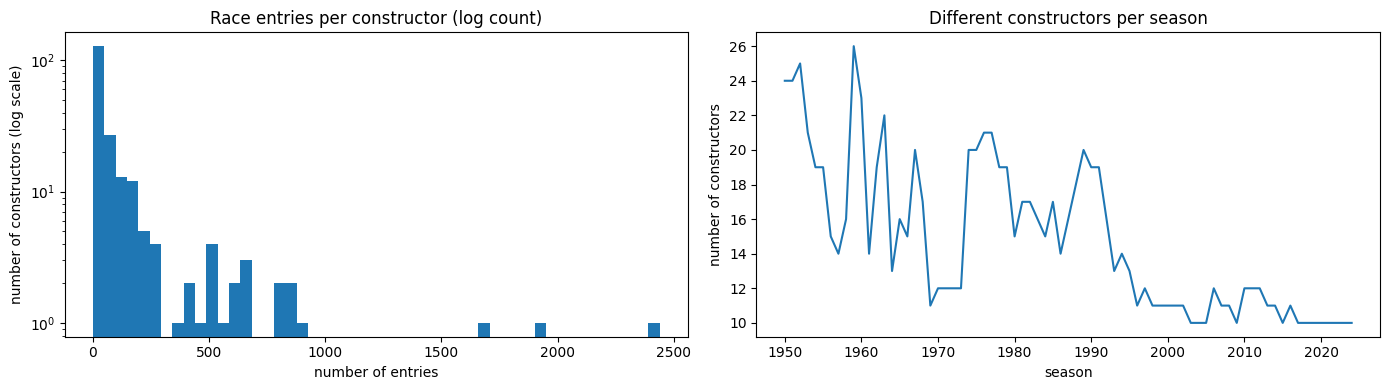

In [9]:
# ==========================================================================================
# A8 · constructors + results: profile, how active each team was, and how team identity behaves over time
# ==========================================================================================

# Why: question 3 compares constructors, and "team form" will be a feature. Both assume that a constructor is ONE
# continuous team. We check whether that is true, and how many constructors are too small to rank.
co = as_num(raw["constructors"])      # exploring copy of constructors (raw stays untouched)

# ---------- 1. Profile card, keys and types ----------
display(profile("constructors"))
print(pk_check("constructors", ["constructorId"]))
print("constructorRef unique:", co.constructorRef.is_unique, "| name unique:", co.name.is_unique, "| url unique:", co.url.is_unique)
gaps = sorted(set(range(1, int(co.constructorId.max()) + 1)) - set(co.constructorId))     # constructorId values that are skipped
print("constructorId runs from", co.constructorId.min(), "to", co.constructorId.max(), "| skipped ids:", gaps)
driver_nationalities = set(raw["drivers"]["nationality"].str.strip())                      # the vocabulary used for drivers (A7)
print("Constructor nationalities not used by any driver:", sorted(set(co.nationality) - driver_nationalities),
      "| different nationalities:", co.nationality.nunique())

# ---------- 2. How active was each constructor? ----------
entries = results[["raceId", "constructorId"]].astype(int)                                  # one row per car per race (ids as numbers)
entries["year"] = entries.raceId.map(YEAR)                                                  # the season of each race
entries = entries.merge(races[["raceId", "name"]].rename(columns={"name": "race_name"}), on="raceId")   # add the race name
act = entries.groupby("constructorId").agg(entries=("raceId", "size"),        # number of cars entered
                                           races=("raceId", "nunique"),       # number of different races
                                           first=("year", "min"), last=("year", "max"))
co2 = co.merge(act, left_on="constructorId", right_index=True, how="left")    # attach to the constructors table (a copy)
print("Constructors with no result rows:", co2[co2.entries.isna()][["constructorRef", "name"]].values.tolist())
print("With 5 or fewer entries:", int((co2.entries <= 5).sum()), "| racing in a single season only:", int((co2["first"] == co2["last"]).sum()),
      "| with 100 or more entries:", int((co2.entries >= 100).sum()), "| with 1,000 or more:", int((co2.entries >= 1000).sum()))
display(co2.nlargest(5, "entries")[["name", "entries", "first", "last"]])

# ---------- 3. Is one constructor always one continuous team? Test 1: one team split over several constructorIds ----------
# Constructors that point to the SAME Wikipedia page are usually one chassis builder paired with different engines
same_page = co[co.url.duplicated(keep=False)].groupby("url").agg(constructorIds=("constructorId", "size"),
                                                                 names=("name", lambda s: ", ".join(sorted(s)[:4]) + (" ..." if len(s) > 4 else "")))
print("Constructors that share a Wikipedia page with another constructor:", int(co.url.duplicated(keep=False).sum()), "in", len(same_page), "groups")
display(same_page.sort_values("constructorIds", ascending=False).head(6))

# ---------- 4. Test 2: one constructorId covering separate periods, years apart ----------
seasons = entries.groupby("constructorId").year.apply(lambda s: sorted(s.unique()))      # the seasons each constructor raced
def longest_break(ys):                                                                    # most consecutive seasons missed in a row
    return max([b - a - 1 for a, b in zip(ys, ys[1:])], default=0)
co2["longest_break_seasons"] = co2.constructorId.map(lambda c: longest_break(seasons.get(c, [])))
display(co2[(co2.longest_break_seasons >= 5) & (co2.entries >= 50)].sort_values("entries", ascending=False)
        [["name", "first", "last", "entries", "longest_break_seasons"]])

# ---------- 5. Who was active in the modern era? (renamed teams are separate constructors) ----------
display(co2[co2["last"] >= 2014].sort_values("first")[["name", "nationality", "first", "last", "entries"]])
for a, b in [(2014, 2021), (2022, 2024)]:                                                 # the two periods of question 3
    print(f"Different constructors in {a}-{b}:", entries[(entries.year >= a) & (entries.year <= b)].constructorId.nunique())

# ---------- 6. Cars per team per race, and the Indianapolis 500 ----------
indy = entries.race_name.str.contains("Indianapolis 500")                                 # the 11 Indy 500 races (1950-1960)
only_indy = set(entries[indy].constructorId) - set(entries[~indy].constructorId)          # constructors that raced nowhere else
print("Constructors that only ever raced the Indianapolis 500:", len(only_indy), "| their entries:",
      int(entries.constructorId.isin(only_indy).sum()))
cars = entries.groupby(["year", "constructorId", "raceId"]).size().reset_index(name="cars")   # cars one team entered in one race
cars["indy"] = cars.raceId.isin(entries[indy].raceId)
print("Most cars one constructor entered in a single race: at the Indy 500 =", int(cars[cars.indy].cars.max()),
      "| at all other races =", int(cars[~cars.indy].cars.max()))
display(cars[~cars.indy].groupby(cars.year // 10 * 10).cars.agg(["median", "max"]).rename_axis("decade"))

# ---------- 7. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
co2.entries.plot.hist(bins=50, logy=True, ax=ax[0], title="Race entries per constructor (log count)")
ax[0].set_xlabel("number of entries")
ax[0].set_ylabel("number of constructors (log scale)")
entries.groupby("year").constructorId.nunique().plot(ax=ax[1], title="Different constructors per season")
ax[1].set_xlabel("season")
ax[1].set_ylabel("number of constructors")
plt.tight_layout()
plt.savefig("figures/A8_constructors.png", dpi=120, bbox_inches="tight")
plt.show()

**A8 result:**
- **The table is clean:** 212 constructors, no `\N`, and `constructorId`, `constructorRef` and `name` are all unique. Only `constructorId` skips three numbers (43, 165, 212), and the one nationality that no driver has is `Hong Kong`.
- **Most constructors are tiny:** **70** raced 5 or fewer times, all in a single season; only **56** have 100 or more entries and only 3 have 1,000 or more (Ferrari 2,439, McLaren 1,923, Williams 1,676). **Eagle** never appears in `results`.
- **One team is often split over several IDs.** 50 constructors share a Wikipedia page with another one (13 groups): the same chassis builder paired with different engines, such as **Cooper (11 IDs), Team Lotus (7), Brabham (6)**. So a team's history is scattered over several `constructorId`s in the 1950s to 1970s.
- **One ID can cover separate periods.** Aston Martin raced 1959–60 and again from 2021 (a 60-season break); Alfa Romeo 1950–85 and 2019–23; Renault 1977–85, 2002–11 and 2016–20; Mercedes 1954–55 and from 2010. A "last 5 races" window on such an ID would reach back decades.
- **Renamed modern teams are separate constructors:** Force India, Racing Point and Aston Martin; Toro Rosso, AlphaTauri and RB; Lotus F1 and Alpine. There are 20 constructors active from 2014, **19 in 2014–2021 and 12 in 2022–2024** (the numbers question 3 will use).
- **Cars per team:** from the 1990s every team enters exactly 2 cars; the 1950s had up to 15 per team. The Indianapolis 500 is odd: **31 constructors raced nowhere else** (176 entries) and one chassis builder had **35 cars** in a single race.
- **The field shrank from 24–26 teams in the 1950s to a steady 10 since 2003.**

**Decisions for cleaning and features:** use `constructorId` as the team key but **do not trust it as one continuous team**: compute team form only from a recent time window (for example the previous 1 or 2 seasons) so a long gap resets it, and add a "prior entries" count; state in the report that renamed teams reset history; for Q3 set a minimum number of starts and mention the renames; **exclude the Indianapolis 500** (its constructors are chassis builders, not teams); keep Eagle, it is harmless.

## A9 · status: the 139 reasons a race ended, and a first grouping for question 3

- **What:** profile the `status` table, count how often each reason is used (overall, and in the two periods of question 3), write a **first draft grouping of all 139 statuses** with a check that none is left out, measure how much the unclear statuses could change question 3, and check how strongly a status points at the podium.
- **Why:** question 3 asks for the **mechanical-retirement rate**, which the brief defines as a start that ended early because a component failed, *excluding* crashes, driver errors and rule decisions. `status` has 139 reasons, so we have to sort them into groups and argue the unclear ones. This is a draft for the team to defend later, not a final answer.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
statusId,0,0.0,0,139,100.0,1
status,0,0.0,0,139,0.0,Finished


{'table': 'status', 'key': 'statusId', 'rows': 139, 'duplicates': 0, 'null_or_sentinel': 0} | status unique: True | duplicates ignoring case and spaces: 0
statusId runs from 1 to 141 | skipped ids: [52, 57]
Statuses that mean 'finished, N laps down': 33
Never used in results: ['+49 Laps', '+38 Laps'] | used 5 times or fewer: 54 | used exactly once: 25
Statuses that appear in 2014-2024: 66 of 139


,statuses,entries
group,,
finished,1,7674
"finished, laps down",33,7487
mechanical (clear),58,6278
accident or collision,5,2774
did not start,4,1613
grey zone,29,712
disqualified or excluded,3,156
driver health,6,65


,2014-2021,2022-2024
group,,
accident or collision,216,89
disqualified or excluded,8,4
driver health,2,1
finished,1533,870
"finished, laps down",1127,295
grey zone,73,19
mechanical (clear),299,76


2014-2021: 3258 race starts | mechanical (clear) = 299 (9.2%) | clear + grey zone = 372 (11.4%)
2022-2024: 1354 race starts | mechanical (clear) = 76 (5.6%) | clear + grey zone = 95 (7.0%)


,entries,podiums
group,,
accident or collision,2774,2
finished,7674,3231
"finished, laps down",7487,159
grey zone,712,5


Groups that contain podium finishes: ['accident or collision', 'finished', 'finished, laps down', 'grey zone']


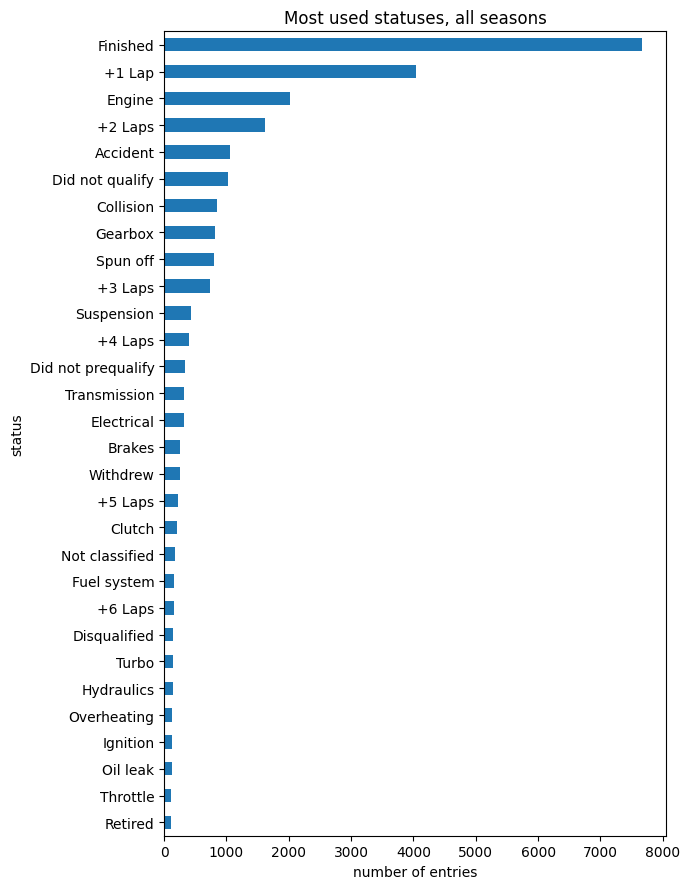

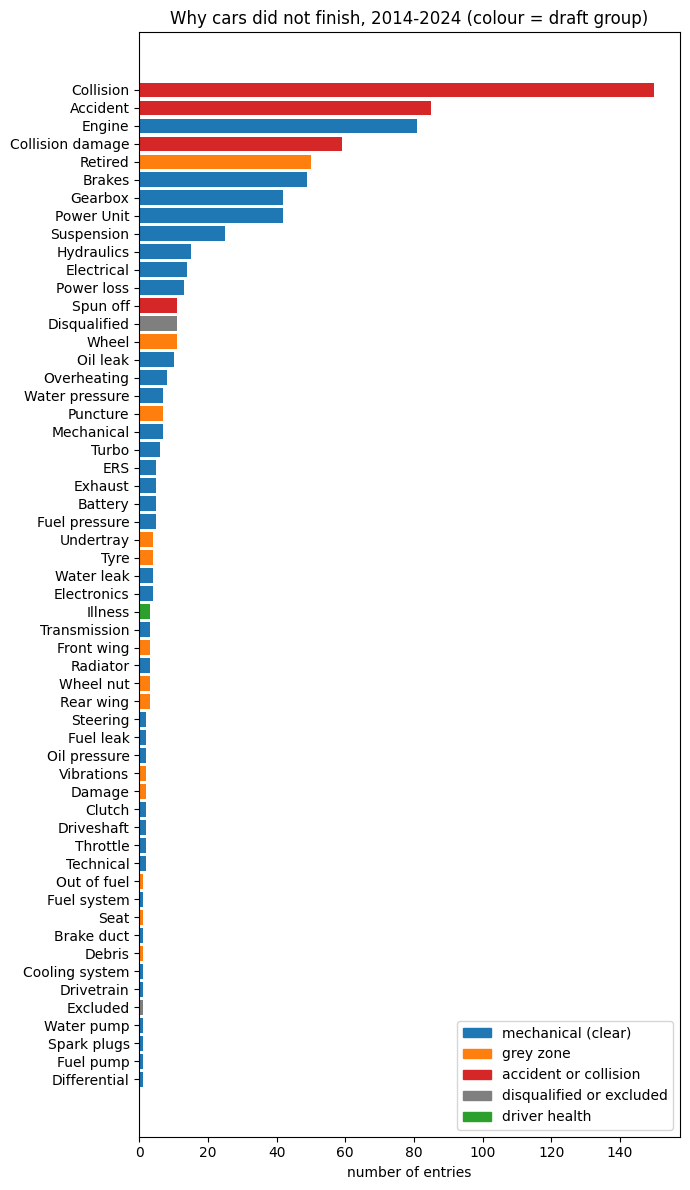

In [10]:
# ==========================================================================================
# A9 · status + results: all 139 reasons a race ended, how often each is used, and a first draft grouping (for Q3)
# ==========================================================================================

# Why: question 3 asks for the mechanical-retirement rate. The brief defines it: "a race start that ended early because a
# component of the car failed. It excludes failures caused by a crash, by the driver, or by a regulation decision."
# The status table has 139 reasons, so we must sort them into groups, and argue the unclear ones.
st = as_num(raw["status"])            # exploring copy of status (raw stays untouched)

# ---------- 1. Profile card, keys and types ----------
display(profile("status"))
print(pk_check("status", ["statusId"]), "| status unique:", st.status.is_unique,
      "| duplicates ignoring case and spaces:", int(st.status.str.lower().str.strip().duplicated().sum()))
gaps = sorted(set(range(1, int(st.statusId.max()) + 1)) - set(st.statusId))        # statusId values that are skipped
print("statusId runs from", st.statusId.min(), "to", st.statusId.max(), "| skipped ids:", gaps)

# ---------- 2. How often is each status used? ----------
r = results[["raceId", "statusId", "positionOrder"]].astype(int)                  # one row per car per race
r["year"] = r.raceId.map(YEAR)
st["uses"] = st.statusId.map(r.statusId.value_counts()).fillna(0).astype(int)                                  # all seasons
st["uses_2014_21"] = st.statusId.map(r[r.year.between(2014, 2021)].statusId.value_counts()).fillna(0).astype(int)   # question 3, period 1
st["uses_2022_24"] = st.statusId.map(r[r.year >= 2022].statusId.value_counts()).fillna(0).astype(int)               # question 3, period 2
lapped = st.status.str.match(r"^\+\d+ Laps?$")                                    # "+1 Lap", "+2 Laps", ...: finished, laps down
print("Statuses that mean 'finished, N laps down':", int(lapped.sum()))
print("Never used in results:", st[st.uses == 0].status.tolist(), "| used 5 times or fewer:", int((st.uses <= 5).sum()),
      "| used exactly once:", int((st.uses == 1).sum()))
print("Statuses that appear in 2014-2024:", int(((st.uses_2014_21 + st.uses_2022_24) > 0).sum()), "of", len(st))

# ---------- 3. A first DRAFT grouping of all 139 statuses ----------
# This is a starting point for the team to argue in the Q3 task, not a final answer.
NOT_STARTED = ["Did not qualify", "Did not prequalify", "107% Rule", "Withdrew"]            # never took the start
REGULATION = ["Disqualified", "Excluded", "Underweight"]                                      # a rules decision, not a failure
ACCIDENT = ["Accident", "Collision", "Collision damage", "Spun off", "Fatal accident"]        # a crash or contact
HEALTH = ["Injury", "Injured", "Eye injury", "Illness", "Driver unwell", "Physical"]          # the driver, not the car
MECHANICAL = ["Engine", "Gearbox", "Suspension", "Transmission", "Electrical", "Brakes", "Clutch", "Fuel system", "Turbo",
              "Hydraulics", "Overheating", "Ignition", "Oil leak", "Throttle", "Halfshaft", "Oil pressure", "Fuel pump",
              "Differential", "Fuel leak", "Steering", "Radiator", "Power Unit", "Wheel bearing", "Injection", "Fuel pressure",
              "Water leak", "Alternator", "Exhaust", "Chassis", "Mechanical", "Magneto", "Driveshaft", "Axle", "Battery",
              "Power loss", "Oil pump", "Distributor", "Oil pipe", "Electronics", "Water pressure", "Water pump", "ERS",
              "Supercharger", "Technical", "Pneumatics", "Fuel pipe", "Spark plugs", "Water pipe", "Drivetrain", "Track rod",
              "Oil line", "Engine fire", "Engine misfire", "Crankshaft", "CV joint", "Cooling system", "Launch control", "Brake duct"]
GREY = ["Retired", "Not classified", "Out of fuel", "Wheel", "Wheel nut", "Wheel rim", "Tyre", "Puncture", "Tyre puncture",
        "Handling", "Heat shield fire", "Fire", "Vibrations", "Broken wing", "Rear wing", "Front wing", "Undertray", "Damage",
        "Debris", "Fuel", "Fuel rig", "Refuelling", "Stalled", "Seat", "Driver Seat", "Safety belt", "Safety", "Safety concerns",
        "Not restarted"]            # could be a failure OR a crash, a team error, or no cause given: the team must decide each one

def group_of(s):
    if s == "Finished": return "finished"
    if lapped[st.status == s].iloc[0]: return "finished, laps down"
    for name, members in [("did not start", NOT_STARTED), ("disqualified or excluded", REGULATION), ("accident or collision", ACCIDENT),
                          ("driver health", HEALTH), ("mechanical (clear)", MECHANICAL), ("grey zone", GREY)]:
        if s in members: return name
    return None
st["group"] = st.status.map(group_of)
assert st.group.notna().all(), "some status has no group"                         # every one of the 139 statuses must be placed
display(st.groupby("group").agg(statuses=("status", "size"), entries=("uses", "sum")).sort_values("entries", ascending=False))

# ---------- 4. How much could the unclear (grey) statuses change question 3? ----------
r = r.merge(st[["statusId", "group"]], on="statusId")                             # give every entry its draft group
periods = {"2014-2021": (2014, 2021), "2022-2024": (2022, 2024)}
sens = pd.DataFrame({name: r[r.year.between(a, b) & (r.group != "did not start")].group.value_counts()   # race starts only
                     for name, (a, b) in periods.items()}).fillna(0).astype(int)
display(sens)
for name in periods:
    starts = sens[name].sum()
    clear = sens.loc["mechanical (clear)", name]
    grey = sens.loc["grey zone", name]
    print(f"{name}: {starts} race starts | mechanical (clear) = {clear} ({clear / starts * 100:.1f}%) "
          f"| clear + grey zone = {clear + grey} ({(clear + grey) / starts * 100:.1f}%)")

# ---------- 5. Status is only known AFTER the race: how strongly does it point at the podium? ----------
r["podium"] = (r.positionOrder <= 3).astype(int)                                   # the target
podium_by_group = r.groupby("group").podium.agg(entries="size", podiums="sum")
display(podium_by_group[podium_by_group.podiums > 0])
print("Groups that contain podium finishes:", podium_by_group[podium_by_group.podiums > 0].index.tolist())

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
st.nlargest(30, "uses").sort_values("uses").plot.barh(x="status", y="uses", legend=False, figsize=(7, 9), title="Most used statuses, all seasons")
plt.xlabel("number of entries")
plt.tight_layout()
plt.savefig("figures/A9_status_top30.png", dpi=120, bbox_inches="tight")
plt.show()

modern = st[((st.uses_2014_21 + st.uses_2022_24) > 0) & ~st.group.isin(["finished", "finished, laps down", "did not start"])].copy()
modern["uses_2014_24"] = modern.uses_2014_21 + modern.uses_2022_24                 # why the race ended, 2014-2024, for every non-finish
modern = modern.sort_values("uses_2014_24")
palette = {"mechanical (clear)": "tab:blue", "grey zone": "tab:orange", "accident or collision": "tab:red",
           "disqualified or excluded": "tab:gray", "driver health": "tab:green"}
fig, ax = plt.subplots(figsize=(7, 12))
ax.barh(modern.status, modern.uses_2014_24, color=modern.group.map(palette))
ax.set_title("Why cars did not finish, 2014-2024 (colour = draft group)")
ax.set_xlabel("number of entries")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()], labels=list(palette), loc="lower right")
plt.tight_layout()
plt.savefig("figures/A9_status_2014_2024.png", dpi=120, bbox_inches="tight")
plt.show()

**A9 result:**
- **The table is clean:** 139 statuses, no `\N`, `statusId` and `status` unique, no hidden duplicates (case or spaces). Two ids are skipped (52, 57).
- **Usage is very uneven:** 33 statuses are just "+N Laps" (finished, laps down); **2 are never used** (`+49 Laps`, `+38 Laps`); **54 are used 5 times or fewer** (25 only once); only **66** appear at all in 2014 to 2024.
- **Draft grouping, all 139 placed:** finished 1; laps down 33; **mechanical (clear) 58**; accident or collision 5; did not start 4; disqualified or excluded 3; driver health 6; and a **grey zone of 29** statuses that could be a failure or something else (for example `Retired`, `Wheel`, `Puncture`, `Out of fuel`, `Damage`, `Debris`).
- **A first look at Q3:** among race starts, mechanical failures (clear) were **299 of 3,258 (9.2%) in 2014 to 2021** and **76 of 1,354 (5.6%) in 2022 to 2024**. Adding the whole grey zone gives 11.4% and 7.0%. So the **drop between the periods holds either way**; the grey zone changes the level by about 2 percentage points. The single biggest uncertain item is `Retired` (no cause given): 50 of the 92 grey-zone entries in 2014 to 2024.
- **Status is post-race information.** Podium finishes appear only under finished (3,231), laps down (159), and a few classified retirements (5 in the grey zone, 2 under accident), so status would leak the target.

**Decisions for cleaning, Q3 and features:** keep this draft grouping as a table in the notebook and let the Q3 task finalise it, arguing each grey status against the brief's definition; report the Q3 rates both **with and without** the grey zone and say which is the headline; set a minimum number of starts per constructor (A8); **never use `statusId` as a feature**, only for Q3 and for past-race DNF rates.

## B1 · sprint_results: profile, keys, grain, coverage and why cells are empty

*From here on we move from lookup tables to the **per-race tables**: one row per driver or team per race.*

- **What:** profile `sprint_results` (the results of the short Saturday "sprint" races), check its keys and grain, see which races it covers, confirm it agrees with `races` and `results`, and find out **why** some cells are empty.
- **Why:** the table looks like a small copy of `results`, but it only exists for some weekends. Before deciding anything about it we must know what one row means, how much of the data it covers, and whether the empty cells are random or have a reason.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
resultId,0,0.00,0,360,100.0,1
raceId,0,0.00,0,18,100.0,1061
driverId,0,0.00,0,31,100.0,830
constructorId,0,0.00,0,12,100.0,9
number,0,0.00,0,33,100.0,33
grid,0,0.00,0,21,100.0,2
position,15,4.17,0,21,95.8,1
positionText,0,0.00,0,23,95.8,1
positionOrder,0,0.00,0,20,100.0,1
points,0,0.00,0,9,100.0,3


{'table': 'sprint_results', 'key': 'resultId', 'rows': 360, 'duplicates': 0, 'null_or_sentinel': 0}
{'table': 'sprint_results', 'key': 'raceId+driverId', 'rows': 360, 'duplicates': 0, 'null_or_sentinel': 0}
Columns that results has but sprint_results does not: ['fastestLapSpeed', 'rank']
Rows: 360 | different sprints: 18 | drivers: 31 | constructors: 12
Drivers per sprint: {20: 18}
Finishing order is exactly 1..n in every sprint: True


,races,with a sprint,share %
year,,,
2021,22,3,14.0
2022,22,3,14.0
2023,22,6,27.0
2024,24,6,25.0


Share of ALL 1125 races that have a sprint: 1.6 %
Same sprints as the races table says: True
Days between the sprint and the main race: {1: 18}
Sprinters with no row in the main race: 0 | racing for a different team in the main race: 0


,missing,reasons
position,15,"{'Retired': 7, 'Accident': 3, 'Collision damage': 2, 'Vibrations': 1, 'Electrical': 1, 'Brakes': 1}"
time,20,"{'Retired': 10, 'Accident': 3, 'Collision damage': 3, 'Vibrations': 1, 'Electrical': 1, 'Brakes': 1, 'Exhaust': 1}"
milliseconds,20,"{'Retired': 10, 'Accident': 3, 'Collision damage': 3, 'Vibrations': 1, 'Electrical': 1, 'Brakes': 1, 'Exhaust': 1}"
fastestLap,9,"{'Retired': 4, 'Accident': 3, 'Electrical': 1, 'Collision damage': 1}"
fastestLapTime,9,"{'Retired': 4, 'Accident': 3, 'Electrical': 1, 'Collision damage': 1}"


Rows with no finishing position: 15 | of which finished the sprint: 0
Rows with a position but no race time (classified, did not finish): 5
position equals positionOrder whenever it exists: True


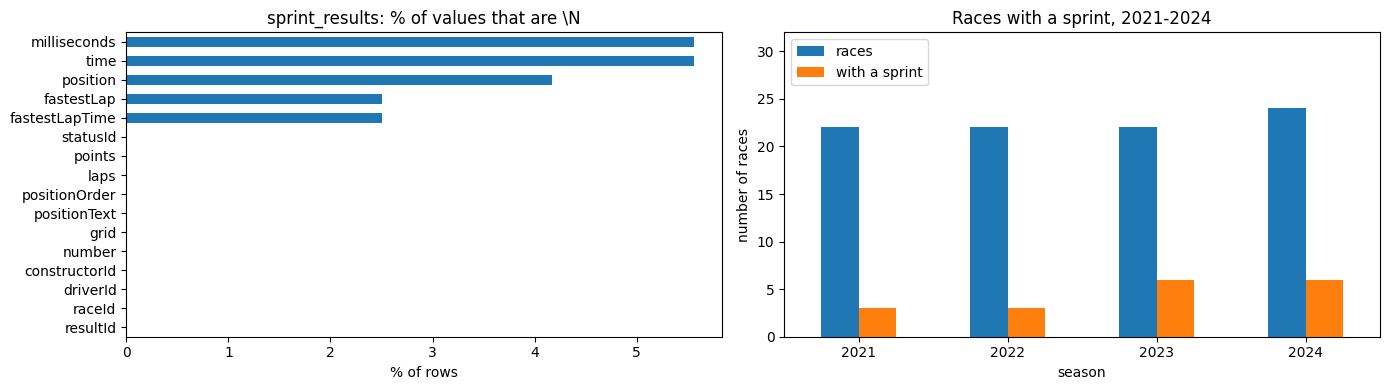

In [11]:
# ==========================================================================================
# B1 · sprint_results: profile, keys, grain, coverage, and why values are missing
# ==========================================================================================

# Why: sprint_results looks like a small copy of results, but only for the short Saturday "sprint" races (2021 onward).
# Before deciding anything about it, we check what one row means, which races it covers, and why some cells are empty.
sp = as_num(raw["sprint_results"])     # exploring copy of sprint_results (raw stays untouched)
sp["year"] = year_of(sp)               # the season of each sprint

# ---------- 1. Profile card and keys ----------
display(profile("sprint_results"))
print(pk_check("sprint_results", ["resultId"]))                  # the table's own id
print(pk_check("sprint_results", ["raceId", "driverId"]))        # one row per driver per sprint? (the grain we need)
print("Columns that results has but sprint_results does not:", sorted(set(raw["results"].columns) - set(raw["sprint_results"].columns)))

# ---------- 2. Grain: what is one row, and is every sprint complete? ----------
print("Rows:", len(sp), "| different sprints:", sp.raceId.nunique(), "| drivers:", sp.driverId.nunique(),
      "| constructors:", sp.constructorId.nunique())
print("Drivers per sprint:", sp.groupby("raceId").size().value_counts().to_dict())          # {20: 18} means every sprint has 20 rows
order = sp.groupby("raceId").positionOrder.agg(["min", "max", "nunique", "size"])             # finishing order must run 1..20 with no gaps
print("Finishing order is exactly 1..n in every sprint:", bool(((order["min"] == 1) & (order["max"] == order["size"]) & (order["nunique"] == order["size"])).all()))

# ---------- 3. Coverage: which races had a sprint? ----------
sprint_weekends = sp.groupby("year").raceId.nunique()                                         # sprints per season
races_per_year = races[races.year >= 2021].groupby("year").size()                              # all races per season
coverage = pd.DataFrame({"races": races_per_year, "with a sprint": sprint_weekends}).fillna(0).astype(int)
coverage["share %"] = (coverage["with a sprint"] / coverage["races"] * 100).round(0)
display(coverage)
print("Share of ALL", len(races), "races that have a sprint:", round(sp.raceId.nunique() / len(races) * 100, 1), "%")

# ---------- 4. Does the sprint table agree with races and results? ----------
sprint_dates = pd.to_datetime(races.sprint_date)                                              # text -> date (copy)
has_sprint = races[sprint_dates.notna()]
print("Same sprints as the races table says:", set(sp.raceId) == set(has_sprint.raceId))
print("Days between the sprint and the main race:", (has_sprint.date - sprint_dates[sprint_dates.notna()]).dt.days.value_counts().to_dict())
race_rows = results[["raceId", "driverId", "constructorId"]].astype(int)                      # the main race entries
check = sp[["raceId", "driverId", "constructorId"]].merge(race_rows, on=["raceId", "driverId"], how="left",
                                                          suffixes=("", "_race"), indicator=True)
print("Sprinters with no row in the main race:", int((check._merge != "both").sum()),
      "| racing for a different team in the main race:", int((check.constructorId != check.constructorId_race).sum()))

# ---------- 5. Why are some cells empty? ----------
status_name = as_num(raw["status"]).set_index("statusId").status
sp["status"] = sp.statusId.map(status_name)                                                   # why the sprint ended for this driver
missing = pd.DataFrame({col: {"missing": int(sp[col].isna().sum()),
                              "reasons": sp[sp[col].isna()].status.value_counts().to_dict()}
                        for col in ["position", "time", "milliseconds", "fastestLap", "fastestLapTime"]}).T
pd.set_option("display.max_colwidth", 200)                                                    # show the whole list of reasons
display(missing)
print("Rows with no finishing position:", int(sp.position.isna().sum()),
      "| of which finished the sprint:", int((sp.position.isna() & (sp.status == "Finished")).sum()))
print("Rows with a position but no race time (classified, did not finish):", int((sp.position.notna() & sp.time.isna()).sum()))
print("position equals positionOrder whenever it exists:", bool((sp.position.dropna() == sp.positionOrder[sp.position.notna()]).all()))

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
profile("sprint_results")["sentinel_%"].sort_values().plot.barh(ax=ax[0], title="sprint_results: % of values that are \\N")
ax[0].set_xlabel("% of rows")
coverage[["races", "with a sprint"]].plot.bar(ax=ax[1], rot=0, title="Races with a sprint, 2021-2024")
ax[1].set_xlabel("season")
ax[1].set_ylabel("number of races")
ax[1].set_ylim(0, 32)                                  # leave room above the bars for the legend
ax[1].legend(loc="upper left")
plt.tight_layout()
plt.savefig("figures/B1_sprint_results.png", dpi=120, bbox_inches="tight")
plt.show()

**B1 result:**
- **The grain is right:** 360 rows (18 sprints, 31 drivers, 12 constructors). `resultId` is unique and so is `(raceId, driverId)`; **every sprint has exactly 20 rows** and its finishing order runs 1 to 20 with no gaps.
- **Coverage is tiny:** sprints exist only from 2021: 3 in 2021, 3 in 2022, 6 in 2023 and 6 in 2024 (14% to 27% of those seasons' races), which is only **1.6% of all 1,125 races**. Any feature built from the sprint would be empty for about 98% of rows.
- **It agrees with the other tables:** the same 18 races are flagged in `races.sprint_date`, the sprint is always exactly **1 day before** the main race (Saturday), every sprinter also has a row in the main race, and drives for the same team in both.
- **Empty cells have a reason, not chance.** `position` is empty in 15 rows (4.2%), all of them cars that did not finish (Retired, Accident, Collision damage, ...); `time` and `milliseconds` in 20 (5.6%), the same 15 plus 5 classified cars that did not finish and so have no time; `fastestLap` and `fastestLapTime` in 9 (2.5%), cars that stopped before setting one. A car that finished never has a missing value.
- Differences from `results`: no `rank` and no `fastestLapSpeed` columns. `position` always equals `positionOrder` when it exists.

**Decisions for cleaning:** treat `\N` as missing and read `milliseconds` as numbers, as for `results`; do **not** fill the empty cells (they mean "did not finish"); because the table covers 1.6% of races, any sprint feature needs a `has_sprint` flag and would be missing elsewhere. Whether the sprint may be used at all is decided in B2.

## B2 · sprint_results: points rules, odd values, the time column, and the leakage question

- **What:** work out the sprint points rules, look at the 11 rows with `grid = 0`, turn the `time` text into numbers and check it against `milliseconds`, and measure how the sprint finishing order relates to qualifying and to the Sunday starting grid.
- **Why:** the sprint runs on Saturday, before the Sunday race, so in *time* it is allowed as a feature. But "allowed" is not "useful": if it only repeats information we already have (the Sunday grid), or exists for 1.6% of races, it is not worth using. We also need the sprint points rules, because sprint points feed the standings and constructor results later.

positionOrder,1,2,3,4,5,6,7,8,9
year,,,,,,,,,
2021,3,2,1,0,0,0,0,0,0
2022,8,7,6,5,4,3,2,1,0
2023,8,7,6,5,4,3,2,1,0
2024,8,7,6,5,4,3,2,1,0


Same points for the same position in every sprint of a season: True
Points given outside the scoring places: 0 | scoring places without points: 0
Points handed out in one sprint: {2021: 6, 2022: 36, 2023: 36, 2024: 36}
Rows with grid 0: 11 in 7 sprints | by season: {2022: 1, 2023: 3, 2024: 7} | how they ended: {'Finished': 9, 'Retired': 1, 'Accident': 1}
Highest grid slot used in each sprint: [17, 18, 19, 20]
One winner time per sprint: True | rows where the time text agrees with the milliseconds column: 340 of 340
fastestLapTime always looks like m:ss.mmm: True


,sprint finish vs Sunday grid,qualifying vs Sunday grid,sprint finish vs qualifying
2021,0.89,0.83,0.96
2022,0.99,0.72,0.72
2023,0.62,0.99,0.63
2024,0.54,0.96,0.58


Sprint top-3 who also finished on the podium on Sunday: 33 of 54
Sunday grid top-3 who finished on the podium (same weekends): 30 of 53


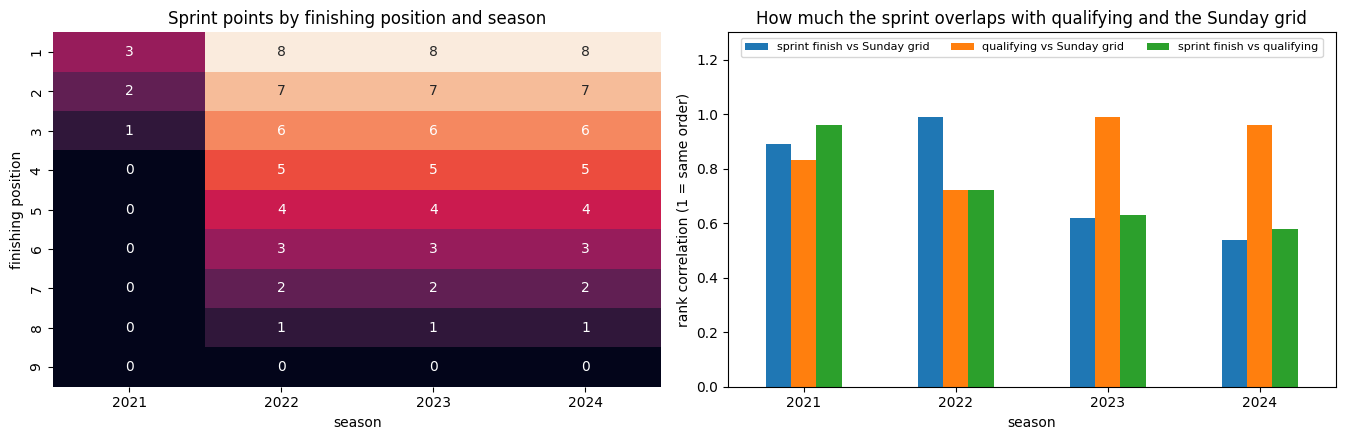

In [12]:
# ==========================================================================================
# B2 · sprint_results: points rules, odd values, the time column, and may a sprint result be a feature?
# ==========================================================================================

# Why: before deciding whether the sprint can help predict Sunday's podium, we must understand what its columns mean
# (points, grid 0, time) and how the sprint result relates to the Sunday starting grid.
sp = as_num(raw["sprint_results"])     # exploring copy of sprint_results (raw stays untouched)
sp["year"] = year_of(sp)
status_name = as_num(raw["status"]).set_index("statusId").status
sp["status"] = sp.statusId.map(status_name)

# ---------- 1. The points rules ----------
# Points for each finishing position, per season. The scoring changed after the first season.
points_table = sp[sp.positionOrder <= 9].pivot_table(index="year", columns="positionOrder", values="points", aggfunc="max").astype(int)
display(points_table)
print("Same points for the same position in every sprint of a season:", bool((sp.groupby(["year", "positionOrder"]).points.nunique() == 1).all()))
scoring_places = np.where(sp.year == 2021, 3, 8)                          # 2021: top 3 scored; 2022 onward: top 8 scored
print("Points given outside the scoring places:", int(((sp.points > 0) & (sp.positionOrder > scoring_places)).sum()),
      "| scoring places without points:", int(((sp.points == 0) & (sp.positionOrder <= scoring_places)).sum()))
print("Points handed out in one sprint:", sp.groupby(["year", "raceId"]).points.sum().groupby("year").first().to_dict())

# ---------- 2. grid = 0 ----------
g0 = sp[sp.grid == 0]
print("Rows with grid 0:", len(g0), "in", g0.raceId.nunique(), "sprints | by season:", g0.year.value_counts().sort_index().to_dict(),
      "| how they ended:", g0.status.value_counts().to_dict())
print("Highest grid slot used in each sprint:", sorted(sp.groupby("raceId").grid.max().unique().tolist()))

# ---------- 3. The time column: text that must be turned into numbers ----------
def time_text_to_ms(t):
    # "25:38.426" (the winner, minutes:seconds) or "+1.430" / "+1:05.234" (gap to the winner)  ->  milliseconds
    t = t.lstrip("+")
    parts = t.split(":")
    seconds = float(parts[-1])
    minutes = float(parts[-2]) if len(parts) > 1 else 0.0
    return round((minutes * 60 + seconds) * 1000)

d = sp.dropna(subset=["time"]).copy()                                     # only drivers who have a time
d["is_gap"] = d.time.str.startswith("+")                                  # True for a gap, False for the winner's total time
d["text_ms"] = d.time.map(time_text_to_ms)
winner_ms = d[~d.is_gap].set_index("raceId").text_ms                      # the winner's time in each sprint
d["expected_ms"] = np.where(d.is_gap, d.raceId.map(winner_ms) + d.text_ms, d.text_ms)   # a gap is added to the winner's time
print("One winner time per sprint:", bool((d[~d.is_gap].groupby("raceId").size() == 1).all()),
      "| rows where the time text agrees with the milliseconds column:", int((d.expected_ms == d.milliseconds).sum()), "of", len(d))
print("fastestLapTime always looks like m:ss.mmm:", bool(sp.fastestLapTime.dropna().str.match(r"^\d:\d{2}\.\d{3}$").all()))

# ---------- 4. May the sprint result be a feature for Sunday's podium? ----------
# The sprint is on Saturday, before the Sunday race, so in TIME it is allowed. But does it add anything?
race_rows = results[["raceId", "driverId", "grid", "positionOrder"]].astype(int)           # the Sunday race
# qualifying.csv is profiled by our teammates, so P0 did not load it. We read it here (read-only) only for this comparison.
quali = (as_num(pd.read_csv(f"{DATA_DIR}/qualifying.csv", dtype=str, keep_default_na=False))
         [["raceId", "driverId", "position"]].rename(columns={"position": "quali_pos"}))
m = (sp[["raceId", "driverId", "year", "positionOrder"]]
     .merge(race_rows, on=["raceId", "driverId"], suffixes=("_sprint", "_race"))           # sprint and Sunday race side by side
     .merge(quali, on=["raceId", "driverId"], how="left"))
m = m[m.grid > 0]                                                                          # drop pit-lane starters (grid 0) from the comparison
def rank_corr(a, b):
    return a.rank().corr(b.rank())                                                         # Spearman: do two orderings agree? (1 = identical, 0 = unrelated)
by_year = pd.DataFrame({
    "sprint finish vs Sunday grid": {y: rank_corr(g.positionOrder_sprint, g.grid) for y, g in m.groupby("year")},
    "qualifying vs Sunday grid": {y: rank_corr(g.quali_pos, g.grid) for y, g in m.groupby("year")},
    "sprint finish vs qualifying": {y: rank_corr(g.positionOrder_sprint, g.quali_pos) for y, g in m.groupby("year")}}).round(2)
display(by_year)
top3_sprint = m[m.positionOrder_sprint <= 3]
print("Sprint top-3 who also finished on the podium on Sunday:", int((top3_sprint.positionOrder_race <= 3).sum()), "of", len(top3_sprint))
top3_grid = m[m.grid <= 3]
print("Sunday grid top-3 who finished on the podium (same weekends):", int((top3_grid.positionOrder_race <= 3).sum()), "of", len(top3_grid))

# ---------- 5. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(points_table.T, annot=True, cbar=False, ax=ax[0])
ax[0].set_title("Sprint points by finishing position and season")
ax[0].set_xlabel("season")
ax[0].set_ylabel("finishing position")
by_year.plot.bar(ax=ax[1], rot=0, title="How much the sprint overlaps with qualifying and the Sunday grid")
ax[1].set_xlabel("season")
ax[1].set_ylabel("rank correlation (1 = same order)")
ax[1].set_ylim(0, 1.3)                                  # leave room above the bars for the legend
ax[1].legend(loc="upper center", ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig("figures/B2_sprint_points_and_grid.png", dpi=120, bbox_inches="tight")
plt.show()

**B2 result:**
- **Points rules are simple and consistent.** 2021: only the top 3 scored (3, 2, 1). From 2022: the top 8 scored (8 down to 1). The same position always gets the same points within a season, and no points are given outside the scoring places. A sprint hands out 6 points in 2021 and 36 from 2022.
- **`grid = 0` means a pit-lane start.** 11 rows in 7 sprints (1 in 2022, 3 in 2023, 7 in 2024); 9 of those cars finished.
- **`time` is text but safe to trust.** Winners have a total time (`25:38.426`), everyone else a gap (`+1.430`). Rebuilt into milliseconds, it matches the `milliseconds` column in **all 340 of 340** rows, with exactly one winner per sprint. So we use `milliseconds`.
- **The sprint overlaps heavily with the grid, and the overlap changes with the rules.** Comparing orders (1 = identical): in **2021 and 2022 the sprint finishing order is almost the Sunday grid (0.89 and 0.99)**, because the sprint decided the Sunday grid. From **2023 the Sunday grid is qualifying (0.99 and 0.96)** and the sprint overlaps much less with it (0.62 and 0.54).
- **A weak case for using it:** the sprint top 3 reached the Sunday podium 33 times out of 54, about the same as the Sunday grid top 3 on the same weekends (30 of 53).

**Decisions for features and leakage:** a sprint result is known before the Sunday race, so it is *allowed in time*, but we propose **not to use it in the main model**: it covers 1.6% of races (B1), in 2021 to 2022 it largely repeats the Sunday grid, and it adds no extra podium signal beyond the grid. If the team wants it, it could enter only as an optional experiment with a `has_sprint` flag. Either way, write the choice and this evidence in `decisions.md`. Sprint points are handled in B4 and B7, where they feed driver standings and constructor results.

## B3 · driver_standings: profile, keys, what one row means, odd values, and which drivers are missing

- **What:** profile `driver_standings`, check its keys and links, work out what one row means, look at `position`, `positionText`, decimal `points` and `wins`, and find which race starters have no standings row.
- **Why:** this is the championship table. It looks like a ready-made feature ("how many points does the driver have?"), but it is only safe if we know exactly what a row contains, when it is created, and where rows are missing. B4 then proves *when* in the weekend the numbers are fixed.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
driverStandingsId,0,0.0,0,34863,100.0,1
raceId,0,0.0,0,1125,100.0,18
driverId,0,0.0,0,854,100.0,1
points,0,0.0,0,442,100.0,10
position,0,0.0,0,108,100.0,1
positionText,0,0.0,0,109,100.0,1
wins,0,0.0,0,20,100.0,1


{'table': 'driver_standings', 'key': 'driverStandingsId', 'rows': 34863, 'duplicates': 0, 'null_or_sentinel': 0}
{'table': 'driver_standings', 'key': 'raceId+driverId', 'rows': 34863, 'duplicates': 0, 'null_or_sentinel': 0}
driverId values that are not in drivers: 0 | raceId values that are not in races: 0 | races with no standings at all: 0 of 1125


,standings rows,race starters
decade,,
1950,71,22
1960,33,20
1970,37,26
1980,32,28
1990,26,26
2000,22,20
2010,22,22
2020,21,20


Standings rows for a driver who did NOT start that race: 8664 | race starters with NO standings row: 469
position is exactly 1..n in every race: 1125 of 1125 races
Rows where positionText is not the same number as position: 1


,year,round,name,driverId,points,position,positionText,wins
4375,1997,17,European Grand Prix,30,78.0,26,D,5


,round,points,position,positionText
4349,16,78.0,1,1
4375,17,78.0,26,D


Neighbours with equal points: 4116 | the higher-placed one has at least as many wins: 4116 | strictly more wins: 282
points range: 0.0 to 575.0 | wins range: 0 to 19 | rows with a decimal in points: 276


,year,round,name,drivers with a decimal gain
0,1952,8,Italian Grand Prix,1
1,1953,2,Indianapolis 500,2
2,1953,6,British Grand Prix,2
3,1953,8,Swiss Grand Prix,2
4,1953,9,Italian Grand Prix,1
5,1954,2,Indianapolis 500,2
6,1954,3,Belgian Grand Prix,2
7,1954,5,British Grand Prix,4
8,1954,6,German Grand Prix,1
9,1954,7,Swiss Grand Prix,1


A driver's points ever go DOWN during a season: 0 | wins ever go down: 0 | a driver skips a round and comes back: 0
Race starts with no standings row, by decade (%): {1950: 0.1, 1960: 0.1, 1970: 0.1, 1980: 0.2, 1990: 7.0, 2000: 4.1, 2010: 0.1, 2020: 0.0}
Race starts that scored points but have NO standings row: 0 of 8210
Race starts that are round 1 (no earlier standings in the same season): 1738 of 26759 | round-1 races: 75 of 1125


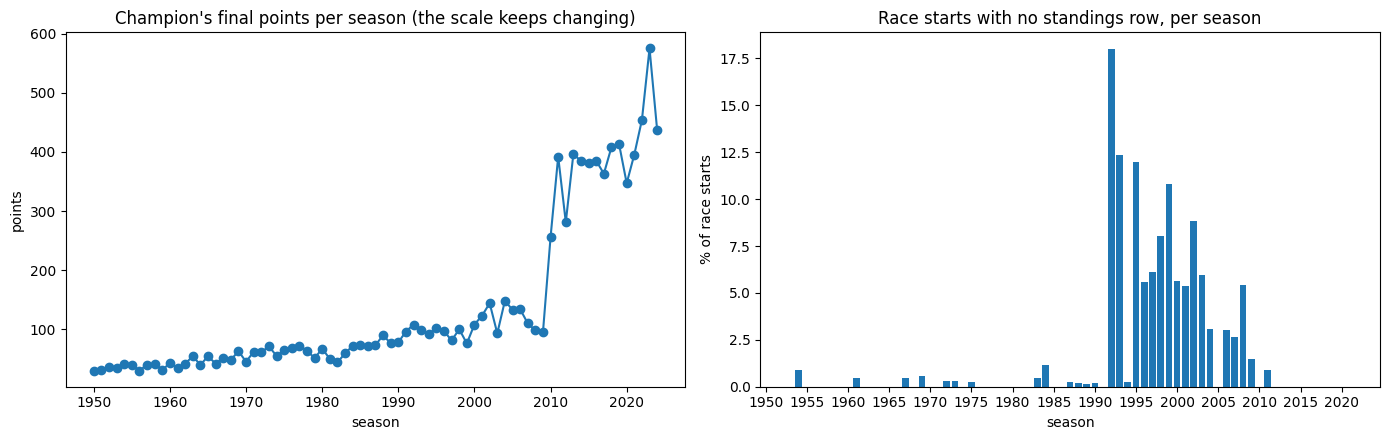

In [13]:
# ==========================================================================================
# B3 · driver_standings: profile, keys, what one row means, odd values, and which drivers are missing
# ==========================================================================================

# Why: driver_standings is the championship table AFTER each race (to be proven in B4). Before we think about using it,
# we must know what one row means, whether every driver has a row, and which values look strange.
ds = as_num(raw["driver_standings"])     # exploring copy of driver_standings (raw stays untouched)
ds["year"] = year_of(ds)                 # the season of each row
ds = ds.merge(races[["raceId", "round", "name"]], on="raceId")   # add the round number and race name (copy)
ds = ds.sort_values(["year", "driverId", "round"])               # one driver's season in race order

# ---------- 1. Profile card, keys and links ----------
display(profile("driver_standings"))
print(pk_check("driver_standings", ["driverStandingsId"]))        # the table's own id
print(pk_check("driver_standings", ["raceId", "driverId"]))       # one row per driver per race? (the grain we need)
drivers_ids = set(raw["drivers"].driverId.astype(int))
print("driverId values that are not in drivers:", len(set(ds.driverId) - drivers_ids),
      "| raceId values that are not in races:", len(set(ds.raceId) - set(races.raceId)),
      "| races with no standings at all:", len(set(races.raceId) - set(ds.raceId)), "of", len(races))

# ---------- 2. Grain: a driver's row is a running total, not "who raced today" ----------
race_rows = results[["raceId", "driverId"]].astype(int)                                  # who actually started each race
rows_per_race = pd.DataFrame({"standings rows": ds.groupby("raceId").size(), "race starters": race_rows.groupby("raceId").size()})
rows_per_race["decade"] = rows_per_race.index.map(YEAR) // 10 * 10
display(rows_per_race.groupby("decade").median().astype(int))                            # typical rows per race, by decade
both = ds[["raceId", "driverId"]].merge(race_rows.assign(started=1), on=["raceId", "driverId"], how="outer", indicator=True)
print("Standings rows for a driver who did NOT start that race:", int((both._merge == "left_only").sum()),
      "| race starters with NO standings row:", int((both._merge == "right_only").sum()))

# ---------- 3. position and positionText ----------
order = ds.groupby("raceId").position.agg(["min", "max", "nunique", "size"])             # positions must run 1..n with no repeats
print("position is exactly 1..n in every race:", int(((order["min"] == 1) & (order["max"] == order["size"]) & (order["nunique"] == order["size"])).sum()),
      "of", len(order), "races")
as_number = pd.to_numeric(ds.positionText, errors="coerce")                              # text -> number, text like "D" becomes NaN
odd = ds[as_number != ds.position]
print("Rows where positionText is not the same number as position:", len(odd))
display(odd[["year", "round", "name", "driverId", "points", "position", "positionText", "wins"]])
last_two = ds[(ds.driverId == odd.driverId.iloc[0]) & (ds.year == odd.year.iloc[0])].tail(2)   # the same driver one race earlier
display(last_two[["round", "points", "position", "positionText"]])
tie = ds[ds.points > 0].sort_values(["raceId", "position"])                              # who is placed above whom when points are equal?
tie["next_points"] = tie.groupby("raceId").points.shift(-1)
tie["next_wins"] = tie.groupby("raceId").wins.shift(-1)
tied = tie[tie.points == tie.next_points]
print("Neighbours with equal points:", len(tied), "| the higher-placed one has at least as many wins:", int((tied.wins >= tied.next_wins).sum()),
      "| strictly more wins:", int((tied.wins > tied.next_wins).sum()))

# ---------- 4. points and wins: decimals and the running-total check ----------
print("points range:", ds.points.min(), "to", ds.points.max(), "| wins range:", ds.wins.min(), "to", ds.wins.max(),
      "| rows with a decimal in points:", int((ds.points % 1 != 0).sum()))
ds["gain"] = ds.groupby(["year", "driverId"]).points.diff().fillna(ds.points)           # points added by this one race
fraction_races = ds[ds.gain % 1 != 0].groupby(["year", "round", "name"]).size().rename("drivers with a decimal gain")
display(fraction_races.reset_index())                                                    # the races where a decimal was added
ds["wins_gain"] = ds.groupby(["year", "driverId"]).wins.diff().fillna(ds.wins)
ds["round_jump"] = ds.groupby(["year", "driverId"])["round"].diff()                      # 1 = the driver is in every round
print("A driver's points ever go DOWN during a season:", int((ds.gain < 0).sum()),
      "| wins ever go down:", int((ds.wins_gain < 0).sum()),
      "| a driver skips a round and comes back:", int((ds.round_jump > 1).sum()))

# ---------- 5. Which drivers are missing? (the same idea as the empty cells of B1) ----------
res = race_rows.copy()
res["year"] = res.raceId.map(YEAR)
res = res.merge(races[["raceId", "round"]], on="raceId")
res = res.merge(ds[["raceId", "driverId"]].assign(has_row=1), on=["raceId", "driverId"], how="left")
res["has_row"] = res.has_row.fillna(0).astype(bool)
missing_by_year = (1 - res.groupby("year").has_row.mean()) * 100                         # % of race starts with no standings row
by_decade = (1 - res.groupby(res.year // 10 * 10).has_row.mean()) * 100
print("Race starts with no standings row, by decade (%):", by_decade.round(1).to_dict())
scored = results[["raceId", "driverId", "points"]].astype({"raceId": int, "driverId": int, "points": float})
scored = scored[scored.points > 0].merge(res[["raceId", "driverId", "has_row"]], on=["raceId", "driverId"])
print("Race starts that scored points but have NO standings row:", int((~scored.has_row).sum()), "of", len(scored))
print("Race starts that are round 1 (no earlier standings in the same season):", int((res["round"] == 1).sum()), "of", len(res),
      "| round-1 races:", int((races["round"] == 1).sum()), "of", len(races))

# ---------- 6. Plots (saved for the report) ----------
last_round = races.sort_values("round").groupby("year").raceId.last()                   # the last race of each season
champion = ds[ds.raceId.isin(last_round) & (ds.position == 1)].set_index("year").points  # the champion's final points
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
champion.plot(ax=ax[0], marker="o", title="Champion's final points per season (the scale keeps changing)")
ax[0].set_xlabel("season")
ax[0].set_ylabel("points")
missing_by_year.plot.bar(ax=ax[1], width=0.8, title="Race starts with no standings row, per season")
ax[1].set_xlabel("season")
ax[1].set_ylabel("% of race starts")
ax[1].set_xticks(range(0, len(missing_by_year), 5))
ax[1].set_xticklabels(missing_by_year.index[::5], rotation=0)
plt.tight_layout()
plt.savefig("figures/B3_driver_standings.png", dpi=120, bbox_inches="tight")
plt.show()

**B3 result:**
- **Clean on the surface.** 34,863 rows x 7 columns, no `\N`, no empty cells. `driverStandingsId` and (`raceId`, `driverId`) are both unique, every `driverId` exists in `drivers`, every `raceId` exists in `races`, and all 1,125 races have standings.
- **A row is a running total, not "who raced today".** There are many more standings rows than starters in the early years (1950s median: 71 rows for 22 starters; 2020s: 21 rows for 20 starters). 8,664 rows belong to a driver who did not start that race but had already raced earlier that season. Within a season points never go down, wins never go down, and no driver skips a round.
- **`position` is clean.** It runs exactly 1..n in all 1,125 races, with no ties. When two drivers have equal points, the higher-placed one never has fewer wins (4,116 of 4,116 pairs; strictly more in 282). Where wins are equal too, a further tie-break was used that the table does not show.
- **One odd row:** `positionText` is `D` once: Michael Schumacher, 1997 European GP (round 17). One round earlier he was 1st with 78 points; in the last round he still shows 78 points but position 26 (last), because he was disqualified from that championship. It is the only row where `position` and `positionText` differ.
- **Decimal points in 276 rows**, caused by only 22 races: shared drives in the 1950s (points split between drivers) and half-points races (1975 Spain and Austria, 1984 Monaco, 1991 Australia, 2009 Malaysia, 2021 Belgium). Points run 0 to 575 (Verstappen 2023) and wins 0 to 19. Points are decimals, not integers.
- **Some race starters have no standings row: 469 of 26,759.** 447 of them are in the 1990s and 2000s (1990s 7.0% of starts, 2000s 4.1%, every other decade 0.2% or less; peak 1992 with 18%). **Every race start that scored points has a row (0 of 8,210 missing)**, so a missing row can only mean "no points yet".
- **Raw points are not comparable across seasons.** The champion's final total goes from 30 (1950) to about 95 (2009), then jumps to 256 (2010, new points system) and reaches 575 (2023, 22 races).

**Decisions for features and leakage:**
1. The row after race R already contains race R's result, so to predict race R we may only use the standings after round R-1 (B4 proves this). Round 1 of each season (75 races, 6.5% of starts) has no earlier standings in the same season: use a documented start value plus a flag.
2. A missing row means 0 points and 0 wins (safe, proven above). Do **not** fill `position` with 0; treat it as "not ranked yet".
3. Do not use raw points as a model input across seasons. Use scale-free versions such as the gap to the leader, the share of the leader's points, and the rank.
4. Keep `position` numeric and ignore `positionText`. The 1997 `D` row is a single row at the end of a season, so it can only matter if a feature reads the final round. Do not read championship rank from it.

## B4 · driver_standings: is it written AFTER the race? Where does it disagree with the results? How much would it leak?

- **What:** (1) check how many points each standings row *adds* at its race and compare with what the driver scored that weekend (Sunday race plus sprint); (2) find where the standings disagree with the points actually scored; (3) build the safe "standings before the race" by shifting one round; (4) measure how much better the standings look if we wrongly use the version that already contains the race.
- **Why:** this is the key leakage question for the standings. If a row already contains its own race, using it to predict that race hands the model the answer. We prove it with numbers, then build the version we are allowed to use.

Standings rows: 34954 | points added = Sunday race points: 34706 | points added = Sunday + sprint points: 34835
Rows of drivers who did not start that race that add 0 points: 8664 of 8664
Agreement with the weekend's points, by decade (%): {1950: 98.7, 1960: 99.5, 1970: 99.8, 1980: 99.7, 1990: 100.0, 2000: 100.0, 2010: 100.0, 2020: 100.0}
Seasons 2021-2024, Sunday points only: 93.2 % | Sunday + sprint: 100.0 %  | rows with sprint points: 129 | agree with Sunday only: 0 | agree with Sunday + sprint: 129
Wins added = won today: 99.99 % | rows that disagree: 5
Races with two drivers on positionOrder 1: ['1957 round 5', '1956 round 1', '1951 round 4']
Races where positionOrder <= 3 gives MORE than 3 podium rows: 18 of 1125 | seasons: [1950, 1951, 1953, 1954, 1955, 1956, 1957, 1960] | most rows in one race: 7
Standings = points scored so far: 34800 of 34954 | standings lower: 128 | standings higher: 26
Driver-seasons: 3192 | final standings LOWER than points scored: 50 | HIGHER: 1
Seasons w

,year,driverId,round,standings points,scored_so_far,gap
18834,1988,102,14,79.0,79.0,0.0
18835,1988,102,15,87.0,88.0,-1.0
18836,1988,102,16,90.0,94.0,-4.0


raceId order equals date order: False | raceIds whose date is earlier than the previous raceId: 61 | round order equals date order inside every season: True
Race starts after round 1: 25021 | standings-before equals the points scored in earlier races: 99.7 % | standings-after equals before + scored today: 99.56 %
Race starts in round 1 (no standings before; start value 0): 1738 of 26759 | standings after round 1 = points scored that weekend: 99.54 %
Race starts whose driver has no standings row yet before the race (after round 1): 1969
Races skipped because nobody had points before the race: 11 | {'Indianapolis 500': 11} | seasons: [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960]


,before the race,after the race (leak)
decade,,
1950,0.32,0.52
1960,0.33,0.53
1970,0.36,0.49
1980,0.40,0.51
1990,0.42,0.51
2000,0.48,0.57
2010,0.61,0.67
2020,0.60,0.66


Average over all races: {'before the race': 0.46, 'after the race (leak)': 0.56}
The race winner leads the standings AFTER the race: 48.4 % of 1125 races | led it BEFORE the race: 32.8 % of 1050 races (round 2 onward)


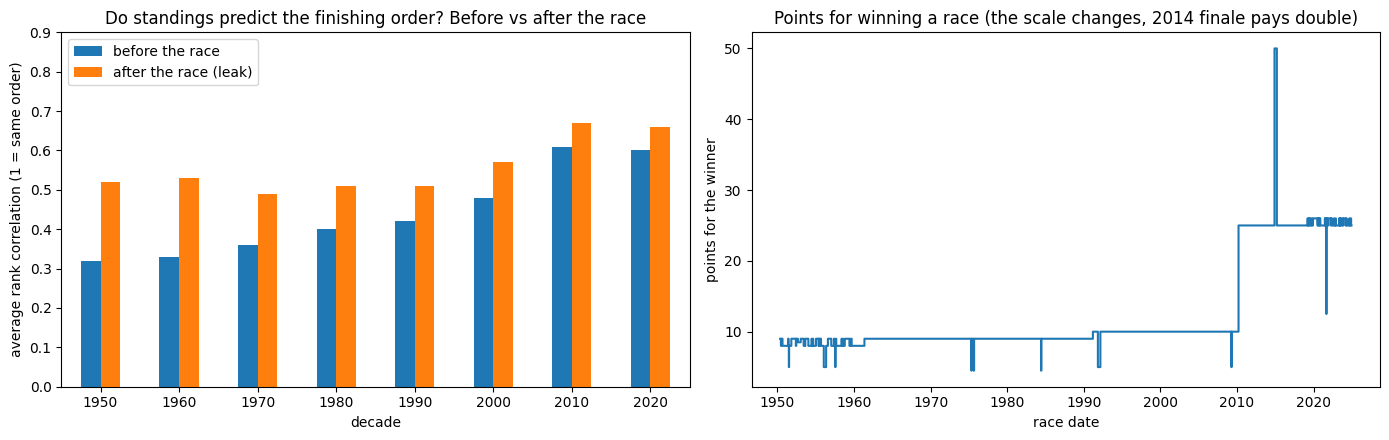

In [14]:
# ==========================================================================================
# B4 · driver_standings: is it written AFTER the race? Where does it disagree with the results? How much would it leak?
# ==========================================================================================

# Why: a standings table is tempting as a feature ("points so far"), but it is only legal if we use the standings from BEFORE
# the race. So we prove when each row is written, measure where it disagrees with the race points, and then build the safe version.
ds = as_num(raw["driver_standings"])     # exploring copy of driver_standings (raw stays untouched)
ds["year"] = year_of(ds)
ds = ds.merge(races[["raceId", "round"]], on="raceId")
ds = ds.sort_values(["year", "driverId", "round"])               # one driver's season in race order

# What each driver scored in each race: the Sunday race points plus the Saturday sprint points of the same weekend (2021 onward)
res = results[["raceId", "driverId", "positionOrder", "points"]].astype({"raceId": int, "driverId": int, "positionOrder": int, "points": float})
res = res.rename(columns={"points": "race_points"})
sprint = as_num(raw["sprint_results"])[["raceId", "driverId", "points"]].rename(columns={"points": "sprint_points"})
res = res.merge(sprint, on=["raceId", "driverId"], how="left")
res["sprint_points"] = res.sprint_points.fillna(0)               # no sprint weekend (or no sprint points) = 0
res["scored"] = res.race_points + res.sprint_points
res["year"] = res.raceId.map(YEAR)
res = res.merge(races[["raceId", "round"]], on="raceId")

# ---------- 1. How many points did each standings row ADD at this race? ----------
# If the row is written after the race, the points it adds must equal what the driver scored that weekend.
ds["added"] = ds.groupby(["year", "driverId"]).points.diff().fillna(ds.points)           # change since the driver's previous row
ds["wins_added"] = ds.groupby(["year", "driverId"]).wins.diff().fillna(ds.wins)
m = ds.merge(res[["raceId", "driverId", "race_points", "sprint_points", "scored", "positionOrder"]], on=["raceId", "driverId"], how="left")
m["started"] = m.positionOrder.notna()                           # False = a driver carried forward who did not start this race
m[["race_points", "sprint_points", "scored"]] = m[["race_points", "sprint_points", "scored"]].fillna(0)
m["same_as_race"] = (m.added - m.race_points).abs() < 1e-6
m["same_as_weekend"] = (m.added - m.scored).abs() < 1e-6
print("Standings rows:", len(m), "| points added = Sunday race points:", int(m.same_as_race.sum()),
      "| points added = Sunday + sprint points:", int(m.same_as_weekend.sum()))
print("Rows of drivers who did not start that race that add 0 points:", int(((~m.started) & (m.added == 0)).sum()), "of", int((~m.started).sum()))
print("Agreement with the weekend's points, by decade (%):", m.groupby(m.year // 10 * 10).same_as_weekend.mean().mul(100).round(1).to_dict())
modern = m[m.year >= 2021]                                       # the seasons that have sprints
scorers = m[m.sprint_points > 0]                                 # rows of drivers who scored in a sprint
print("Seasons 2021-2024, Sunday points only:", round(modern.same_as_race.mean() * 100, 1), "% | Sunday + sprint:", round(modern.same_as_weekend.mean() * 100, 1),
      "%  | rows with sprint points:", len(scorers), "| agree with Sunday only:", int(scorers.same_as_race.sum()), "| agree with Sunday + sprint:", int(scorers.same_as_weekend.sum()))
won = (m.positionOrder == 1).astype(int)                         # 1 if the driver won this race
print("Wins added = won today:", round((m.wins_added == won).mean() * 100, 2), "% | rows that disagree:", int((m.wins_added != won).sum()))
two_winners = res[res.positionOrder == 1].groupby("raceId").size()
print("Races with two drivers on positionOrder 1:", two_winners[two_winners > 1].index.map(lambda r: f"{YEAR[r]} round {int(races.set_index('raceId')['round'][r])}").tolist())
podium_rows = res[res.positionOrder <= 3].groupby("raceId").size()                       # the target uses positionOrder <= 3, so how many rows is that per race?
too_many = podium_rows[podium_rows > 3]
print("Races where positionOrder <= 3 gives MORE than 3 podium rows:", len(too_many), "of", len(podium_rows),
      "| seasons:", sorted(too_many.index.map(YEAR).unique().tolist()), "| most rows in one race:", int(podium_rows.max()))

# ---------- 2. Where do the standings disagree with the points scored? ----------
res = res.sort_values(["year", "driverId", "round"])
res["scored_so_far"] = res.groupby(["year", "driverId"]).scored.cumsum()                  # running total of points actually scored
cmp = ds[["year", "driverId", "round", "points"]].merge(res[["year", "driverId", "round", "scored_so_far"]], on=["year", "driverId", "round"], how="left")
cmp["scored_so_far"] = cmp.groupby(["year", "driverId"]).scored_so_far.ffill().fillna(0)  # a round the driver skipped keeps the last total
cmp["gap"] = cmp.points - cmp.scored_so_far                      # negative: the table shows FEWER points than the driver scored
print("Standings = points scored so far:", int((cmp.gap.abs() < 1e-6).sum()), "of", len(cmp),
      "| standings lower:", int((cmp.gap < -1e-6).sum()), "| standings higher:", int((cmp.gap > 1e-6).sum()))
final = cmp.sort_values("round").groupby(["year", "driverId"]).tail(1)                  # each driver's last row of the season
low, high = final[final.gap < -1e-6], final[final.gap > 1e-6]
print("Driver-seasons:", len(final), "| final standings LOWER than points scored:", len(low), "| HIGHER:", len(high))
print("Seasons with a lower final total:", sorted(low.year.unique().tolist()))
print("Largest difference (points):", low.gap.min())
senna = int(raw["drivers"].loc[(raw["drivers"].forename == "Ayrton") & (raw["drivers"].surname == "Senna"), "driverId"].iloc[0])   # a famous example: 1988
display(cmp[(cmp.year == 1988) & (cmp.driverId == senna)].tail(3).rename(columns={"points": "standings points"}))

# ---------- 3. The SAFE version: the standings from BEFORE each race ----------
# The row stored under raceId R already contains race R. So for race R we take the driver's row from the PREVIOUS round of the same season.
# We shift by season + round, NOT by raceId: is the raceId order the same as the date order?
by_id = races.sort_values("raceId")
print("raceId order equals date order:", bool((by_id.raceId.values == races.sort_values("date").raceId.values).all()),
      "| raceIds whose date is earlier than the previous raceId:", int((by_id.date < by_id.date.shift(1)).sum()),
      "| round order equals date order inside every season:", bool(races.sort_values(["year", "round"]).groupby("year").date.apply(lambda s: s.is_monotonic_increasing).all()))
after = ds[["year", "driverId", "round", "points", "position"]].rename(columns={"points": "points_after", "position": "position_after"})
before = after.assign(round=after["round"] + 1).rename(columns={"points_after": "points_before", "position_after": "position_before"})   # shift by one round
x = res[["raceId", "year", "round", "driverId", "positionOrder", "scored", "scored_so_far"]].merge(after, on=["year", "driverId", "round"], how="left")
x = x.merge(before[["year", "driverId", "round", "points_before", "position_before"]], on=["year", "driverId", "round"], how="left")
x["points_after"] = x.points_after.fillna(0)                     # no row yet = no points yet (proven in B3)
x["points_before"] = x.points_before.fillna(0)                   # no earlier row, or round 1 = no points yet
x["scored_before"] = x.scored_so_far - x.scored                  # points scored in this driver's earlier races
later = x[x["round"] > 1]
print("Race starts after round 1:", len(later), "| standings-before equals the points scored in earlier races:",
      round(((later.points_before - later.scored_before).abs() < 1e-6).mean() * 100, 2), "%",
      "| standings-after equals before + scored today:", round(((later.points_after - later.points_before - later.scored).abs() < 1e-6).mean() * 100, 2), "%")
first = x[x["round"] == 1]                                       # round 1: nobody has any points before the race, so the row must equal today's points
print("Race starts in round 1 (no standings before; start value 0):", len(first), "of", len(x),
      "| standings after round 1 = points scored that weekend:", round(((first.points_after - first.scored).abs() < 1e-6).mean() * 100, 2), "%")
print("Race starts whose driver has no standings row yet before the race (after round 1):", int(later.position_before.isna().sum()))

# ---------- 4. How much would the same-race standings leak? ----------
# Do the standings predict the finishing order better when they already contain the race? We compare, for every race, the rank of
# the drivers by points with the finishing order (1 = same order, 0 = unrelated), once with the standings BEFORE and once AFTER.
later = later.assign(rank_before=later.groupby("raceId").points_before.rank(ascending=False),
                     rank_after=later.groupby("raceId").points_after.rank(ascending=False),
                     finish=later.groupby("raceId").positionOrder.rank())
def rank_corr(a, b):
    # How much two rankings agree. If one of them has no spread at all (everybody has 0 points), there is nothing to correlate: NaN
    if a.nunique() < 2 or b.nunique() < 2:
        return np.nan
    return a.corr(b)
leak = pd.DataFrame({"before the race": {rid: rank_corr(g.rank_before, g["finish"]) for rid, g in later.groupby("raceId")},
                     "after the race (leak)": {rid: rank_corr(g.rank_after, g["finish"]) for rid, g in later.groupby("raceId")}})
skipped = leak[leak.isna().any(axis=1)]                                               # races where nobody had points before the race
print("Races skipped because nobody had points before the race:", len(skipped), "|",
      races.set_index("raceId").loc[skipped.index].name.value_counts().to_dict(), "| seasons:", sorted(skipped.index.map(YEAR).unique().tolist()))
leak = leak.drop(skipped.index)                                                       # compare 'before' and 'after' on the same races only
leak["decade"] = leak.index.map(YEAR) // 10 * 10
by_decade = leak.groupby("decade").mean().round(2)
display(by_decade)
print("Average over all races:", leak.drop(columns="decade").mean().round(2).to_dict())
leader_after = ds[ds.position == 1].set_index("raceId").driverId                        # standings leader after each race
prev_race = races.sort_values(["year", "round"]).assign(prev=lambda d: d.groupby("year").raceId.shift(1)).set_index("raceId").prev
winners = res[res.positionOrder == 1].groupby("raceId").driverId.agg(set)               # the winner (two in the shared-drive races)
after_ok = [leader_after[r] in winners[r] for r in winners.index]
before_ok = [leader_after[prev_race[r]] in winners[r] for r in winners.index if pd.notna(prev_race[r])]
print("The race winner leads the standings AFTER the race:", round(sum(after_ok) / len(after_ok) * 100, 1), "% of", len(after_ok), "races",
      "| led it BEFORE the race:", round(sum(before_ok) / len(before_ok) * 100, 1), "% of", len(before_ok), "races (round 2 onward)")

# ---------- 5. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
by_decade.plot.bar(ax=ax[0], rot=0, title="Do standings predict the finishing order? Before vs after the race")
ax[0].set_xlabel("decade")
ax[0].set_ylabel("average rank correlation (1 = same order)")
ax[0].set_ylim(0, 0.9)
ax[0].legend(loc="upper left")
win_points = res[res.positionOrder == 1].groupby("raceId").race_points.max().rename("winner_points")   # points the winner received in each race
win_points = races.set_index("raceId")[["date"]].join(win_points, how="inner").sort_values("date")        # in DATE order (raceId order is not chronological)
ax[1].step(win_points.date, win_points.winner_points, where="post")
ax[1].set_title("Points for winning a race (the scale changes, 2014 finale pays double)")
ax[1].set_xlabel("race date")
ax[1].set_ylabel("points for the winner")
plt.tight_layout()
plt.savefig("figures/B4_standings_before_after.png", dpi=120, bbox_inches="tight")
plt.show()

**B4 result:**
- **The standings are written after the race, and they include that weekend's sprint.** The points a row adds equal the points the driver scored that weekend in **34,835 of 34,954 rows (99.7%)**, and in 100% of rows from 1991 onward. In 2021 to 2024 the Sunday points alone match 93.2% of rows, Sunday plus sprint matches 100%; all 129 rows of sprint scorers match *only* once the sprint points are added. Drivers carried forward who did not start (8,664 rows) add 0 points. In round 1, nobody has earlier points, so the row must equal that weekend's points, and it does in 99.54% of 1,738 cases.
- **Where they disagree (about 0.3% of rows, all between 1950 and 1990, the last two rows are in 1990).** The standings are lower than the points scored in 128 rows and higher in 26 (all in the 1950s). 50 driver-seasons end *below* what the driver scored, in 1950 to 1967 and 1979 to 1990, and one ends above. This is the old "only the best N results count" rule (plus shared drives in the 1950s), which the results table does not carry: Prost 1988 scored 105 points but his official total is 87, and Senna scored 94 but has 90 (the largest gap anywhere is 19 points). From 1991 to 2024 the standings equal the points scored in every row.
- **The safe version works.** Taking the driver's row from the previous round of the same season equals the points scored in earlier races in **99.70% of 25,021 starts** (after round 1). The 1,738 round-1 starts have no standings before the race (start value 0). 1,969 later starts have no row yet before the race (a driver new that season, or in 1990 to 2009 one who has not appeared in the table yet): their points are 0, but their position is unknown.
- **Using the wrong version leaks a lot.** The average rank correlation between standings and the finishing order is **0.46 with the standings before the race and 0.56 with the same-race standings** (1950s: 0.32 against 0.52; 2010s: 0.61 against 0.67). The race winner leads the standings after the race in 48.4% of races, but led before it in only 32.8% (round 2 onward). The 11 Indianapolis 500 races of 1950 to 1960 are left out of the correlation, because none of their starters had any points before the race, so there is nothing to rank.
- **`raceId` is not in date order.** 61 raceIds have an earlier date than the one before them (raceId 1 to 17 is the 2009 season, 18 to 35 is 2008, 337 to 355 is 2010). Within a season, `round` is in date order.
- **Side finding about the target (for the teammates who profile `results`).** In 3 races of 1951, 1956 and 1957 two drivers share `positionOrder` 1 (a shared car), and in **18 races (all 1950 to 1960) `positionOrder <= 3` gives more than 3 podium rows** (up to 7). A "podium" label built that way is not exactly 3 drivers per race in those seasons.
- **Points for a win:** 8 or 9 (1950s) -> 9 -> 10 (1991) -> 25 (2010); 26 in 37 wins (2019 to 2024: win plus fastest-lap point); half-points and shared-drive races pay less (4.5, 5 or 12.5); and one race paid 50: the 2014 Abu Dhabi finale (double points).

**Decisions for features and leakage:**
1. **Never** use the row stored under the same `raceId` for the race you are predicting. Build `points_before` and `position_before` by shifting one round **within the season** (never by `raceId`: it is not in date order). Round 1 uses a documented start value plus a flag.
2. A driver with no row yet gets 0 points and 0 wins before the race (B3 proved it is safe); his position stays "unknown", never 0.
3. From 1991 onward the standings are exact. For earlier seasons use them as the *official* standing, but know that they can be lower than the points scored. If we ever want points scored, recompute them from `results` (plus `sprint_results`).
4. Prefer scale-free versions: championship position, gap to the leader or share of the leader's points, not raw points.
5. Report the leak figure (0.46 against 0.56) in the leakage section of the report as the reason we only use the standings from before the race.

## B5 · constructor_standings: profile, coverage, odd values, post-race proof, and the safe "before the race" version

- **What:** profile the team championship table, check its keys and when it starts, look at `position`, `positionText`, decimal `points`, find the rows where points go *down*, prove it is written after the race (using `constructor_results` as the reference for what a team scored), find the team starts that have no row, and build the safe "standings before the race".
- **Why:** it looks like `driver_standings` (B3 and B4), but the team championship only started in 1958 and has cases of its own (an excluded team, points taken away, one-off Indianapolis chassis). We must know what carries over from the drivers' table and what does not before building any team-form feature.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
constructorStandingsId,0,0.0,0,13391,100.0,1
raceId,0,0.0,0,1061,100.0,18
constructorId,0,0.0,0,160,100.0,1
points,0,0.0,0,579,100.0,14
position,0,0.0,0,22,100.0,1
positionText,0,0.0,0,23,99.9,1
wins,0,0.0,0,22,100.0,1


{'table': 'constructor_standings', 'key': 'constructorStandingsId', 'rows': 13391, 'duplicates': 0, 'null_or_sentinel': 0}
{'table': 'constructor_standings', 'key': 'raceId+constructorId', 'rows': 13391, 'duplicates': 0, 'null_or_sentinel': 0}
constructorId values that are not in constructors: 0 | raceId values that are not in races: 0
First season: 1958 | last season: 2024 | races with standings: 1061 of 1125
Races before 1958 that have standings: 0 | races from 1958 that have NO standings: 0
Rows after the very first race (1958 round 1): 3


,standings rows,teams that started
decade,,
1950,9,6
1960,13,9
1970,16,14
1980,16,15
1990,13,13
2000,11,10
2010,11,11
2020,10,10


Standings rows for a team that did NOT start that race: 892 | team starts (1958 on) with NO standings row: 129
position is exactly 1..n in every race: 1061 of 1061 races
Rows where positionText is not the same number as position: 17 | teams: ['McLaren'] | seasons: [2007] | positionText values: ['E']


,year,round,name,team,points,position,rows_in_race,positionText
3685,2007,1,Australian Grand Prix,McLaren,14.0,11,11,E
3686,2007,2,Malaysian Grand Prix,McLaren,32.0,11,11,E
344,2007,17,Brazilian Grand Prix,McLaren,218.0,11,11,E


These rows are always last place in their race: True
points range: 0.0 to 860.0 | wins range: 0 to 21 | rows with a decimal in points: 141


,year,round,name,teams with a decimal gain
0,1975,4,Spanish Grand Prix,2
1,1975,12,Austrian Grand Prix,3
2,1984,6,Monaco Grand Prix,3
3,1991,16,Australian Grand Prix,2
4,2009,2,Malaysian Grand Prix,3
5,2021,12,Belgian Grand Prix,3


A team's wins ever go DOWN: 0 | a team skips a round and comes back: 0 | a team's points go DOWN: 2


,year,round,name,team,points,added,position
12021,2018,13,Belgian Grand Prix,Force India,18.0,-41.0,9
12360,2020,5,70th Anniversary Grand Prix,Racing Point,41.0,-1.0,5


Force India 2018: points after rounds [11, 12, 13, 14] = [59.0, 59.0, 18.0, 32.0]
Racing Point 2020: points after rounds [3, 4, 5, 6] = [40.0, 42.0, 41.0, 63.0]
Standings rows: 13391 | rows of teams that raced this round: 12497 | points added = the team's points of that race: 12412 ( 99.3 % )
Agreement by decade (%): {1950: 89.9, 1960: 93.6, 1970: 99.3, 1980: 100.0, 1990: 100.0, 2000: 99.9, 2010: 100.0, 2020: 99.9}
Rows of teams that did NOT race this round add 0 points: 894 of 894
Rows that disagree: 85 | by decade: {1950: 12, 1960: 55, 1970: 14, 2000: 2, 2010: 1, 2020: 1} | seasons from 1980 on: [2007, 2018, 2020]
Seasons 2021-2024: points added = constructor_results points: 100.0 % | = constructor_results + sprint points: 90.9 % (so constructor_results already contains the sprint points)
Team starts (1958 on): 12628 | without a standings row: 129 | by decade: {1950: 18, 1960: 12, 1970: 2, 1980: 2, 1990: 67, 2000: 25, 2010: 3}
Of those, starts that SCORED points: 10 | races: ['Indian

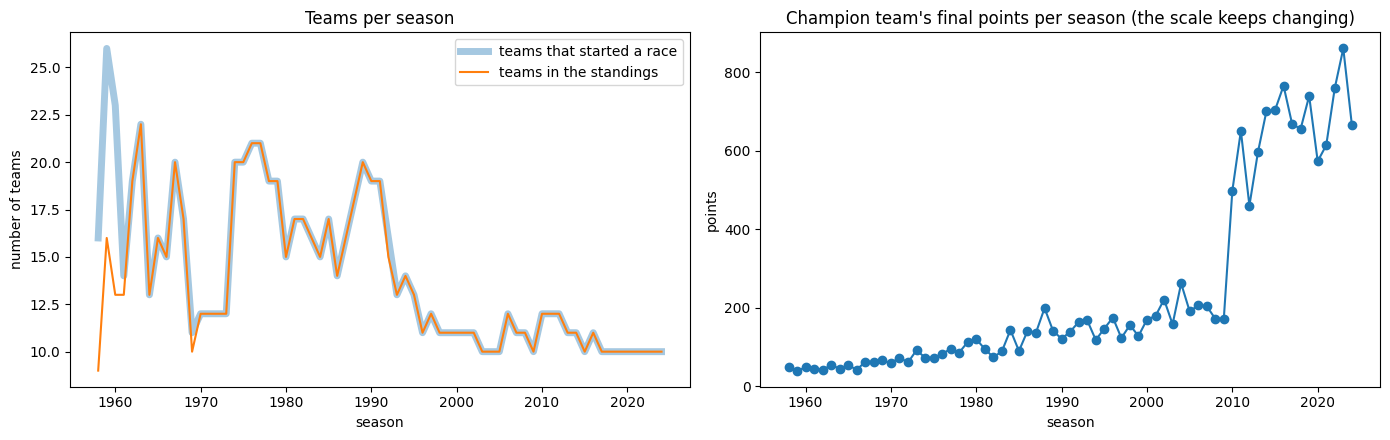

In [15]:
# ==========================================================================================
# B5 · constructor_standings: profile, coverage, odd values, post-race proof, and the safe "before the race" version
# ==========================================================================================

# Why: constructor_standings is the team championship table after each race. It looks like driver_standings (B3 and B4), but
# the team championship only started in 1958 and has its own odd cases (an excluded team, points taken away). We check what is the same and what is not.
cs = as_num(raw["constructor_standings"])     # exploring copy of constructor_standings (raw stays untouched)
cs["year"] = year_of(cs)                      # the season of each row
cs = cs.merge(races[["raceId", "round", "name"]], on="raceId")      # add the round number and race name (copy)
cs = cs.sort_values(["year", "constructorId", "round"])             # one team's season in race order
team = as_num(raw["constructors"]).set_index("constructorId").name  # team names, to read the results

# ---------- 1. Profile card, keys and links ----------
display(profile("constructor_standings"))
print(pk_check("constructor_standings", ["constructorStandingsId"]))        # the table's own id
print(pk_check("constructor_standings", ["raceId", "constructorId"]))       # one row per team per race? (the grain we need)
print("constructorId values that are not in constructors:", len(set(cs.constructorId) - set(team.index)),
      "| raceId values that are not in races:", len(set(cs.raceId) - set(races.raceId)))

# ---------- 2. Coverage: when does the table start? ----------
print("First season:", cs.year.min(), "| last season:", cs.year.max(), "| races with standings:", cs.raceId.nunique(), "of", len(races))
print("Races before 1958 that have standings:", cs[cs.year < 1958].raceId.nunique(),
      "| races from 1958 that have NO standings:", len(set(races[races.year >= 1958].raceId) - set(cs.raceId)))
print("Rows after the very first race (1958 round 1):", int(((cs.year == 1958) & (cs["round"] == 1)).sum()))

# ---------- 3. Grain: a team's row is a running total, like the drivers' table ----------
team_entries = results[["raceId", "constructorId"]].astype(int).drop_duplicates()       # which teams actually started each race
per_race = pd.DataFrame({"standings rows": cs.groupby("raceId").size(), "teams that started": team_entries.groupby("raceId").size()}).dropna()
per_race["decade"] = per_race.index.map(YEAR) // 10 * 10
display(per_race.groupby("decade").median().astype(int))                                # typical rows per race, by decade
both = cs[["raceId", "constructorId"]].merge(team_entries.assign(started=1), on=["raceId", "constructorId"], how="outer", indicator=True)
both = both[both.raceId.map(YEAR) >= 1958]                                               # the team championship exists from 1958
print("Standings rows for a team that did NOT start that race:", int((both._merge == "left_only").sum()),
      "| team starts (1958 on) with NO standings row:", int((both._merge == "right_only").sum()))

# ---------- 4. position and positionText ----------
order = cs.groupby("raceId").position.agg(["min", "max", "nunique", "size"])             # positions must run 1..n with no repeats
print("position is exactly 1..n in every race:", int(((order["min"] == 1) & (order["max"] == order["size"]) & (order["nunique"] == order["size"])).sum()),
      "of", len(order), "races")
odd = cs[pd.to_numeric(cs.positionText, errors="coerce") != cs.position]                 # text that is not the same number as position
odd = odd.assign(team=odd.constructorId.map(team), rows_in_race=odd.raceId.map(cs.groupby("raceId").size()))
print("Rows where positionText is not the same number as position:", len(odd), "| teams:", odd.team.unique().tolist(),
      "| seasons:", odd.year.unique().tolist(), "| positionText values:", odd.positionText.unique().tolist())
display(odd[["year", "round", "name", "team", "points", "position", "rows_in_race", "positionText"]].iloc[[0, 1, -1]])   # first, second and last such row
print("These rows are always last place in their race:", bool((odd.position == odd.rows_in_race).all()))

# ---------- 5. points and wins: decimals and the running-total check ----------
print("points range:", cs.points.min(), "to", cs.points.max(), "| wins range:", cs.wins.min(), "to", cs.wins.max(),
      "| rows with a decimal in points:", int((cs.points % 1 != 0).sum()))
cs["added"] = cs.groupby(["year", "constructorId"]).points.diff().fillna(cs.points)      # points added by this one race
cs["wins_added"] = cs.groupby(["year", "constructorId"]).wins.diff().fillna(cs.wins)
cs["round_jump"] = cs.groupby(["year", "constructorId"])["round"].diff()
display(cs[cs.added % 1 != 0].groupby(["year", "round", "name"]).size().rename("teams with a decimal gain").reset_index())
print("A team's wins ever go DOWN:", int((cs.wins_added < 0).sum()), "| a team skips a round and comes back:", int((cs.round_jump > 1).sum()),
      "| a team's points go DOWN:", int((cs.added < 0).sum()))
display(cs[cs.added < 0].assign(team=cs.constructorId.map(team))[["year", "round", "name", "team", "points", "added", "position"]])   # unlike the drivers' table!
for _, d in cs[cs.added < 0].iterrows():                                                 # the rounds around each drop, to see what happened
    around = cs[(cs.year == d.year) & (cs.constructorId == d.constructorId) & (cs["round"].between(d["round"] - 2, d["round"] + 1))]
    print(f"{team[d.constructorId]} {int(d.year)}: points after rounds {around['round'].astype(int).tolist()} =", around.points.tolist())

# ---------- 6. Is the table written AFTER the race? (compare with constructor_results, the team's score for that race) ----------
# constructor_results is profiled in the next steps (B6, B7); here we only use it as the reference for "points scored in this race".
cr = as_num(raw["constructor_results"])[["raceId", "constructorId", "points"]].rename(columns={"points": "race_points"})
m = cs.merge(cr, on=["raceId", "constructorId"], how="left")
m["started"] = m.race_points.notna()                                                     # False = a team carried forward that did not race this round
s = m[m.started]
same = (s.added - s.race_points).abs() < 1e-6
print("Standings rows:", len(m), "| rows of teams that raced this round:", len(s), "| points added = the team's points of that race:", int(same.sum()),
      "(", round(same.mean() * 100, 1), "% )")
print("Agreement by decade (%):", same.groupby(s.year // 10 * 10).mean().mul(100).round(1).to_dict())
print("Rows of teams that did NOT race this round add 0 points:", int((m[~m.started].added == 0).sum()), "of", int((~m.started).sum()))
disagree = s[~same]
print("Rows that disagree:", len(disagree), "| by decade:", disagree.groupby(disagree.year // 10 * 10).size().to_dict(),
      "| seasons from 1980 on:", sorted(disagree[disagree.year >= 1980].year.unique().tolist()))
sprint_team = as_num(raw["sprint_results"]).groupby(["raceId", "constructorId"]).points.sum().rename("sprint_points").reset_index()
modern = s[s.year >= 2021].merge(sprint_team, on=["raceId", "constructorId"], how="left").fillna({"sprint_points": 0})
print("Seasons 2021-2024: points added = constructor_results points:", round(((modern.added - modern.race_points).abs() < 1e-6).mean() * 100, 1),
      "% | = constructor_results + sprint points:", round(((modern.added - modern.race_points - modern.sprint_points).abs() < 1e-6).mean() * 100, 1),
      "% (so constructor_results already contains the sprint points)")

# ---------- 7. Which team starts have no standings row? ----------
res = results[["raceId", "constructorId", "points"]].astype({"raceId": int, "constructorId": int, "points": float})
res = res.groupby(["raceId", "constructorId"]).points.sum().reset_index()                 # a team's points in a race = its cars' points added
res["year"] = res.raceId.map(YEAR)
res = res[res.year >= 1958].merge(cs[["raceId", "constructorId"]].assign(has_row=1), on=["raceId", "constructorId"], how="left")
res["has_row"] = res.has_row.notna()
no_row = res[~res.has_row]
print("Team starts (1958 on):", len(res), "| without a standings row:", len(no_row), "| by decade:", no_row.groupby(no_row.year // 10 * 10).size().to_dict())
lost = no_row[no_row.points > 0].merge(races[["raceId", "round", "name"]], on="raceId")
print("Of those, starts that SCORED points:", len(lost), "| races:", sorted(lost.name.unique().tolist()), "| seasons:", sorted(lost.year.unique().tolist()))
print("Teams involved:", sorted(lost.constructorId.map(team).unique().tolist()))

# ---------- 8. The safe version: the team's standing BEFORE the race (same idea as B4) ----------
after = cs[["year", "constructorId", "round", "points", "position"]]
prev = after.assign(round=after["round"] + 1).rename(columns={"points": "points_before", "position": "position_before"})   # shift by one round
x = (cr.merge(races[["raceId", "year", "round"]], on="raceId").query("year >= 1958")
       .sort_values(["year", "constructorId", "round"]))
x["scored_before"] = x.groupby(["year", "constructorId"]).race_points.cumsum() - x.race_points   # points the team scored in earlier races
x = x.merge(prev, on=["year", "constructorId", "round"], how="left")
later = x[x["round"] > 1].copy()
later["points_before"] = later.points_before.fillna(0)                                   # no row yet = no points yet
print("Team starts after round 1:", len(later), "| standings-before equals the points scored in earlier races:",
      round(((later.points_before - later.scored_before).abs() < 1e-6).mean() * 100, 2), "%",
      "| team starts with no standings row yet before the race:", int(later.position_before.isna().sum()))
agree = (later.points_before - later.scored_before).abs() < 1e-6
print("Agreement by decade (%):", agree.groupby(later.year // 10 * 10).mean().mul(100).round(1).to_dict())

# ---------- 9. Plots (saved for the report) ----------
last_round = races.sort_values("round").groupby("year").raceId.last()                   # the last race of each season
champion = cs[cs.raceId.isin(last_round) & (cs.position == 1)].set_index("year").points  # the champion team's final points
in_standings = cs.groupby("year").constructorId.nunique()                                # teams that ever appear in a season's standings
started = team_entries.assign(year=team_entries.raceId.map(YEAR)).query("year >= 1958").groupby("year").constructorId.nunique()
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
started.rename("teams that started a race").plot(ax=ax[0], lw=5, alpha=0.4, title="Teams per season")                # thick line behind, so both stay visible
in_standings.rename("teams in the standings").plot(ax=ax[0], lw=1.5)
ax[0].legend()
ax[0].set_xlabel("season")
ax[0].set_ylabel("number of teams")
champion.plot(ax=ax[1], marker="o", title="Champion team's final points per season (the scale keeps changing)")
ax[1].set_xlabel("season")
ax[1].set_ylabel("points")
plt.tight_layout()
plt.savefig("figures/B5_constructor_standings.png", dpi=120, bbox_inches="tight")
plt.show()

**B5 result:**
- **Clean on the surface.** 13,391 rows x 7 columns, no `\N`, no empty cells. `constructorStandingsId` and (`raceId`, `constructorId`) are unique, and every `constructorId` and `raceId` exists in its table.
- **It starts in 1958 (the first constructors' championship).** None of the 64 races before 1958 has team standings; all 1,061 races from 1958 do. The very first race (1958 round 1) has only 3 rows. There are no team features before 1958.
- **Same shape as the drivers' table.** A row is a running total: 892 rows belong to a team that did not start that race, a team's wins never go down, and no team skips a round. `position` is exactly 1..n in all 1,061 races.
- **One excluded team:** `positionText` is `E` in 17 rows, all McLaren 2007 (every round). Those rows are always last place (position 11 of 11) while the points keep rising to 218, because McLaren was excluded from that championship.
- **Decimals:** 141 rows with decimal points, caused by only 6 half-points races (1975 Spain and Austria, 1984 Monaco, 1991 Australia, 2009 Malaysia, 2021 Belgium). Points run 0 to 860 (2023); wins 0 to 21.
- **A difference from the drivers: team points can go DOWN, twice.** Force India 2018, round 13: 59 -> 18 (the team's earlier points were removed when it was restarted); Racing Point 2020, round 5: 42 -> 41 (a points penalty that weekend). The causes are known F1 history; the table shows only the net result. Do not assume the totals only grow.
- **The table is written after the race and includes the sprint.** The points a row adds equal the team's `constructor_results` points of that race in **12,412 of 12,497 rows (99.3%)**; teams that did not race add 0 points (894 of 894). The 85 disagreements are in 1958 to 1977 (81 rows, the old "best car only" and drop rules) and four rows in 2007 (McLaren), 2018 and 2020. In 2021 to 2024 the standings equal `constructor_results` in 100% of rows but equal `constructor_results` plus sprint points in only 90.9%, so `constructor_results` already contains the sprint points (B7 checks this against the drivers).
- **A rule that did NOT carry over from the drivers: "a scorer always has a row".** 129 team starts (1958 on) have no standings row (1990s 67, 2000s 25, 1950s 18, 1960s 12, the rest 7). 119 scored nothing in that race, but **10 scored points: all Indianapolis 500 chassis of 1958 to 1960** (Watson, Epperly, Kurtis Kraft, Lesovsky, Phillips, Trevis). They never get a standings row, because the team championship did not count them.
- **The safe version:** the standings from the previous round of the same season equal the points scored in earlier races in **98.76% of 11,847 team starts** (after round 1): 100% in the 1980s and 1990s, 99.6% to 99.8% in the 2000s and 2010s, 98.8% in the 2020s, but only 93% to 97% in 1958 to 1979. A drop such as Force India 2018 shifts all later rows of that team. 269 team starts after round 1 have no row yet before the race.
- **The scale changes:** the champion team's final points go from 48 (1958) to 172 (2009), jump to 498 (2010, new points system) and reach 860 (2023). Teams in the standings go from 9 (1958) to 22 (1963) and down to 10 (2020s).

**Decisions for features and leakage:**
1. Same rule as the drivers: only use the team standings from the **previous round of the same season** (shift by season + round, never by `raceId`). The row under the same `raceId` contains the race and its sprint.
2. There are no team standings before 1958, and none before the first race of a season: build the team features with a flag (such as `has_team_standing`) or start the team-feature window in 1958. Alternatively, derive team form from `results` for all seasons (B7 decides).
3. A missing row means 0 points for real F1 teams. The only scorers without rows are the Indianapolis 500 chassis of 1958 to 1960, which are not constructors' championship teams: leave them out of any team feature.
4. Keep McLaren 2007 in the data but do not read its `position` (always last place) as real form; the 2 point drops mean "totals only grow" must not be assumed in code.
5. Prefer scale-free versions (team position, gap to the leader, share of the leader's points) over raw points.

## B6 · constructor_results: profile, coverage, how it matches results, the nearly empty status column, and points

- **What:** profile `constructor_results` (the points each team scored in each race), check its keys, find which races it covers, line it up with the teams that really started (`results`), look at the almost empty `status` column, and study the `points` column.
- **Why:** before B7 decides whether team form should come from this table or from `results`, we must know what one row means, where rows are missing or extra, and whether any column carries real information. Remember it describes what a team scored *in that race*, so it is an outcome: it can never describe the race we are predicting.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
constructorResultsId,0,0.00,0,12625,100.0,1
raceId,0,0.00,0,1060,100.0,18
constructorId,0,0.00,0,175,100.0,1
points,0,0.00,0,61,100.0,14
status,12608,99.87,0,2,0.0,\N


{'table': 'constructor_results', 'key': 'constructorResultsId', 'rows': 12625, 'duplicates': 0, 'null_or_sentinel': 0}
{'table': 'constructor_results', 'key': 'raceId+constructorId', 'rows': 12625, 'duplicates': 0, 'null_or_sentinel': 0}
constructorId values that are not in constructors: 0 | raceId values that are not in races: 0
Seasons: 1958 to 2024 | races with rows: 1060 of 1125
Races with no rows: 65 | before 1958: 64 | from 1958 on: [[1958, 'Indianapolis 500']]
Rows per race: min 3 | median 11 | max 20 | median by decade: {1950: 6, 1960: 9, 1970: 14, 1980: 15, 1990: 13, 2000: 10, 2010: 11, 2020: 10}
Team-races in both tables: 12618 | only in constructor_results: 7 | only in results: 410


,year,round,name,team,points
3017,2002,1,Australian Grand Prix,BMW Sauber,0.0
6474,1979,3,South African Grand Prix,Brabham,1.0
6566,1979,11,Austrian Grand Prix,Brabham,0.0
10624,2015,11,Belgian Grand Prix,Marussia,0.0
10666,2015,15,Russian Grand Prix,Marussia,0.0
10685,2015,17,Mexican Grand Prix,Marussia,0.0
10707,2015,19,Abu Dhabi Grand Prix,Marussia,0.0


Teams that started but have no row: before 1958: 400 | from 1958 on: 10


,year,round,name,team,points,best_finish,cars
0,1971,2,Spanish Grand Prix,March-Alfa Romeo,0.0,17,1
1,1959,4,French Grand Prix,BRM,1.0,6,4
2,1958,4,Indianapolis 500,Watson,0.0,6,4
3,1958,4,Indianapolis 500,Epperly,20.0,1,4
4,1958,4,Indianapolis 500,Phillips,0.0,7,1
5,1958,4,Indianapolis 500,Lesovsky,0.0,20,2
6,1958,4,Indianapolis 500,Kurtis Kraft,4.0,3,16
7,1958,4,Indianapolis 500,Kuzma,0.0,13,5
8,1958,4,Indianapolis 500,Dunn,0.0,24,1
409,2012,1,Australian Grand Prix,HRT,0.0,23,2


status values: {nan: 12608, 'D': 17}
Rows with a status: 17 | teams and seasons: {('McLaren', 2007): 17}
The same team-races as the 'E' rows of constructor_standings: True | points the team still scored: 218.0
points range: 0.0 to 66.0 | negative: 0 | rows with a decimal: 16 | decimal races: [(1975, 4), (1975, 12), (1984, 6), (1991, 16), (2009, 2), (2021, 12)]
Rows with 0 points, by decade (%): {1950: 56.2, 1960: 51.3, 1970: 63.7, 1980: 69.7, 1990: 65.2, 2000: 48.8, 2010: 39.1, 2020: 34.0}
Team points handed out per race, average by decade: {1950: 16, 1960: 20, 1970: 22, 1980: 25, 1990: 26, 2000: 35, 2010: 102, 2020: 107}


,year,round,name,team,points
10506,2014,19,Abu Dhabi Grand Prix,Williams,66.0
11979,2022,4,Emilia Romagna Grand Prix,Red Bull,58.0
12149,2022,21,São Paulo Grand Prix,Mercedes,58.0
12199,2023,4,Azerbaijan Grand Prix,Red Bull,57.0


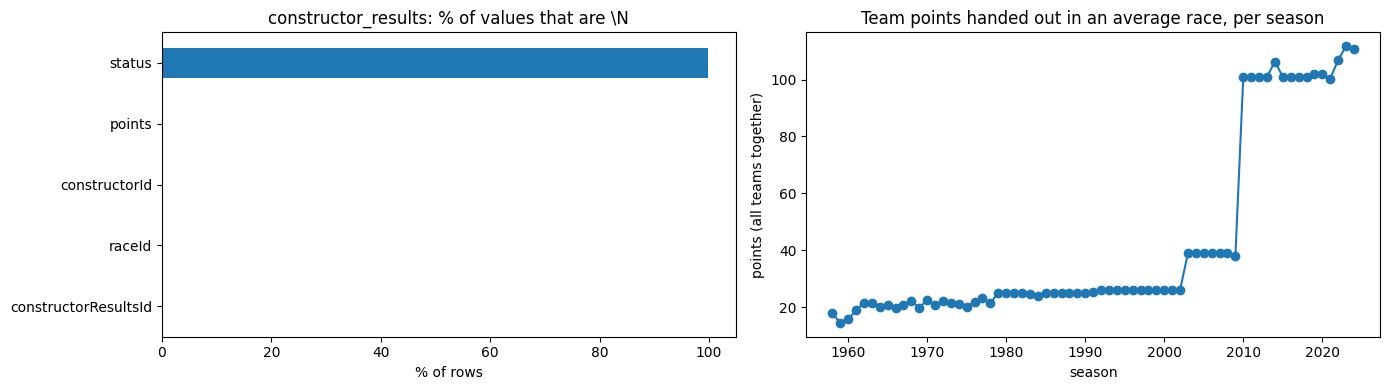

In [16]:
# ==========================================================================================
# B6 · constructor_results: profile, coverage, how it matches results, the nearly empty status column, and points
# ==========================================================================================

# Why: constructor_results says how many points each team scored in each race. Before we use it (or decide not to, in B7),
# we need to know what one row means, which races it covers, how it lines up with the results table, and what its odd columns hold.
cr = as_num(raw["constructor_results"])      # exploring copy of constructor_results (raw stays untouched)
cr["year"] = year_of(cr)                     # the season of each row
cr = cr.merge(races[["raceId", "round", "name"]], on="raceId")      # add the round number and race name (copy)
team = as_num(raw["constructors"]).set_index("constructorId").name  # team names, to read the results

# ---------- 1. Profile card, keys and links ----------
display(profile("constructor_results"))
print(pk_check("constructor_results", ["constructorResultsId"]))        # the table's own id
print(pk_check("constructor_results", ["raceId", "constructorId"]))     # one row per team per race? (the grain we need)
print("constructorId values that are not in constructors:", len(set(cr.constructorId) - set(team.index)),
      "| raceId values that are not in races:", len(set(cr.raceId) - set(races.raceId)))

# ---------- 2. Coverage: which races have rows? ----------
print("Seasons:", cr.year.min(), "to", cr.year.max(), "| races with rows:", cr.raceId.nunique(), "of", len(races))
no_rows = races[~races.raceId.isin(cr.raceId)]
print("Races with no rows:", len(no_rows), "| before 1958:", int((no_rows.year < 1958).sum()), "| from 1958 on:",
      no_rows[no_rows.year >= 1958][["year", "name"]].values.tolist())
rows_per_race = cr.groupby("raceId").size()
print("Rows per race: min", rows_per_race.min(), "| median", int(rows_per_race.median()), "| max", rows_per_race.max(),
      "| median by decade:", rows_per_race.groupby(rows_per_race.index.map(YEAR) // 10 * 10).median().astype(int).to_dict())

# ---------- 3. How does it line up with the teams that actually started (results)? ----------
team_entries = results[["raceId", "constructorId"]].astype(int).drop_duplicates()          # the teams that really started each race
line_up = cr[["raceId", "constructorId"]].merge(team_entries.assign(started=1), on=["raceId", "constructorId"], how="outer", indicator=True)
print("Team-races in both tables:", int((line_up._merge == "both").sum()), "| only in constructor_results:", int((line_up._merge == "left_only").sum()),
      "| only in results:", int((line_up._merge == "right_only").sum()))
only_cr = cr.merge(team_entries.assign(started=1), on=["raceId", "constructorId"], how="left")
only_cr = only_cr[only_cr.started.isna()]                                                  # a row for a team that has no result row that race
display(only_cr.assign(team=only_cr.constructorId.map(team))[["year", "round", "name", "team", "points"]])
by_team_race = results[["raceId", "constructorId", "points", "positionOrder"]].astype({"raceId": int, "constructorId": int, "points": float, "positionOrder": int})
by_team_race = by_team_race.groupby(["raceId", "constructorId"]).agg(points=("points", "sum"), best_finish=("positionOrder", "min"), cars=("points", "size")).reset_index()
only_res = by_team_race.merge(cr[["raceId", "constructorId"]].assign(in_cr=1), on=["raceId", "constructorId"], how="left")
only_res = only_res[only_res.in_cr.isna()].merge(races[["raceId", "year", "round", "name"]], on="raceId")      # a team that started but has no row
print("Teams that started but have no row: before 1958:", int((only_res.year < 1958).sum()), "| from 1958 on:", int((only_res.year >= 1958).sum()))
display(only_res[only_res.year >= 1958].assign(team=lambda d: d.constructorId.map(team))[["year", "round", "name", "team", "points", "best_finish", "cars"]])

# ---------- 4. The status column ----------
print("status values:", cr.status.value_counts(dropna=False).to_dict())
flagged = cr[cr.status.notna()]
print("Rows with a status:", len(flagged), "| teams and seasons:", flagged.assign(team=flagged.constructorId.map(team)).groupby(["team", "year"]).size().to_dict())
excluded = as_num(raw["constructor_standings"])
excluded = excluded[excluded.positionText == "E"]                                           # the excluded-team rows we found in B5
print("The same team-races as the 'E' rows of constructor_standings:", set(zip(flagged.raceId, flagged.constructorId)) == set(zip(excluded.raceId, excluded.constructorId)),
      "| points the team still scored:", flagged.points.sum())

# ---------- 5. The points column ----------
print("points range:", cr.points.min(), "to", cr.points.max(), "| negative:", int((cr.points < 0).sum()), "| rows with a decimal:", int((cr.points % 1 != 0).sum()),
      "| decimal races:", cr[cr.points % 1 != 0].groupby(["year", "round"]).size().index.tolist())
print("Rows with 0 points, by decade (%):", cr.groupby(cr.year // 10 * 10).points.apply(lambda s: round((s == 0).mean() * 100, 1)).to_dict())
points_per_race = cr.groupby(["year", "raceId"]).points.sum()                              # all the team points handed out in one race
print("Team points handed out per race, average by decade:", points_per_race.groupby(points_per_race.index.get_level_values(0) // 10 * 10).mean().round(0).astype(int).to_dict())
display(cr.nlargest(4, "points").assign(team=lambda d: d.constructorId.map(team))[["year", "round", "name", "team", "points"]])

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
profile("constructor_results")["sentinel_%"].sort_values().plot.barh(ax=ax[0], title="constructor_results: % of values that are \\N")
ax[0].set_xlabel("% of rows")
points_per_race.groupby(level=0).mean().plot(ax=ax[1], marker="o", title="Team points handed out in an average race, per season")
ax[1].set_xlabel("season")
ax[1].set_ylabel("points (all teams together)")
plt.tight_layout()
plt.savefig("figures/B6_constructor_results.png", dpi=120, bbox_inches="tight")
plt.show()

**B6 result:**
- **Clean on the surface.** 12,625 rows x 5 columns. `constructorResultsId` and (`raceId`, `constructorId`) are unique, and every `constructorId` and `raceId` exists in its table. `status` is the only column with `\N`: 12,608 of 12,625 rows (99.87%).
- **Coverage:** seasons 1958 to 2024, 1,060 of 1,125 races. The 65 races with no rows are the 64 races before 1958 (no team championship yet) and the **1958 Indianapolis 500**, the only race since 1958 with no rows at all. Median rows per race: 6 in the 1950s, 15 in the 1980s, 10 in the 2020s.
- **Lining up with `results`:** 12,618 team-races are in both tables.
  - **7 rows have no team start in `results`:** BMW Sauber 2002 round 1 (0 points), Brabham 1979 rounds 3 (1 point) and 11, and Marussia in four 2015 rounds (no cars of the team in `results`).
  - **410 team starts have no row:** 400 before 1958, plus 10 from 1958 on: seven Indianapolis 500 chassis in 1958 (Epperly 20 points, Kurtis Kraft 4), BRM at the 1959 French GP (1 point), March-Alfa Romeo 1971 Spain (0) and HRT 2012 Australia (0).
- **`status` is nearly empty and holds one value, `D`, in 17 rows**, all McLaren 2007. They are exactly the 17 `E` rows of `constructor_standings` (B5), and the team still scored 218 points in them.
- **Points:** 0 to 66 (Williams, 2014 Abu Dhabi, the double-points race), never negative. 16 rows have decimals, all from the same 6 half-points races as in B3 and B5. The share of rows with 0 points falls from 70% (1980s) to 34% (2020s), because more teams score now. The points all teams share in an average race grow from 16 (1950s) to 25 (1980s), 35 (2000s), 102 (2010s) and 107 (2020s). After 2014 the largest values are sprint weekends (Imola 2022, São Paulo 2022, Azerbaijan 2023), which confirms that sprint points are inside this table.

**Decisions for features and leakage:**
1. Drop `status` after recording the McLaren 2007 fact. It carries nothing a model could use (one team, one season), and it is the same information as the `E` rows in B5.
2. `constructor_results` is the team's outcome in that race. It may only enter a feature **lagged** (from earlier races of the same season or earlier seasons), never for the race being predicted.
3. Rows are missing before 1958 and for the 1958 Indianapolis 500, so a team-form feature built from this table needs a flag. B7 decides whether to build team form from `results` instead.
4. The 7 rows without a team start can be ignored when joining on the team starts in `results`. Keep Brabham 1979 round 3 (1 point) in mind for B7.
5. Points are not comparable across seasons (16 to 107 per race): use the share of the points handed out in the race, or a rank, not raw points.

## B7 · constructor_results: does a team's score equal the points of its drivers? Which source should team form use?

- **What:** for every team-race, add up the points of the team's drivers from `results` (and, from 2021, the sprint points from `sprint_results`) and compare that with the team's score in `constructor_results`. Then find out why they differ and in which seasons.
- **Why:** a "team form" feature must mean the same thing in every season. If the official team score follows changing rules, a feature built from it changes meaning over time. We need to choose the source before building features.

Rows in constructor_results: 12625 | rows with no team start in results (found in B6, left out here): 7
Team-races compared: 12618 | equal to the drivers' sum: 12234 ( 96.96 % ) | equal once sprint points are added: 12316 ( 97.61 % )
Differences from the drivers' sum, by decade: {1950: 29, 1960: 135, 1970: 138, 2020: 82}
Differences after adding sprint points, by decade: {1950: 29, 1960: 135, 1970: 138} | seasons: 1958 to 1978
Seasons 2021-2024: 900 team-races | differ from the drivers' sum: 82 | team-races with sprint points: 82 | equal WITH sprint points: 82 | equal WITHOUT them: 0
Differences left after the sprint: 302 | team scored LESS than its drivers: 302 | MORE: 0


,rows
reason,
only the best car counted,292
best car minus the fastest-lap point,9
something else,1


1958-1978, teams with 2 or more cars and points: 978 | equal to the best car: 957 | equal to the sum of all cars: 676
From 1979 on: team-races 9911 | equal to the drivers' sum (+ sprint): 9911
McLaren 2007: 17 team-races | equal to the drivers' sum: 17 | total points: 218.0 (the exclusion from the championship is NOT in these points)


,team score = drivers' sum,team score = drivers' sum + sprint
year,,
1950,77.7,77.7
1960,84.6,84.6
1970,92.9,92.9
1980,100.0,100.0
1990,100.0,100.0
2000,100.0,100.0
2010,100.0,100.0
2020,92.3,100.0


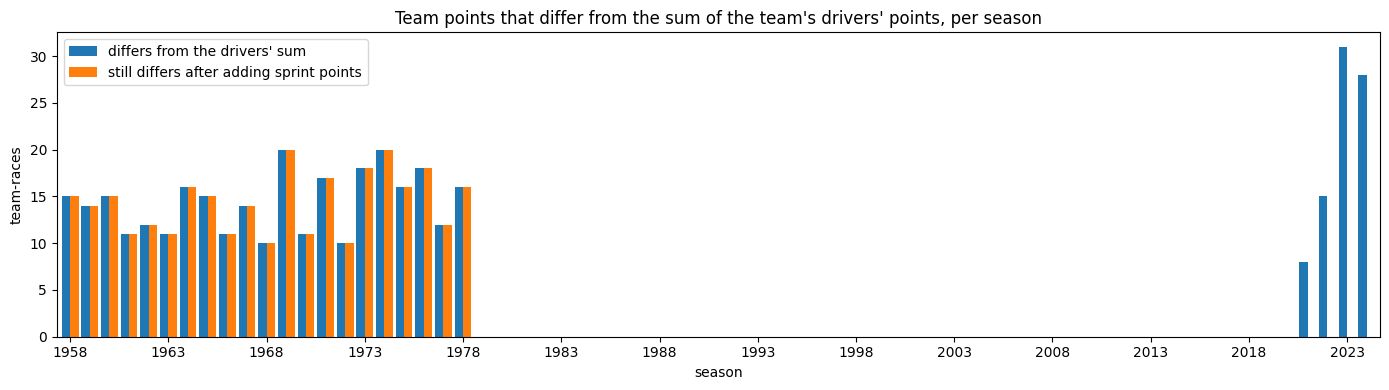

In [17]:
# ==========================================================================================
# B7 · constructor_results: does a team's score equal the points of its drivers? Which source should team form use?
# ==========================================================================================

# Why: team form ("how good is this team right now?") must come from ONE source that means the same thing in every season.
# constructor_results is the official team score, results has the points of every driver. We measure where they differ and why.
cr = as_num(raw["constructor_results"])      # exploring copy of constructor_results (raw stays untouched)
cr["year"] = year_of(cr)
team = as_num(raw["constructors"]).set_index("constructorId").name

# What the drivers of each team scored in each race (Sunday race, from results)
rs = results[["raceId", "constructorId", "points", "positionOrder"]].astype({"raceId": int, "constructorId": int, "points": float, "positionOrder": int})
drivers = rs.groupby(["raceId", "constructorId"]).agg(drivers_sum=("points", "sum"),        # all cars added together
                                                      best_car=("points", "max"),           # only the best car
                                                      cars=("points", "size")).reset_index()
# What the drivers of each team scored in the Saturday sprint (2021 onward)
sprint = as_num(raw["sprint_results"]).groupby(["raceId", "constructorId"]).points.sum().rename("sprint_sum").reset_index()

j = cr.merge(drivers, on=["raceId", "constructorId"], how="left").merge(sprint, on=["raceId", "constructorId"], how="left")
j["sprint_sum"] = j.sprint_sum.fillna(0)                                    # no sprint = 0
print("Rows in constructor_results:", len(j), "| rows with no team start in results (found in B6, left out here):", int(j.drivers_sum.isna().sum()))
j = j[j.drivers_sum.notna()].copy()                                         # compare only team-races that exist in both tables

# ---------- 1. Does the team score equal the sum of its drivers' points? ----------
j["same_as_drivers"] = (j.points - j.drivers_sum).abs() < 1e-6
j["same_with_sprint"] = (j.points - j.drivers_sum - j.sprint_sum).abs() < 1e-6        # a team's sprint points added to its drivers' race points
print("Team-races compared:", len(j), "| equal to the drivers' sum:", int(j.same_as_drivers.sum()), "(", round(j.same_as_drivers.mean() * 100, 2), "% )",
      "| equal once sprint points are added:", int(j.same_with_sprint.sum()), "(", round(j.same_with_sprint.mean() * 100, 2), "% )")
print("Differences from the drivers' sum, by decade:", j[~j.same_as_drivers].groupby(j.year // 10 * 10).size().to_dict())
print("Differences after adding sprint points, by decade:", j[~j.same_with_sprint].groupby(j.year // 10 * 10).size().to_dict(),
      "| seasons:", int(j[~j.same_with_sprint].year.min()), "to", int(j[~j.same_with_sprint].year.max()))

# ---------- 2. The 2021-2024 differences: are they all sprints? ----------
modern = j[j.year >= 2021]
sprint_rows = modern[modern.sprint_sum > 0]                                  # team-races where the team scored sprint points
print("Seasons 2021-2024:", len(modern), "team-races | differ from the drivers' sum:", int((~modern.same_as_drivers).sum()),
      "| team-races with sprint points:", len(sprint_rows), "| equal WITH sprint points:", int(sprint_rows.same_with_sprint.sum()),
      "| equal WITHOUT them:", int(sprint_rows.same_as_drivers.sum()))

# ---------- 3. The 1958-1978 differences: which rule explains them? ----------
def reason(r):
    if abs(r.points - r.drivers_sum - r.sprint_sum) < 1e-6:
        return "equal to the drivers' sum"
    if abs(r.points - r.best_car) < 1e-6:
        return "only the best car counted"
    if abs(r.points - (r.best_car - 1)) < 1e-6:
        return "best car minus the fastest-lap point"
    return "something else"
old = j[~j.same_with_sprint].copy()                                         # every difference that is left after the sprint is added
old["reason"] = old.apply(reason, axis=1)
print("Differences left after the sprint:", len(old), "| team scored LESS than its drivers:", int((old.points < old.drivers_sum).sum()),
      "| MORE:", int((old.points > old.drivers_sum + old.sprint_sum).sum()))
display(old.reason.value_counts().rename("rows").to_frame())
scored = j[(j.year <= 1978) & (j.drivers_sum > 0) & (j.cars >= 2)]          # old seasons, teams with points and at least two cars
print("1958-1978, teams with 2 or more cars and points:", len(scored), "| equal to the best car:", int(((scored.points - scored.best_car).abs() < 1e-6).sum()),
      "| equal to the sum of all cars:", int(((scored.points - scored.drivers_sum).abs() < 1e-6).sum()))
print("From 1979 on: team-races", int((j.year >= 1979).sum()), "| equal to the drivers' sum (+ sprint):", int(j[j.year >= 1979].same_with_sprint.sum()))

# ---------- 4. The excluded team ----------
mc = j[(j.year == 2007) & (j.constructorId == cr[cr.status.notna()].constructorId.iloc[0])]     # the team with status D (McLaren, 2007)
print("McLaren 2007:", len(mc), "team-races | equal to the drivers' sum:", int(mc.same_as_drivers.sum()), "| total points:", mc.points.sum(),
      "(the exclusion from the championship is NOT in these points)")

# ---------- 5. Which source is consistent in every era? ----------
by_era = pd.DataFrame({"team score = drivers' sum": j.groupby(j.year // 10 * 10).same_as_drivers.mean() * 100,
                       "team score = drivers' sum + sprint": j.groupby(j.year // 10 * 10).same_with_sprint.mean() * 100}).round(1)
display(by_era)

# ---------- 6. Plots (saved for the report) ----------
by_season = pd.DataFrame({"differs from the drivers' sum": j[~j.same_as_drivers].groupby("year").size(),
                          "still differs after adding sprint points": j[~j.same_with_sprint].groupby("year").size()}).reindex(range(1958, 2025), fill_value=0).fillna(0)
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(14, 4))
by_season.plot.bar(ax=ax, width=0.85, title="Team points that differ from the sum of the team's drivers' points, per season")
ax.set_xlabel("season")
ax.set_ylabel("team-races")
ax.set_xticks(range(0, len(by_season), 5))
ax.set_xticklabels(by_season.index[::5], rotation=0)
plt.tight_layout()
plt.savefig("figures/B7_team_vs_drivers_points.png", dpi=120, bbox_inches="tight")
plt.show()

**B7 result:**
- **They agree for most rows, and the exceptions have clear causes.** 12,618 team-races exist in both tables (the 7 rows without a team start from B6 are left out). The team score equals the sum of its drivers' points in **12,234 (96.96%)**; once sprint points are added, in **12,316 (97.61%)**.
- **From 1979 on they are identical.** All 9,911 team-races from 1979 to 2024 equal the drivers' sum (plus sprint points).
- **2021 to 2024: every difference is a sprint.** 82 team-races differ from the drivers' sum, and these are exactly the 82 team-races where the team scored sprint points. All 82 match once the sprint points are added, none matches without them. So `constructor_results` includes the sprint, while `results.points` does not.
- **1958 to 1978: only the best car counted for the team.** 302 team-races are left after adding the sprint. In all of them the team scored *less* than its drivers (never more). 292 equal the points of the best-placed car only, 9 equal the best car minus the 1-point fastest-lap bonus (1958 and 1959), and 1 is a one-off (BRM, 1959 British GP: 6 points against a best car with 6.5). For teams with two or more cars and points in 1958 to 1978, 957 of 978 equal the best car, but only 676 equal the sum of all cars.
- **McLaren 2007:** all 17 team-races equal the drivers' sum (218 points in total). The exclusion from the championship is *not* in these points; it only shows in the `E` and `D` flags of B5 and B6.
- **By decade, the share equal to the drivers' sum:** 77.7% (1958 to 1959), 84.6% (1960s), 92.9% (1970s), 100% (1980s to 2010s), and 92.3% in the 2020s (100% with sprint points).

**Decisions for features and leakage:**
1. **Build team form from `results`** (the points or finishing positions of the team's drivers in earlier races), not from `constructor_results`. In `results` every car counts the same way in every season; in `constructor_results` the meaning changes (best car only until 1978, sprint points from 2021).
2. If team form should include sprint points, add `sprint_results` explicitly and only for earlier weekends. `results.points` never contains them.
3. If the official team points are needed, use `constructor_standings` (B5) from 1958 with the one-round shift, and write down that its rules changed in 1979 and 2021.
4. For the brief's two periods (2014 to 2021 and 2022 to 2024) both sources give the same numbers, apart from the sprint weekends of 2021 to 2024. The difference only matters if we use seasons before 1979.
5. Write the best-car rule (1958 to 1978) and the sprint rule (2021 on) in the report, because both change what a "team point" means.

## C1 · lap_times: profile, keys, coverage, what one row means, and the time format

- **What:** profile the biggest table (one row per driver per lap), check its key and links, find which races have lap data, check that every driver's laps are complete, understand `position`, and test whether the `time` text can be trusted.
- **Why:** lap times could tell us how fast a driver or team has been recently. Before looking for strange laps (C2), we must know what a row means, where lap data exists at all, and which time column to use.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
raceId,0,0.0,0,544,100.0,841
driverId,0,0.0,0,143,100.0,20
lap,0,0.0,0,87,100.0,1
position,0,0.0,0,24,100.0,1
time,0,0.0,0,75806,0.0,1:38.109
milliseconds,0,0.0,0,75806,100.0,98109


{'table': 'lap_times', 'key': 'raceId+driverId+lap', 'rows': 589081, 'duplicates': 0, 'null_or_sentinel': 0}
driverId values that are not in drivers: 0 | raceId values that are not in races: 0 | driver-races with laps but no row in results: 0 of 11041
Rows: 589081 | races: 544 | drivers: 143 | seasons: 1996 to 2024
Races from 1996 on: 544 | of them with lap data: 544 | races before 1996 with lap data: 0
Driver-races: 11041 | laps run exactly 1..n with no gaps: 11041
Race-laps: 33196 | positions are all different within a lap: 33196 | positions run exactly 1..n: 33196
Lap numbers: 1 to 87 | position: 1 to 24 | laps in the longest and shortest race: [87, 1]
Cars with lap data per race: min 6 | median 20 | max 24


,year,round,name,cars
78,2005,9,United States Grand Prix,6
123,2002,1,Australian Grand Prix,14
921,2015,1,Australian Grand Prix,13


Shortest race: [[2021, 'Belgian Grand Prix']] with 1 lap
time looks like m:ss.mmm: 589038 | h:mm:ss.mmm: 43 | any other format: 0
time text agrees with the milliseconds column: 589081 of 589081


,,rows,first_lap,last_lap,shortest,longest
year,name,,,,,
2011,Canadian Grand Prix,23,25,25,2:04:29.869,2:05:07.547
2014,British Grand Prix,20,1,2,1:01:07.384,1:03:23.459


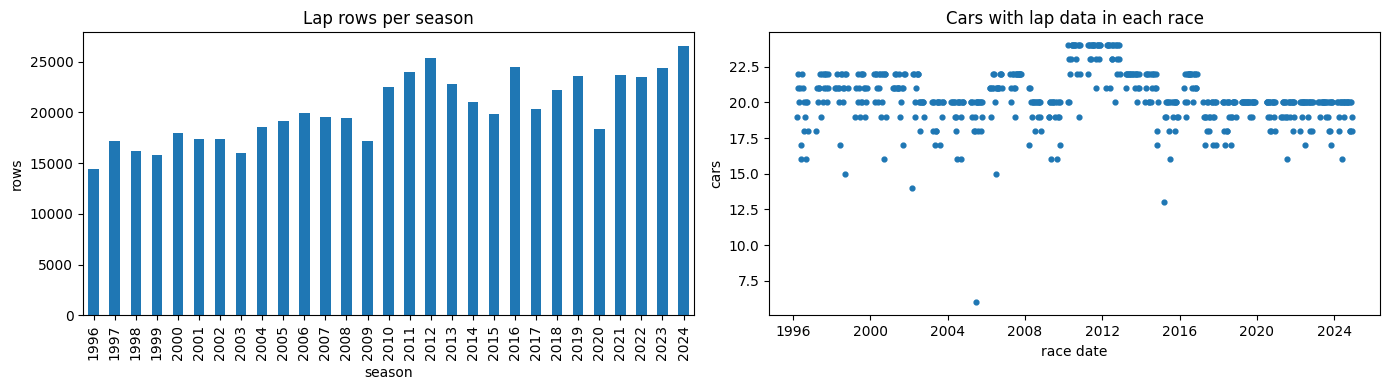

In [18]:
# ==========================================================================================
# C1 · lap_times: profile, keys, coverage, what one row means, and the time format
# ==========================================================================================

# Why: lap_times is by far our biggest table (one row per driver per lap). Before looking for strange laps (C2), we check what a row
# means, which races it covers, whether every driver's laps are complete, and whether the time text can be trusted.
lt = as_num(raw["lap_times"])      # exploring copy of lap_times (raw stays untouched)
lt["year"] = year_of(lt)           # the season of each lap
lt = lt.merge(races[["raceId", "round", "name", "date"]], on="raceId")     # add the round, race name and date (copy)

# ---------- 1. Profile card, keys and links ----------
display(profile("lap_times"))
print(pk_check("lap_times", ["raceId", "driverId", "lap"]))                # one row per driver per lap? (the grain we expect)
race_entries = results[["raceId", "driverId"]].astype(int)                  # who really started each race
driver_races = lt[["raceId", "driverId"]].drop_duplicates().merge(race_entries.assign(started=1), on=["raceId", "driverId"], how="left")
print("driverId values that are not in drivers:", len(set(lt.driverId) - set(raw["drivers"].driverId.astype(int))),
      "| raceId values that are not in races:", len(set(lt.raceId) - set(races.raceId)),
      "| driver-races with laps but no row in results:", int(driver_races.started.isna().sum()), "of", len(driver_races))

# ---------- 2. Coverage: which races have lap data? ----------
print("Rows:", len(lt), "| races:", lt.raceId.nunique(), "| drivers:", lt.driverId.nunique(), "| seasons:", lt.year.min(), "to", lt.year.max())
coverage = pd.DataFrame({"races": races.groupby("year").size(), "races with laps": lt.groupby("year").raceId.nunique()}).fillna(0).astype(int)
print("Races from 1996 on:", int((races.year >= 1996).sum()), "| of them with lap data:", int(coverage[coverage.index >= 1996]["races with laps"].sum()),
      "| races before 1996 with lap data:", int(coverage[coverage.index < 1996]["races with laps"].sum()))

# ---------- 3. Grain: are a driver's laps complete, and what does position mean? ----------
per_driver = lt.groupby(["raceId", "driverId"]).lap.agg(["min", "max", "nunique", "size"])                     # each driver's laps in each race
complete = (per_driver["min"] == 1) & (per_driver["max"] == per_driver["nunique"]) & (per_driver["nunique"] == per_driver["size"])
print("Driver-races:", len(per_driver), "| laps run exactly 1..n with no gaps:", int(complete.sum()))
per_lap = lt.groupby(["raceId", "lap"]).position.agg(["nunique", "size", "max"])                                 # the running order on each lap
print("Race-laps:", len(per_lap), "| positions are all different within a lap:", int((per_lap["nunique"] == per_lap["size"]).sum()),
      "| positions run exactly 1..n:", int((per_lap["max"] == per_lap["size"]).sum()))
print("Lap numbers:", lt.lap.min(), "to", lt.lap.max(), "| position:", lt.position.min(), "to", lt.position.max(),
      "| laps in the longest and shortest race:", lt.groupby("raceId").lap.max().agg(["max", "min"]).tolist())
cars = lt.groupby("raceId").driverId.nunique()                                                                   # how many cars have lap data in each race
print("Cars with lap data per race: min", cars.min(), "| median", int(cars.median()), "| max", cars.max())
display(races[races.raceId.isin(cars[cars < 15].index)].assign(cars=lambda d: d.raceId.map(cars))[["year", "round", "name", "cars"]])
shortest = lt.groupby("raceId").lap.max().idxmin()                                                               # the race with the fewest laps
print("Shortest race:", races[races.raceId == shortest][["year", "name"]].values.tolist(), "with", lt[lt.raceId == shortest].lap.max(), "lap")

# ---------- 4. The time format: text, but is it trustworthy? ----------
t = lt.time                                                        # the time text (as_num keeps text columns as they are)
normal = t.str.match(r"^\d+:\d{2}\.\d{3}$")                         # m:ss.mmm, e.g. 1:26.572
with_hours = t.str.match(r"^\d+:\d{2}:\d{2}\.\d{3}$")               # h:mm:ss.mmm, e.g. 2:05:05.152
print("time looks like m:ss.mmm:", int(normal.sum()), "| h:mm:ss.mmm:", int(with_hours.sum()), "| any other format:", int((~normal & ~with_hours).sum()))
def lap_text_to_ms(s):
    # "1:26.572" or "2:05:05.152" -> milliseconds
    parts = s.split(":")
    seconds = float(parts[-1])
    minutes = float(parts[-2])
    hours = float(parts[-3]) if len(parts) > 2 else 0.0
    return round(((hours * 60 + minutes) * 60 + seconds) * 1000)
print("time text agrees with the milliseconds column:", int((lt.time.map(lap_text_to_ms) == lt.milliseconds).sum()), "of", len(lt))
long_laps = lt[with_hours]                                          # the laps written with hours
display(long_laps.groupby(["year", "name"]).agg(rows=("lap", "size"), first_lap=("lap", "min"), last_lap=("lap", "max"),
                                                  shortest=("time", "min"), longest=("time", "max")))

# ---------- 5. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
lt.groupby("year").size().plot.bar(ax=ax[0], title="Lap rows per season")
ax[0].set_xlabel("season")
ax[0].set_ylabel("rows")
race_date = races.set_index("raceId").date
ax[1].scatter(race_date.reindex(cars.index), cars.values, s=12)
ax[1].set_title("Cars with lap data in each race")
ax[1].set_xlabel("race date")
ax[1].set_ylabel("cars")
plt.tight_layout()
plt.savefig("figures/C1_lap_times.png", dpi=120, bbox_inches="tight")
plt.show()

**C1 result:**
- **Clean on the surface.** 589,081 rows x 6 columns, no `\N`, no empty cells. (`raceId`, `driverId`, `lap`) is unique, every ID exists in its table, and every one of the 11,041 driver-races has a row in `results`.
- **Lap data exists only from 1996.** All 544 races of 1996 to 2024 have lap data and none before 1996. That is 544 of the 1,125 races (48%), so any lap-based feature is empty for the other 52%. The 2014 to 2024 window is fully covered.
- **One row is one completed lap of one driver.** Every driver-race has laps exactly 1..n with no gaps (11,041 of 11,041). `position` is the running order *after that lap*: in all 33,196 race-laps the positions are all different and run exactly 1..n. It is not the finishing position from `results`.
- **Race lengths and fields:** 1 to 87 laps. The shortest race is the **2021 Belgian GP with a single lap** (the rain-shortened race that gave half points in B3 and B5). Cars with lap data per race: median 20; the smallest field is the **2005 US GP with only 6 cars** (14 of its 20 entries show 0 laps in `results`), then the 2002 Australian GP (14) and the 2015 Australian GP (13).
- **The time text is trustworthy.** `time` agrees with `milliseconds` in **all 589,081 rows**. 589,038 rows are `m:ss.mmm`; **43 rows are `h:mm:ss.mmm`**: 23 in the 2011 Canadian GP (lap 25, about 2 hours 4 to 5 minutes) and 20 in the 2014 British GP (laps 1 and 2, about 1 hour 1 to 3 minutes). These are not real laps: they include a red-flag stoppage.

**Decisions for features and leakage:**
1. Use `milliseconds` (already numeric). If `time` is ever parsed, the parser must handle hours.
2. Any lap-based feature needs a flag (such as `has_lap_data`) or a start in 1996; for 2014 to 2024 no race is missing.
3. The laps of race R only exist once race R is run: use them only from **earlier** races, never for the race being predicted.
4. The 43 stoppage laps (and other extreme laps) are handled in C2. Raw lap times cannot be compared across circuits either.

## C2 · lap_times: extreme laps, why circuits cannot be compared, and agreement with results

- **What:** find the slowest and fastest laps, divide every lap by the typical lap of its own race, count and explain the extreme laps (standing start, pit stops, safety cars, red flags), then check that `lap_times` agrees with `results` on the number of laps and on the fastest lap.
- **Why:** a lap time is only useful as a pace signal if it is a real racing lap, and only if we can compare it across circuits. We also need to know how far we can trust `lap_times` against the official `results`.

Lap time in milliseconds: median 90608 | fastest 55404 | slowest 7507547 ( 125.1 minutes )


,year,name,lap,driverId,milliseconds
8372,2011,Canadian Grand Prix,25,2,7507547
8020,2011,Canadian Grand Prix,25,13,7506656
8426,2011,Canadian Grand Prix,25,808,7506243


,year,name,lap,driverId,milliseconds
488409,2020,Sakhir Grand Prix,80,847,55404
488412,2020,Sakhir Grand Prix,83,847,56319
488404,2020,Sakhir Grand Prix,75,847,56393


Typical lap of a race (seconds): fastest race 58.7 | 1% of races below 70.3 | median 91.1 | 99% of races below 122.2 | slowest race 225.4
Relative lap (1.0 = typical lap of its race): median 1.0 | smallest 0.745 | largest 72.7


,laps removed,% of all laps
slower than 1.1 x typical,57870,9.82
slower than 1.2 x typical,38875,6.60
slower than 1.5 x typical,11709,1.99
slower than 2 x typical,1092,0.19
slower than 3 x typical,723,0.12


...

Laps slower than 3 x typical: 723 | races with such laps: 109 | the biggest groups: {(2023, 'Australian Grand Prix'): 49, (2016, 'Brazilian Grand Prix'): 36, (2021, 'Saudi Arabian Grand Prix'): 35}
Driver-races: 11041 | lap rows = results.laps: 10951 ( 99.18 % ) | do not match: 90 in 35 of 544 races
lap_times has more laps: 37 | fewer: 53 | difference of 1 or 2: 71 | difference of 10 or more: 10


,year,name,driver-races that differ
0,2014,Chinese Grand Prix,20
1,2003,Brazilian Grand Prix,9
2,2010,Belgian Grand Prix,7
3,2014,Hungarian Grand Prix,6


In the worst race, lap rows minus results.laps for every driver: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0]


,year,name,driverId,lap_rows,laps,status
0,2009,Italian Grand Prix,17,52,0,Collision
1,2009,Italian Grand Prix,67,19,52,+1 Lap
2,2008,British Grand Prix,21,26,16,Spun off
3,2006,French Grand Prix,22,18,28,Engine
4,2001,Hungarian Grand Prix,15,75,53,Hydraulics
5,2001,Hungarian Grand Prix,55,53,75,+2 Laps
6,2001,Italian Grand Prix,15,52,0,Collision
7,2001,Japanese Grand Prix,15,5,52,+1 Lap
8,2001,Japanese Grand Prix,55,52,5,Collision
9,2024,São Paulo Grand Prix,807,30,0,Disqualified


Races where the longest driver has the same number of laps in both tables: 543 of 544
Driver-races with a fastest lap in results: 8249 (seasons 2004 to 2024 ) | the same in both tables: 8039 ( 97.5 % ) | lap_times faster: 150 | slower: 60 | median gap of the differing rows (ms): -330


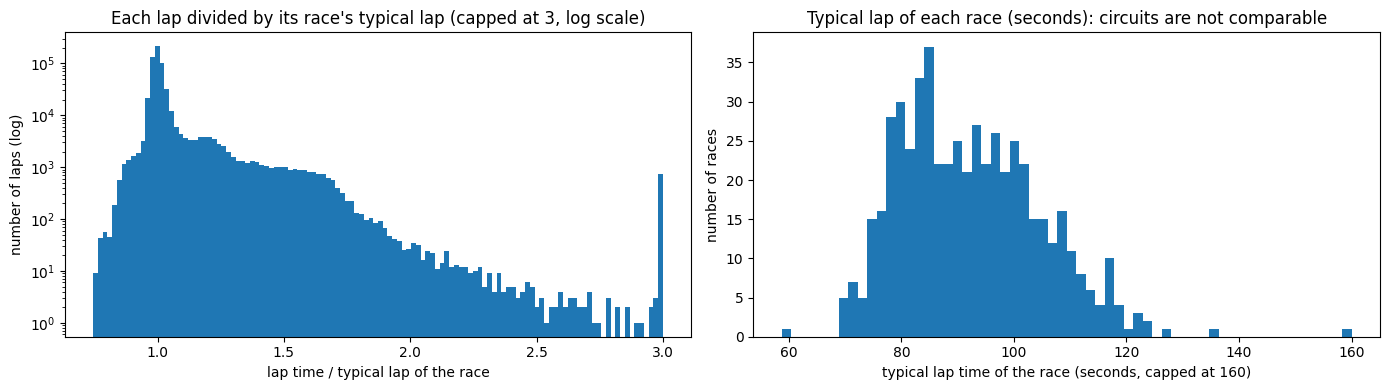

In [19]:
# ==========================================================================================
# C2 · lap_times: extreme laps, why circuits cannot be compared, and agreement with results
# ==========================================================================================

# Why: a lap time is only useful if it is a real racing lap. Some laps include a red-flag stop, a pit stop or the standing start.
# We also check that lap_times tells the same story as results (number of laps, fastest lap), so we know how much to trust it.
lt = as_num(raw["lap_times"])      # exploring copy of lap_times (raw stays untouched)
lt["year"] = year_of(lt)
lt = lt.merge(races[["raceId", "round", "name"]], on="raceId")

# ---------- 1. The slowest and fastest laps ----------
print("Lap time in milliseconds: median", int(lt.milliseconds.median()), "| fastest", lt.milliseconds.min(), "| slowest", lt.milliseconds.max(),
      "(", round(lt.milliseconds.max() / 60000, 1), "minutes )")
display(lt.nlargest(3, "milliseconds")[["year", "name", "lap", "driverId", "milliseconds"]])
display(lt.nsmallest(3, "milliseconds")[["year", "name", "lap", "driverId", "milliseconds"]])

# ---------- 2. Why raw lap times cannot be compared across races ----------
race_median = lt.groupby("raceId").milliseconds.median() / 1000                 # the typical lap of each race, in seconds
low, middle, high = race_median.quantile([0.01, 0.5, 0.99])                     # the 1st percentile, the median and the 99th percentile
print("Typical lap of a race (seconds): fastest race", round(race_median.min(), 1), "| 1% of races below", round(low, 1),
      "| median", round(middle, 1), "| 99% of races below", round(high, 1), "| slowest race", round(race_median.max(), 1))
lt["rel"] = lt.milliseconds / lt.groupby("raceId").milliseconds.transform("median")   # each lap divided by its own race's typical lap (1.0 = typical)
print("Relative lap (1.0 = typical lap of its race): median", round(lt.rel.median(), 3), "| smallest", round(lt.rel.min(), 3), "| largest", round(lt.rel.max(), 1))

# ---------- 3. How many laps are extreme, and why? ----------
cut = pd.DataFrame({"laps removed": {f"slower than {k} x typical": int((lt.rel > k).sum()) for k in [1.1, 1.2, 1.5, 2, 3]}})
cut["% of all laps"] = (cut["laps removed"] / len(lt) * 100).round(2)
display(cut)
print("Lap 1 (standing start) median relative time:", round(lt[lt.lap == 1].rel.median(), 3), "| all other laps:", round(lt[lt.lap > 1].rel.median(), 3))
slow = lt[lt.rel > 1.5].copy()                                                   # the extreme laps
pit = as_num(raw["pit_stops"])[["raceId", "driverId", "lap"]].astype(int).assign(pit_lap=1)   # pit_stops starts in 2011 (profiled in C3)
slow = slow.merge(pit, on=["raceId", "driverId", "lap"], how="left")
slow["pit_lap"] = slow.pit_lap.fillna(0)
after_pit = pit.assign(lap=pit.lap + 1).rename(columns={"pit_lap": "after_pit"})                  # the lap after a stop is the out-lap
slow = slow.merge(after_pit, on=["raceId", "driverId", "lap"], how="left")
slow["after_pit"] = slow.after_pit.fillna(0)
slow["cause"] = np.select([slow.lap == 1, slow.pit_lap == 1, slow.after_pit == 1], ["lap 1", "pit stop lap", "lap after a pit stop"], "other (safety car, red flag, spin, rain...)")
recent = slow[slow.year >= 2011]                                                  # pit stop data exists from 2011
print("Laps slower than 1.5 x typical:", len(slow), "| since 2011 (pit data exists):", len(recent))
display(recent.cause.value_counts().rename("laps (2011-2024)").to_frame())
many = slow.groupby(["year", "name"]).size().sort_values(ascending=False).head(5).rename("laps slower than 1.5 x").reset_index()
display(many)
print("Laps slower than 3 x typical:", int((lt.rel > 3).sum()), "| races with such laps:", lt[lt.rel > 3].raceId.nunique(),
      "| the biggest groups:", lt[lt.rel > 3].groupby(["year", "name"]).size().sort_values(ascending=False).head(3).to_dict())

# ---------- 4. Does lap_times agree with results? (number of laps) ----------
rr = as_num(raw["results"])[["raceId", "driverId", "laps", "positionOrder", "statusId", "fastestLapTime"]].astype({"raceId": int, "driverId": int, "laps": int})
status_name = as_num(raw["status"]).set_index("statusId").status
count = lt.groupby(["raceId", "driverId"]).lap.agg(lap_rows="count").reset_index()
chk = count.merge(rr, on=["raceId", "driverId"])
chk["diff"] = chk.lap_rows - chk.laps                                            # positive: lap_times has MORE laps than results
chk["year"] = chk.raceId.map(YEAR)
chk["status"] = chk.statusId.map(status_name)
bad = chk[chk["diff"] != 0]
print("Driver-races:", len(chk), "| lap rows = results.laps:", int((chk["diff"] == 0).sum()), "(", round((chk["diff"] == 0).mean() * 100, 2), "% )",
      "| do not match:", len(bad), "in", bad.raceId.nunique(), "of", chk.raceId.nunique(), "races")
print("lap_times has more laps:", int((bad["diff"] > 0).sum()), "| fewer:", int((bad["diff"] < 0).sum()), "| difference of 1 or 2:", int((bad["diff"].abs() <= 2).sum()),
      "| difference of 10 or more:", int((bad["diff"].abs() >= 10).sum()))
by_race = bad.merge(races[["raceId", "name"]], on="raceId").groupby(["year", "name"]).size().sort_values(ascending=False).head(4).rename("driver-races that differ").reset_index()
display(by_race)
worst = bad.groupby("raceId").size().idxmax()                                    # the race with the most mismatches
finishers = chk[chk.raceId == worst]
print("In the worst race, lap rows minus results.laps for every driver:", finishers.sort_values("positionOrder")["diff"].tolist())
display(bad[bad["diff"].abs() >= 10].merge(races[["raceId", "name"]], on="raceId")[["year", "name", "driverId", "lap_rows", "laps", "status"]])
longest = pd.DataFrame({"lap_times": chk.groupby("raceId").lap_rows.max(), "results": chk.groupby("raceId").laps.max()})
print("Races where the longest driver has the same number of laps in both tables:", int((longest.lap_times == longest.results).sum()), "of", len(longest))

# ---------- 5. Does lap_times agree with results? (fastest lap) ----------
fl = rr[rr.fastestLapTime.notna()].copy()                                         # results has fastest lap times from 2004 on
fl["results_ms"] = fl.fastestLapTime.map(lambda s: round((float(s.split(":")[0]) * 60 + float(s.split(":")[1])) * 1000))
quickest = lt.groupby(["raceId", "driverId"]).milliseconds.min().rename("lap_times_ms").reset_index()   # each driver's best lap in lap_times
fl = fl.merge(quickest, on=["raceId", "driverId"])
fl["gap_ms"] = fl.lap_times_ms - fl.results_ms
print("Driver-races with a fastest lap in results:", len(fl), "(seasons", int(fl.raceId.map(YEAR).min()), "to", int(fl.raceId.map(YEAR).max()), ")",
      "| the same in both tables:", int((fl.gap_ms == 0).sum()), "(", round((fl.gap_ms == 0).mean() * 100, 1), "% )",
      "| lap_times faster:", int((fl.gap_ms < 0).sum()), "| slower:", int((fl.gap_ms > 0).sum()), "| median gap of the differing rows (ms):", int(fl[fl.gap_ms != 0].gap_ms.median()))

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
lt.rel.clip(upper=3).plot.hist(bins=120, logy=True, ax=ax[0], title="Each lap divided by its race's typical lap (capped at 3, log scale)")
ax[0].set_xlabel("lap time / typical lap of the race")
ax[0].set_ylabel("number of laps (log)")
race_median.clip(upper=160).plot.hist(bins=60, ax=ax[1], title="Typical lap of each race (seconds): circuits are not comparable")
ax[1].set_xlabel("typical lap time of the race (seconds, capped at 160)")
ax[1].set_ylabel("number of races")
plt.tight_layout()
plt.savefig("figures/C2_lap_outliers.png", dpi=120, bbox_inches="tight")
plt.show()

**C2 result:**
- **The extremes are explained, not errors.** The fastest lap is 55.4 s (2020 Sakhir GP, lap 80): that race used the short outer loop of the track. The slowest is 125.1 minutes (2011 Canadian GP, lap 25, the red-flag stop from C1). Relative to its race's typical lap, no lap is impossibly fast (the smallest value is 0.745).
- **Raw lap times cannot be compared across races.** The typical lap of a race runs from 58.7 s (Sakhir outer loop) to 225.4 s (the one-lap 2021 Belgian GP); for 98% of races it is between 70.3 s and 122.2 s (median 91.1 s). So we always divide a lap by the typical lap of its own race.
- **How many laps are extreme:** slower than 1.2 times the typical lap: **6.6%** of laps; slower than 1.5 times: **1.99%** (11,709 laps); slower than 2 times: 0.19%; slower than 3 times: 0.12% (723 laps in 109 races; the biggest groups are the 2023 Australian GP with 49, the 2016 Brazilian GP with 36 and the 2021 Saudi Arabian GP with 35: races with red-flag stops). Lap 1 (standing start) has a median relative time of 1.13 against 1.00 for all other laps.
- **Why laps are slow (laps slower than 1.5 times, since 2011, when pit data exists):** of 6,473 laps, 493 are lap 1, 903 are the pit-stop lap, 1,222 are the lap after a stop, and **3,855 (60%) are other causes** (safety car, red flag, spin, rain). The races with the most such laps are the 2001 Australian GP (168), 2004 US GP (164), 2005 Chinese GP (157), 2020 Tuscan GP (154) and 2002 Austrian GP (148).
- **Number of laps agrees with `results` in 10,951 of 11,041 driver-races (99.18%).** The 90 that differ are in 35 of 544 races: `lap_times` has more laps in 37 and fewer in 53; 71 differ by only 1 or 2 laps and 10 by 10 or more.
  - **One race is a race-level difference:** in the 2014 Chinese GP all 20 classified cars have exactly 2 more laps in `lap_times` than in `results` (the 2 cars that retired early match). One of the two tables is wrong for that race; the data alone cannot tell which.
  - **The big gaps look like swapped drivers:** 2001 Hungarian GP (drivers 15 and 55: 75 and 53 laps in `lap_times`, 53 and 75 in `results`), 2001 Japanese GP (5 and 52 against 52 and 5), 2009 Italian GP, and a few single drivers (2008 British, 2006 French, 2001 Italian, 2024 São Paulo, where a disqualified driver has 30 laps against 0).
  - The longest driver's lap count agrees in 543 of 544 races (the exception is the 2014 Chinese GP).
- **Fastest lap:** `results` has fastest-lap times from 2004. For 8,249 driver-races the best lap in `lap_times` is identical in 8,039 (97.5%) and differs in 210 (150 faster in `lap_times`, 60 slower; median gap 330 ms).

**Decisions for features and leakage:**
1. Never use raw lap times: use each lap divided by the typical lap of its own race.
2. For a pace feature keep only clean racing laps: drop lap 1, the pit-stop lap and the lap after a stop (2011 on), and every lap above a cutoff of the race's typical lap. We propose starting at 1.2 times (removes 6.6% of laps) and testing 1.5 times (1.99%); the team chooses and records it. Red-flag laps (above 3 times) are always out.
3. Record the 90 lap-count mismatches in the data-quality log and do not fix them. If a feature needs lap counts use `results.laps` (the official table); exclude the 2014 Chinese GP and the swapped-driver cases from pace features.
4. Use one source for a driver's best lap: `lap_times` (all laps from 1996) or `results.fastestLapTime` (from 2004), not a mix; they agree for 97.5%.
5. Same leakage rule as C1: laps of race R only enter features for later races.

## C3 · pit_stops: profile, keys, coverage, what one row means, and the time formats

- **What:** profile `pit_stops` (one row per stop), check its key and links, find which races have pit data, test whether the data is complete for the drivers who finished, and check how the two time columns (`duration` and `time`) are written.
- **Why:** pit stops tell us a race's strategy and a team's pit-crew speed. Before looking for odd stops (C4) we must know what a row means, where the data exists at all, and which time column to use.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
raceId,0,0.0,0,285,100.0,841
driverId,0,0.0,0,76,100.0,153
stop,0,0.0,0,14,100.0,1
lap,0,0.0,0,74,100.0,1
time,0,0.0,0,8227,0.0,17:05:23
duration,0,0.0,0,7604,95.5,26.898
milliseconds,0,0.0,0,7604,100.0,26898


{'table': 'pit_stops', 'key': 'raceId+driverId+stop', 'rows': 11371, 'duplicates': 0, 'null_or_sentinel': 0}
driverId values that are not in drivers: 0 | raceId values that are not in races: 0 | driver-races with stops but no row in results: 0 of 5575
Rows: 11371 | races: 285 | drivers: 76 | seasons: 2011 to 2024


year,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
races,19,20,19,19,19,21,20,21,21,17,22,22,22,24
races with pit data,19,20,19,19,19,21,20,21,21,17,21,22,22,24


Races from 2011 on without pit data: [[2021, 'Belgian Grand Prix']] | races before 2011 with pit data: 0
Race starts in races with pit data: 5960 | with at least one stop: 5575 ( 93.5 % )
Finishers: 4922 | finishers with NO stop recorded: 3 | non-finishers with a stop: 656 of 1038
Stops per driver-race: {1: 1854, 2: 2225, 3: 1069, 4: 307, 5: 91, 6: 26, 7: 3}
Average stops per finisher, by season: {2011: 2.68, 2012: 2.16, 2013: 2.41, 2014: 2.23, 2015: 2.16, 2016: 2.3, 2017: 1.94, 2018: 1.42, 2019: 1.59, 2020: 1.94, 2021: 2.02, 2022: 2.02, 2023: 2.2, 2024: 1.8}
duration range (ms): 12897 to 3069017 | lap: 1 to 78 | stop number: 1 to 70
Driver-races whose stops are numbered exactly 1..n: 5567 of 5575
duration looks like ss.mmm: 10854 | m:ss.mmm: 517 | any other format: 0
duration text agrees with the milliseconds column: 11371 of 11371
time looks like hh:mm:ss: 11371 of 11371
Example Australian Grand Prix 2011 | start time in races: 06:00:00 | clock time of the first stop: 17:05:23
Clock 

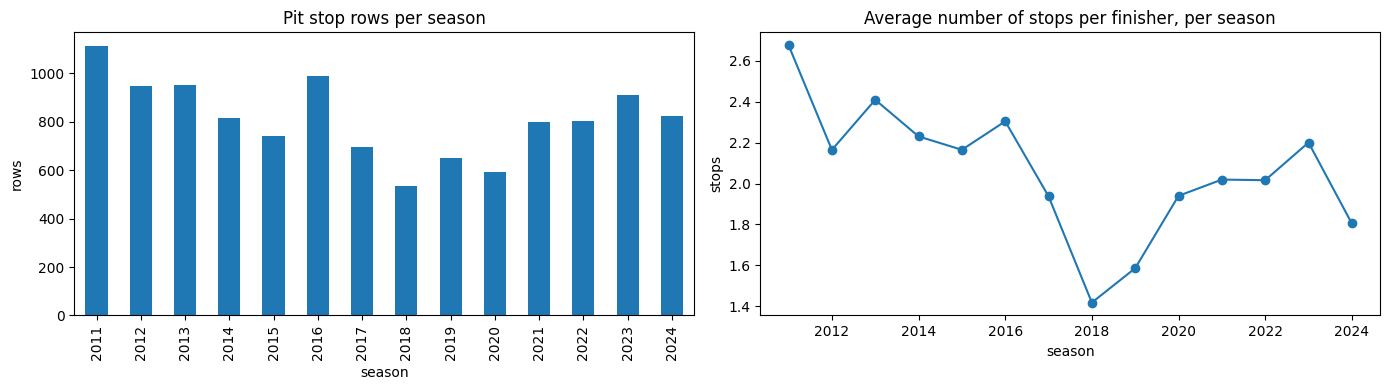

In [20]:
# ==========================================================================================
# C3 · pit_stops: profile, keys, coverage, what one row means, and the time formats
# ==========================================================================================

# Why: pit_stops tells us how many times each driver stopped and how long each stop took. Before looking for odd stops (C4) we check
# what a row means, which races have the data, whether finishers are all there, and how the two time columns are written.
ps = as_num(raw["pit_stops"])      # exploring copy of pit_stops (raw stays untouched)
ps["year"] = year_of(ps)           # the season of each stop

# ---------- 1. Profile card, keys and links ----------
display(profile("pit_stops"))
print(pk_check("pit_stops", ["raceId", "driverId", "stop"]))               # one row per driver per stop? (the grain we expect)
race_entries = results[["raceId", "driverId"]].astype(int)                  # who really started each race
driver_races = ps[["raceId", "driverId"]].drop_duplicates().merge(race_entries.assign(started=1), on=["raceId", "driverId"], how="left")
print("driverId values that are not in drivers:", len(set(ps.driverId) - set(raw["drivers"].driverId.astype(int))),
      "| raceId values that are not in races:", len(set(ps.raceId) - set(races.raceId)),
      "| driver-races with stops but no row in results:", int(driver_races.started.isna().sum()), "of", len(driver_races))

# ---------- 2. Coverage: which races have pit stop data? ----------
print("Rows:", len(ps), "| races:", ps.raceId.nunique(), "| drivers:", ps.driverId.nunique(), "| seasons:", ps.year.min(), "to", ps.year.max())
coverage = pd.DataFrame({"races": races[races.year >= 2011].groupby("year").size(), "races with pit data": ps.groupby("year").raceId.nunique()})
display(coverage.T)
no_data = races[(races.year >= 2011) & ~races.raceId.isin(ps.raceId)]
print("Races from 2011 on without pit data:", no_data[["year", "name"]].values.tolist(), "| races before 2011 with pit data:", int((ps.year < 2011).sum()))

# ---------- 3. Is the data complete? (who has a stop row) ----------
status_name = as_num(raw["status"]).set_index("statusId").status
starts = as_num(raw["results"])[["raceId", "driverId", "statusId"]].astype({"raceId": int, "driverId": int})
starts = starts[starts.raceId.isin(ps.raceId)].copy()                                     # race starts in races that have pit data
starts["status"] = starts.statusId.map(status_name)
stop_counts = ps.groupby(["raceId", "driverId"]).size().rename("stops").reset_index()      # number of stop rows per driver-race
starts = starts.merge(stop_counts, on=["raceId", "driverId"], how="left")
starts["stops"] = starts.stops.fillna(0).astype(int)                                       # no stop row = 0 stops
starts["year"] = starts.raceId.map(YEAR)
finished = starts[starts.status.eq("Finished") | starts.status.str.match(r"^\+\d+ Laps?$")]  # classified finishers, also those laps down
print("Race starts in races with pit data:", len(starts), "| with at least one stop:", int((starts.stops > 0).sum()),
      "(", round((starts.stops > 0).mean() * 100, 1), "% )")
print("Finishers:", len(finished), "| finishers with NO stop recorded:", int((finished.stops == 0).sum()),
      "| non-finishers with a stop:", int((starts[~starts.index.isin(finished.index)].stops > 0).sum()), "of", len(starts) - len(finished))
stops_per_race = ps.groupby(["raceId", "driverId"]).size()
print("Stops per driver-race:", stops_per_race.value_counts().sort_index().to_dict())
print("Average stops per finisher, by season:", finished.groupby("year").stops.mean().round(2).to_dict())

# ---------- 4. The numbers: ranges ----------
print("duration range (ms):", ps.milliseconds.min(), "to", ps.milliseconds.max(), "| lap:", ps.lap.min(), "to", ps.lap.max(), "| stop number:", ps.stop.min(), "to", ps.stop.max())
numbering = ps.groupby(["raceId", "driverId"]).stop.agg(["min", "max", "nunique", "size"])
print("Driver-races whose stops are numbered exactly 1..n:", int(((numbering["min"] == 1) & (numbering["max"] == numbering["size"]) & (numbering["nunique"] == numbering["size"])).sum()),
      "of", len(numbering))

# ---------- 5. The two time columns ----------
d = raw["pit_stops"].duration                                                  # the original text
seconds = d.str.match(r"^\d{1,3}\.\d{3}$")                                     # ss.mmm, e.g. 26.898
with_minutes = d.str.match(r"^\d+:\d{2}\.\d{3}$")                              # m:ss.mmm, e.g. 16:44.718
print("duration looks like ss.mmm:", int(seconds.sum()), "| m:ss.mmm:", int(with_minutes.sum()), "| any other format:", int((~seconds & ~with_minutes).sum()))
def duration_to_ms(s):
    parts = s.split(":")
    if len(parts) == 2:
        return round((float(parts[0]) * 60 + float(parts[1])) * 1000)           # minutes and seconds
    return round(float(parts[0]) * 1000)                                        # seconds only
print("duration text agrees with the milliseconds column:", int((d.map(duration_to_ms) == ps.milliseconds).sum()), "of", len(ps))
clock = raw["pit_stops"].time
print("time looks like hh:mm:ss:", int(clock.str.match(r"^\d{2}:\d{2}:\d{2}$").sum()), "of", len(clock))
first_race = ps.raceId.iloc[0]                                                  # an example: the first race in the table
print("Example", races[races.raceId == first_race].name.iloc[0], races[races.raceId == first_race].year.iloc[0], "| start time in races:",
      races[races.raceId == first_race].time.iloc[0], "| clock time of the first stop:", ps[ps.raceId == first_race].time.min())
start = ps.raceId.map(races.set_index("raceId").time)                           # race start time from races, for every stop
gap_minutes = (pd.to_timedelta(ps.time) - pd.to_timedelta(start)).dt.total_seconds() / 60
print("Clock time minus the start time in races (minutes): from", int(gap_minutes.min()), "to", int(gap_minutes.max()),
      "| stops that look earlier than the race start:", int((gap_minutes < 0).sum()), "of", len(ps))

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ps.groupby("year").size().plot.bar(ax=ax[0], title="Pit stop rows per season")
ax[0].set_xlabel("season")
ax[0].set_ylabel("rows")
finished.groupby("year").stops.mean().plot(ax=ax[1], marker="o", title="Average number of stops per finisher, per season")
ax[1].set_xlabel("season")
ax[1].set_ylabel("stops")
plt.tight_layout()
plt.savefig("figures/C3_pit_stops.png", dpi=120, bbox_inches="tight")
plt.show()

**C3 result:**
- **Clean on the surface.** 11,371 rows x 7 columns, no `\N`, no empty cells. (`raceId`, `driverId`, `stop`) is unique, every ID exists in its table, and all 5,575 driver-races with stops exist in `results`.
- **Pit data exists only from 2011.** 285 races, 2011 to 2024. Every race of those seasons has data except the **2021 Belgian GP** (one lap behind the safety car, so no stops, as in C1). Nothing before 2011: any pit-based feature covers about a quarter of all races (285 of 1,125).
- **The data is complete for finishers.** 5,575 of the 5,960 race starts in these races (93.5%) have at least one stop row. Of the **4,922 classified finishers only 3 have no stop**. 656 of the 1,038 non-finishers also have a stop, so "no stop row" for a driver who retired early is normal, not missing.
- **A row is one stop of one driver.** Stops per driver-race: 1 stop in 1,854, 2 in 2,225, 3 in 1,069, 4 in 307, 5 to 7 in 120. The average number of stops per finisher moves from 2.68 (2011) down to 1.42 (2018) and back to 2.20 (2023), 1.80 (2024): strategy rules and tyres change, so stop counts are not comparable across seasons.
- **Numbers to watch in C4:** the stops of 5,567 of 5,575 driver-races are numbered exactly 1..n; 8 have gaps. The stop number goes up to 70 and the duration from 12.9 s up to 3,069 s (51 minutes), which cannot be normal pit stops.
- **`duration` is text, but it agrees with `milliseconds` in all 11,371 rows.** 10,854 rows are `ss.mmm` and **517 are `m:ss.mmm`** (for example `16:44.718`), so the text cannot be converted with a plain `float()`.
- **`time` is the clock time of the stop (`hh:mm:ss` in every row), in local time, not a duration.** Example: the 2011 Australian GP starts at `06:00:00` in `races` (UTC) but its first stop is at `17:05:23` (local time). Comparing the two puts 1,827 of the 11,371 stops before the start of their race (from -355 to +1,042 minutes), so `time` cannot be used with `races.time` without time zones.

**Decisions for features and leakage:**
1. Use `milliseconds` for the stop duration.
2. Drop `time` (or leave it as text): no feature needs it, and it cannot be combined with `races.time`. The `lap` of the stop is the useful part.
3. Pit-based features exist only from 2011 and not for the 2021 Belgian GP: use a flag (such as `has_pit_data`), as for the lap data.
4. Do not compare the number of stops across seasons (1.42 to 2.68 per finisher); compare within a season or relative to the race.
5. The pit stops of race R belong to race R: use them only from **earlier** races, never for the race being predicted.

## C4 · pit_stops: real stops versus red-flag pauses, odd stop numbers, and odd races

- **What:** measure how long a stop really is, separate real stops from red-flag pauses and very slow stops, look at the odd stop numbers (up to 70), check stops after a driver's last lap, and see what the stop count looks like once red-flag pauses are removed.
- **Why:** C3 showed stops of up to 51 minutes. A real pit stop takes about 24 seconds, so an average stop time or a stop count is only meaningful after removing the red-flag pauses and fixing or flagging the data artifacts.

Stop duration (s): fastest 12.9 | 1% 16.5 | 10% 20.4 | median 23.6 | 90% 31.6 | 99% 1848.2 | slowest 3069.0


,stops,races
longer than 30 s,1664,235
longer than 40 s,649,114
longer than 60 s,517,50
longer than 120 s,481,29
longer than 300 s,478,26


Stops up to 60 s: 10854 | middle half (s): 21.9 to 25.6 | longest (s): 59.6
Median normal stop by season (s): {2011: 22.4, 2012: 22.3, 2013: 22.9, 2014: 24.2, 2015: 24.2, 2016: 23.8, 2017: 23.6, 2018: 23.7, 2019: 23.5, 2020: 24.2, 2021: 23.6, 2022: 23.7, 2023: 23.7, 2024: 23.3}
Stops by kind: {'normal (up to 60 s)': 10854, 'red-flag pause (over 5 minutes)': 478, 'very slow stop (1 to 5 minutes)': 39}
Red-flag pauses happen on lap: {2: 89, 1: 73, 8: 31, 32: 24, 13: 20} | in 26 races


,,long stops (over 60 s),all stops,share of the race's stops
year,name,,,
2023,Australian Grand Prix,49,65,0.75
2016,Brazilian Grand Prix,36,62,0.58
2021,Saudi Arabian Grand Prix,35,47,0.74
2020,Tuscan Grand Prix,25,66,0.38
2021,Emilia Romagna Grand Prix,22,56,0.39


Driver-races whose stop numbers are not exactly 1..n: 8 in races: {(2024, 'Monaco Grand Prix'): 6, (2014, 'British Grand Prix'): 1, (2019, 'Singapore Grand Prix'): 1}


,name,driverId,stop_numbers,laps,durations
0,British Grand Prix,820,"[2, 3]","[2, 29]","[23.154, 29.737]"
1,Singapore Grand Prix,832,[2],[35],[30.623]
2,Monaco Grand Prix,1,"[1, 51]","[1, 2]","[39:35.369, 24.232]"
3,Monaco Grand Prix,822,"[1, 15]","[1, 2]","[39:54.053, 24.239]"
4,Monaco Grand Prix,830,"[1, 52]","[1, 2]","[39:32.670, 23.813]"
5,Monaco Grand Prix,840,"[1, 42, 48]","[1, 2, 3]","[39:43.588, 24.132, 28.211]"
6,Monaco Grand Prix,855,"[1, 70]","[1, 2]","[39:46.414, 24.367]"
7,Monaco Grand Prix,858,"[1, 57]","[1, 2]","[39:51.600, 24.384]"


Largest stop numbers: [[2024, 'Monaco Grand Prix', 70, 2, '24.367'], [2024, 'Monaco Grand Prix', 57, 2, '24.384'], [2024, 'Monaco Grand Prix', 52, 2, '23.813']] | most stop rows for one driver in one race: 7
Two stops on the same lap: 0 | a stop not later than the driver's previous stop: 0
Stops on a lap after the driver's last lap in results: 3 | after the last lap in lap_times: 0 | stops with no lap_times for that driver: 0


,year,name,driverId,stop,lap,laps,last_lap_in_lap_times
11210,2024,São Paulo Grand Prix,807,1,25,0,30
11223,2024,São Paulo Grand Prix,807,2,27,0,30
11226,2024,São Paulo Grand Prix,807,3,29,0,30


Driver-races: 5575 | the stop count changes when red-flag pauses are removed: 404 | in 26 races | driver-races left with 0 stops: 41


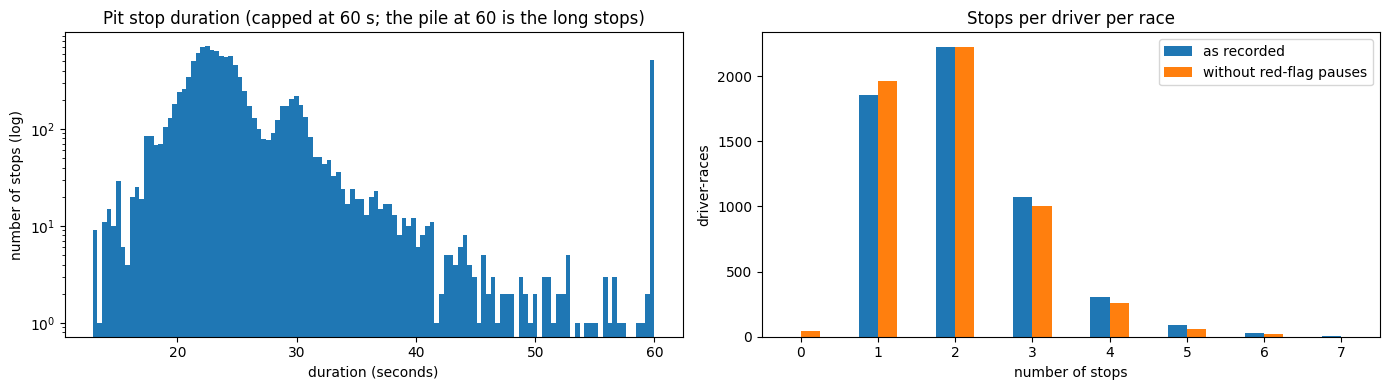

In [21]:
# ==========================================================================================
# C4 · pit_stops: real stops versus red-flag pauses, odd stop numbers, and odd races
# ==========================================================================================

# Why: C3 showed stops that last up to 51 minutes and stop numbers up to 70. A real pit stop takes about 24 seconds. We separate real
# stops from red-flag pauses (the whole field waits in the pit lane) and from data artifacts, so an average stop time means something.
ps = as_num(raw["pit_stops"])      # exploring copy of pit_stops (raw stays untouched)
ps["year"] = year_of(ps)
ps = ps.merge(races[["raceId", "round", "name"]], on="raceId")
seconds = ps.milliseconds / 1000                                                   # the stop duration in seconds

# ---------- 1. How long is a stop? ----------
low, p10, middle, p90, p99 = seconds.quantile([0.01, 0.10, 0.50, 0.90, 0.99])
print("Stop duration (s): fastest", round(seconds.min(), 1), "| 1%", round(low, 1), "| 10%", round(p10, 1), "| median", round(middle, 1),
      "| 90%", round(p90, 1), "| 99%", round(p99, 1), "| slowest", round(seconds.max(), 1))
cut = pd.DataFrame({"stops": {f"longer than {k} s": int((seconds > k).sum()) for k in [30, 40, 60, 120, 300]},
                    "races": {f"longer than {k} s": ps[seconds > k].raceId.nunique() for k in [30, 40, 60, 120, 300]}})
display(cut)
normal = ps[seconds <= 60]                                                         # stops that look like real pit stops
print("Stops up to 60 s:", len(normal), "| middle half (s):", round((normal.milliseconds / 1000).quantile(0.25), 1), "to", round((normal.milliseconds / 1000).quantile(0.75), 1),
      "| longest (s):", round(normal.milliseconds.max() / 1000, 1))
print("Median normal stop by season (s):", (normal.groupby("year").milliseconds.median() / 1000).round(1).to_dict())

# ---------- 2. Red-flag pauses and very slow stops ----------
ps["kind"] = np.select([seconds > 300, seconds > 60], ["red-flag pause (over 5 minutes)", "very slow stop (1 to 5 minutes)"], "normal (up to 60 s)")
print("Stops by kind:", ps.kind.value_counts().to_dict())
pauses = ps[ps.kind.str.startswith("red-flag")]
print("Red-flag pauses happen on lap:", pauses.lap.value_counts().head(5).to_dict(), "| in", pauses.raceId.nunique(), "races")
races_with = pd.DataFrame({"long stops (over 60 s)": ps[seconds > 60].groupby(["year", "name"]).size(), "all stops": ps.groupby(["year", "name"]).size()}).dropna()
races_with["share of the race's stops"] = (races_with.iloc[:, 0] / races_with["all stops"]).round(2)
display(races_with.sort_values("long stops (over 60 s)", ascending=False).head(5).astype({"long stops (over 60 s)": int, "all stops": int}))

# ---------- 3. Odd stop numbers ----------
numbering = ps.groupby(["raceId", "driverId"]).agg(first=("stop", "min"), last=("stop", "max"), rows=("stop", "size"),
                                                    stop_numbers=("stop", list), laps=("lap", list), durations=("duration", list)).reset_index()
odd_numbering = numbering[(numbering["first"] != 1) | (numbering["last"] != numbering["rows"])]       # numbers should run 1..n
print("Driver-races whose stop numbers are not exactly 1..n:", len(odd_numbering), "in races:",
      odd_numbering.merge(races[["raceId", "year", "name"]], on="raceId")[["year", "name"]].value_counts().to_dict())
display(odd_numbering.merge(races[["raceId", "name"]], on="raceId")[["name", "driverId", "stop_numbers", "laps", "durations"]])
print("Largest stop numbers:", ps.nlargest(3, "stop")[["year", "name", "stop", "lap", "duration"]].values.tolist(),
      "| most stop rows for one driver in one race:", int(numbering.rows.max()))
print("Two stops on the same lap:", int((ps.groupby(["raceId", "driverId", "lap"]).size() > 1).sum()),
      "| a stop not later than the driver's previous stop:", int((ps.sort_values(["raceId", "driverId", "stop"]).groupby(["raceId", "driverId"]).lap.diff() <= 0).sum()))

# ---------- 4. Stops after the driver's last lap? ----------
last_lap = as_num(raw["lap_times"]).groupby(["raceId", "driverId"]).lap.max().rename("last_lap_in_lap_times").reset_index()
laps_done = as_num(raw["results"])[["raceId", "driverId", "laps"]].astype({"raceId": int, "driverId": int, "laps": int})
x = ps.merge(last_lap, on=["raceId", "driverId"], how="left").merge(laps_done, on=["raceId", "driverId"], how="left")
late = x[x.lap > x.laps]
print("Stops on a lap after the driver's last lap in results:", len(late), "| after the last lap in lap_times:", int((x.lap > x.last_lap_in_lap_times).sum()),
      "| stops with no lap_times for that driver:", int(x.last_lap_in_lap_times.isna().sum()))
display(late[["year", "name", "driverId", "stop", "lap", "laps", "last_lap_in_lap_times"]])

# ---------- 5. What happens to the number of stops if we remove red-flag pauses? ----------
raw_count = ps.groupby(["raceId", "driverId"]).size()
clean_count = ps[ps.kind != "red-flag pause (over 5 minutes)"].groupby(["raceId", "driverId"]).size().reindex(raw_count.index).fillna(0).astype(int)
print("Driver-races:", len(raw_count), "| the stop count changes when red-flag pauses are removed:", int((raw_count != clean_count).sum()),
      "| in", raw_count[raw_count != clean_count].reset_index().raceId.nunique(), "races | driver-races left with 0 stops:", int((clean_count == 0).sum()))

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
seconds.clip(upper=60).plot.hist(bins=120, logy=True, ax=ax[0], title="Pit stop duration (capped at 60 s; the pile at 60 is the long stops)")
ax[0].set_xlabel("duration (seconds)")
ax[0].set_ylabel("number of stops (log)")
pd.DataFrame({"as recorded": raw_count.value_counts().sort_index(), "without red-flag pauses": clean_count.value_counts().sort_index()}).fillna(0).plot.bar(
    ax=ax[1], rot=0, title="Stops per driver per race")
ax[1].set_xlabel("number of stops")
ax[1].set_ylabel("driver-races")
plt.tight_layout()
plt.savefig("figures/C4_pit_stop_outliers.png", dpi=120, bbox_inches="tight")
plt.show()

**C4 result:**
- **A real stop takes about 24 seconds.** Fastest 12.9 s; median 23.6 s; 90% of stops are under 31.6 s. The 99th percentile is 1,848 s, which shows how few extreme rows distort any average. The 10,854 stops up to 60 s have a middle half of 21.9 s to 25.6 s and a longest of 59.6 s. The median is 22.3 to 22.9 s in 2011 to 2013 and 23.3 to 24.2 s since 2014, so compare stop times within a season.
- **517 stops are longer than 60 s, in 50 races.** They split into **478 red-flag pauses** (longer than 5 minutes, in 26 races: the whole field waits in the pit lane) and **39 very slow stops** (1 to 5 minutes: a repair or a penalty). The pauses happen mostly on laps 1 and 2 (162 of 478) and on laps 8, 32 and 13. The races with the most: 2023 Australian GP (49 of its 65 stops), 2016 Brazilian GP (36 of 62), 2021 Saudi Arabian GP (35 of 47), 2020 Tuscan GP, 2021 Emilia Romagna GP.
- **Odd stop numbers: 8 driver-races in 3 races.**
  - **2024 Monaco GP (6 drivers):** the first row is a 39-minute red-flag stop on lap 1; the next, normal 24-second stop on lap 2 is numbered 15, 42, 48, 51, 52, 57 or 70 instead of 2. This is where the number 70 comes from: it is a label error, not 70 stops. The most stop rows for one driver in one race is 7.
  - **2014 British GP (1 driver)** and **2019 Singapore GP (1 driver):** the numbering starts at 2, so stop 1 is missing.
  - There are no two stops on the same lap, and every stop is on a later lap than the driver's previous stop.
- **Stops after a driver's last lap: 3 rows by `results`, 0 by `lap_times`.** All three belong to the disqualified 2024 São Paulo driver whose `results.laps` is 0 (the same case as in C2), so there is no real conflict.
- **Removing the red-flag pauses changes the stop count in 404 of 5,575 driver-races (7.2%), in 26 races, and leaves 41 driver-races with 0 stops** (drivers whose only "stop" was the pause).

**Decisions for features and leakage:**
1. Treat a stop as a **real pit stop up to 60 s**. Stops from 60 s to 5 minutes are very slow stops: keep them as stops but leave them out of duration averages. Stops over 5 minutes are red-flag pauses: remove them from both durations and stop counts.
2. Use medians for stop times, from normal stops only, and compare within a season.
3. Do not trust the `stop` number as a count: recount the stops of each driver in each race by sorting on `lap`. Record the 8 odd driver-races (2024 Monaco, 2014 British GP, 2019 Singapore GP) in the data-quality log.
4. Ignore the 3 "stops after the last lap": they belong to a disqualified driver and `lap_times` shows no conflict.
5. Same leakage rule as C3: the pit stops of race R only enter features for later races.